# **🔥 Clasificación de perfiles de Burnout del desarrollador. <br>Modelos no supervisados | K-Means & DBSCAN |**

El notebook trabaja con aprendizaje no supervisado. Eso significa que el modelo no aprende usando una respuesta correcta, sino que busca patrones ocultos en los datos.
En este caso, el objetivo es agrupar desarrolladores según variables relacionadas con burnout, como carga laboral, estrés, satisfacción, horas de trabajo, etc.

##La idea central es:

**“Queremos descubrir perfiles de burnout de desarrolladores sin decirle al modelo quién tiene burnout alto, medio o bajo”.**

**Objetivo:** Descubrir perfiles latentes a partir de las *causas* del burnout (horas, estrés, satisfacción), no de la etiqueta resultante.

Por eso se excluye burnout_level.

### **🗂️ Fuente**
- [Developer Burnout Prediction Dataset — Kaggle](https://www.kaggle.com/datasets/asifxzaman/developer-burnout-prediction-dataset7000-samples)  
- **Registros:** 7,000  
- **Variables:** 12

### **📋 Consideraciones aplicadas:**
| # | Consideración | Justificación |
|---|---|---|
| 1 | **`burnout_level` excluida** | Es la variable TARGET — incluirla sería hacer trampa |
| 2 | **Tratamiento completo de NaN** | Mediana (numéricas) + Moda (categóricas) + visualización |
| 3 | **Rango k ampliado a 2–12** | Análisis con 4 métricas + ranking combinado |



# **📦 1 - Importación de librerías**

## 📋 Herramientas cargadas:

| # | Destinada a | Librería |
|---|---|---|
| 1 | **manejar datos:** | pandas, numpy |
| 2 | **graficar:** | matplotlib, seaborn, plotly |
| 3 | **preparar datos:** | SimpleImputer, ColumnTransformer, RobustScaler, StandardScaler, OneHotEncoder |
| 4 | **aplicar modelos:** | KMeans, DBSCAN, AgglomerativeClustering, GaussianMixture |
| 5 | **reducir dimensiones:** | PCA, t-SNE |
| 6 | **evaluar clusters:** | silhouette_score, davies_bouldin_score, calinski_harabasz_score |

> 🆕 **Mejoras:** `OneHotEncoder` reemplaza `LabelEncoder`; se agregan `RobustScaler`, `AgglomerativeClustering`, `GaussianMixture` y `scipy` para radar chart.

In [1]:
# PASO 1: IMPORTACIÓN DE LIBRERÍAS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px

try:
    import missingno as msno
except ImportError:
    !pip install missingno -q
    import missingno as msno

# 🆕 OneHotEncoder + ColumnTransformer reemplazan LabelEncoder
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import (silhouette_score, silhouette_samples,
    davies_bouldin_score, calinski_harabasz_score)
from collections import Counter
from scipy.stats import shapiro                                        # 🆕 Test normalidad

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
print('✅ Librerías cargadas (v3 mejorado).')

✅ Librerías cargadas (v3 mejorado).


# **📂 2 - Carga de dataset desde Google Drive**

## El notebook carga el archivo: developer_burnout_dataset.csv

**Luego muestra:**
* número de filas
* número de columnas
* nombres de variables
* tipos de datos
* primeras filas del dataset

Esto sirve para entender con qué información vamos a trabajar.

In [2]:
# PASO 2: CARGA DE DATOS
from google.colab import drive
drive.mount('/content/drive')

FILE_PATH = '/content/drive/My Drive/MachineLearning/Semana3/developer_burnout_dataset.csv'
df_raw = pd.read_csv(FILE_PATH)

print(f'✅ Dataset: {df_raw.shape[0]} filas × {df_raw.shape[1]} columnas')
print('\nColumnas:')
for i, col in enumerate(df_raw.columns):
    print(f'  {i+1:2d}. {col:<35} [{df_raw[col].dtype}]')
display(df_raw.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Dataset: 7000 filas × 12 columnas

Columnas:
   1. age                                 [float64]
   2. experience_years                    [float64]
   3. daily_work_hours                    [float64]
   4. sleep_hours                         [float64]
   5. caffeine_intake                     [float64]
   6. bugs_per_day                        [float64]
   7. commits_per_day                     [float64]
   8. meetings_per_day                    [float64]
   9. screen_time                         [float64]
  10. exercise_hours                      [float64]
  11. stress_level                        [float64]
  12. burnout_level                       [object]


,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,stress_level,burnout_level
0,26.0,12.0,10.33,4.45,2.0,11.0,4.0,1.0,15.07,0.14,55.96,Medium
1,39.0,10.0,8.62,5.77,5.0,15.0,11.0,5.0,13.25,0.54,82.22,High
2,34.0,13.0,NaN,4.03,5.0,2.0,18.0,9.0,11.18,1.54,61.77,Medium
3,30.0,1.0,6.85,6.47,2.0,15.0,26.0,1.0,11.14,0.96,54.98,Medium
4,27.0,7.0,4.24,5.80,NaN,9.0,17.0,7.0,8.05,0.36,27.90,Low


# **🔍 3: Análisis exploratorio de datos (EDA)**

## Aquí se revisa el dataset antes de modelar.

Se analiza:
* estructura general
* estadísticas descriptivas
* valores nulos
* distribución de variables numéricas
* correlaciones

Por ejemplo, si una variable tiene muchos valores faltantes, el modelo puede verse afectado.

También se grafican histogramas para ver si las variables están concentradas, dispersas o tienen valores extremos.
Distribuciones, valores nulos y correlaciones antes de modelar.

In [3]:
# PASO 3A: INFO GENERAL
df_raw.info()
display(df_raw.describe().round(2))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               6860 non-null   float64
 1   experience_years  6860 non-null   float64
 2   daily_work_hours  6860 non-null   float64
 3   sleep_hours       6860 non-null   float64
 4   caffeine_intake   6860 non-null   float64
 5   bugs_per_day      6860 non-null   float64
 6   commits_per_day   6860 non-null   float64
 7   meetings_per_day  6860 non-null   float64
 8   screen_time       6860 non-null   float64
 9   exercise_hours    6860 non-null   float64
 10  stress_level      6860 non-null   float64
 11  burnout_level     6860 non-null   object 
dtypes: float64(11), object(1)
memory usage: 656.4+ KB


,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,stress_level
count,6860.00,6860.00,6860.00,6860.00,6860.00,6860.00,6860.00,6860.00,6860.00,6860.00,6860.00
mean,32.13,9.58,9.00,6.49,3.54,9.48,14.46,4.55,11.97,1.01,53.65
std,7.23,5.76,2.86,1.45,2.28,5.75,8.67,2.86,3.09,0.58,23.45
min,20.00,0.00,4.00,4.00,0.00,0.00,0.00,0.00,5.21,0.00,0.00
25%,26.00,5.00,6.56,5.22,2.00,5.00,7.00,2.00,9.46,0.51,36.59
50%,32.00,10.00,8.99,6.46,4.00,9.00,14.00,5.00,12.02,1.02,53.80
75%,38.00,15.00,11.42,7.74,6.00,14.00,22.00,7.00,14.42,1.51,70.80
max,44.00,19.00,14.00,9.00,7.00,19.00,29.00,9.00,18.93,2.00,100.00


🔎 Diagnóstico de valores faltantes:


,Tipo,NaN,% NaN,Estrategia
age,float64,140,2.0,Mediana
experience_years,float64,140,2.0,Mediana
daily_work_hours,float64,140,2.0,Mediana
sleep_hours,float64,140,2.0,Mediana
caffeine_intake,float64,140,2.0,Mediana
bugs_per_day,float64,140,2.0,Mediana
commits_per_day,float64,140,2.0,Mediana
meetings_per_day,float64,140,2.0,Mediana
screen_time,float64,140,2.0,Mediana
exercise_hours,float64,140,2.0,Mediana



Total NaN: 1680 | Columnas sin NaN: 0/12


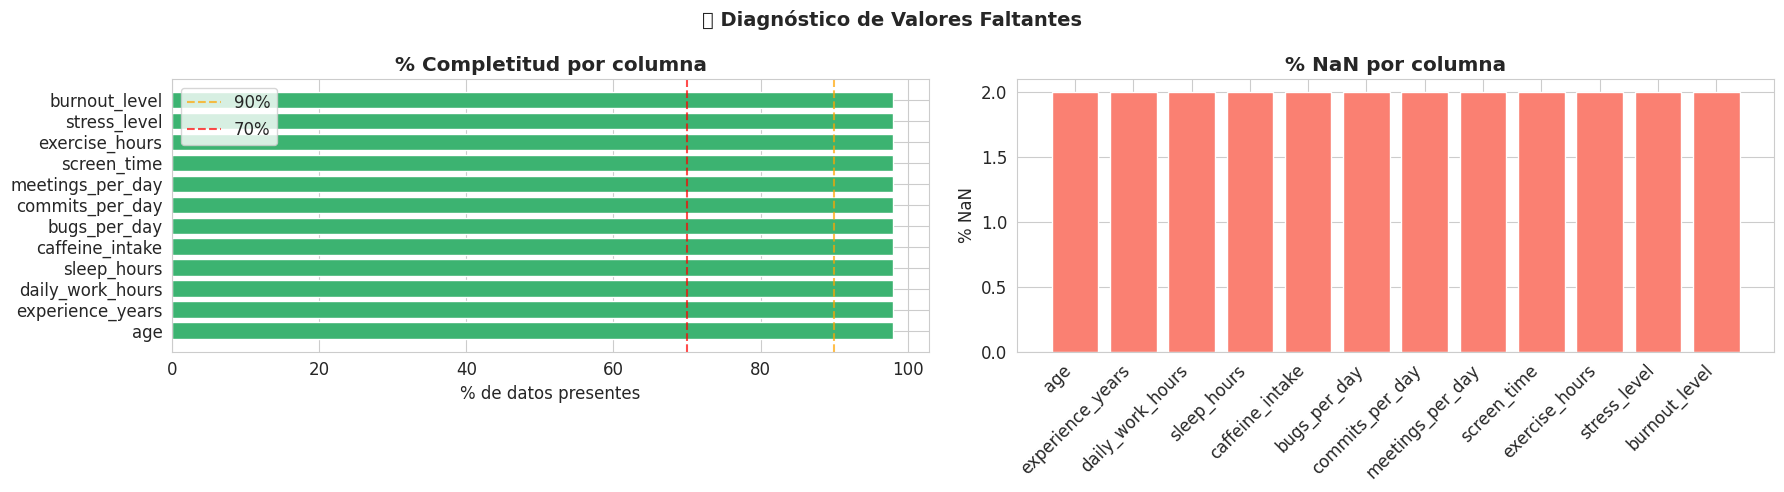

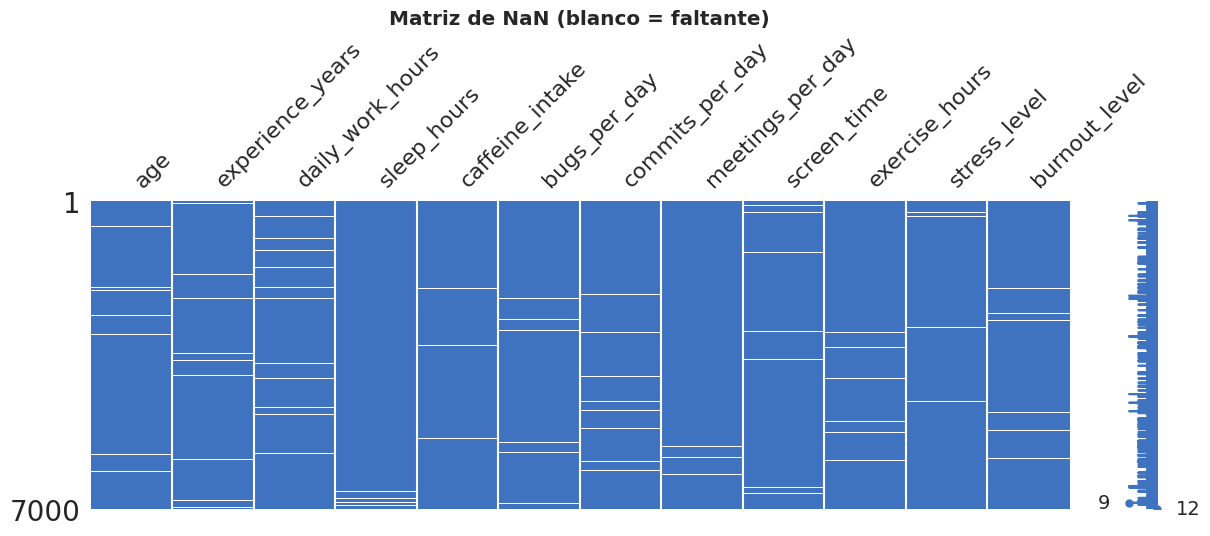

In [4]:
# PASO 3B: DIAGNÓSTICO COMPLETO DE NaN
nulos     = df_raw.isnull().sum()
pct_nulos = (nulos / len(df_raw) * 100).round(2)

resumen_nan = pd.DataFrame({
    'Tipo'        : df_raw.dtypes,
    'NaN'         : nulos,
    '% NaN'       : pct_nulos,
    'Estrategia'  : ['Mediana' if df_raw[c].dtype != object else 'Moda' for c in df_raw.columns]
}).sort_values('NaN', ascending=False)

print('🔎 Diagnóstico de valores faltantes:')
display(resumen_nan[resumen_nan['NaN'] > 0])
print(f'\nTotal NaN: {nulos.sum()} | Columnas sin NaN: {(nulos==0).sum()}/{len(df_raw.columns)}')

# Heatmap de NaN
if nulos.sum() > 0:
    fig, axes = plt.subplots(1, 2, figsize=(18, 5))
    # Completitud
    completitud = (100 - pct_nulos).sort_values()
    colores_b = ['tomato' if v < 70 else 'orange' if v < 90 else 'mediumseagreen' for v in completitud]
    axes[0].barh(completitud.index, completitud.values, color=colores_b, edgecolor='white')
    axes[0].axvline(90, color='orange', linestyle='--', alpha=0.7, label='90%')
    axes[0].axvline(70, color='red', linestyle='--', alpha=0.7, label='70%')
    axes[0].set_title('% Completitud por columna', fontweight='bold')
    axes[0].set_xlabel('% de datos presentes'); axes[0].legend()
    # % NaN
    pct_sorted = pct_nulos[pct_nulos > 0].sort_values(ascending=False)
    axes[1].bar(pct_sorted.index, pct_sorted.values, color='salmon', edgecolor='white')
    axes[1].set_title('% NaN por columna', fontweight='bold')
    axes[1].set_ylabel('% NaN')
    plt.setp(axes[1].get_xticklabels(), rotation=45, ha='right')
    plt.suptitle('🔴 Diagnóstico de Valores Faltantes', fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.show()
    # Missingno
    msno.matrix(df_raw, figsize=(14, 4), color=(0.25, 0.45, 0.75))
    plt.title('Matriz de NaN (blanco = faltante)', fontweight='bold'); plt.show()
else:
    print('✅ Sin valores faltantes.')

Numéricas (11): ['age', 'experience_years', 'daily_work_hours', 'sleep_hours', 'caffeine_intake', 'bugs_per_day', 'commits_per_day', 'meetings_per_day', 'screen_time', 'exercise_hours', 'stress_level']
Categóricas (1): ['burnout_level']


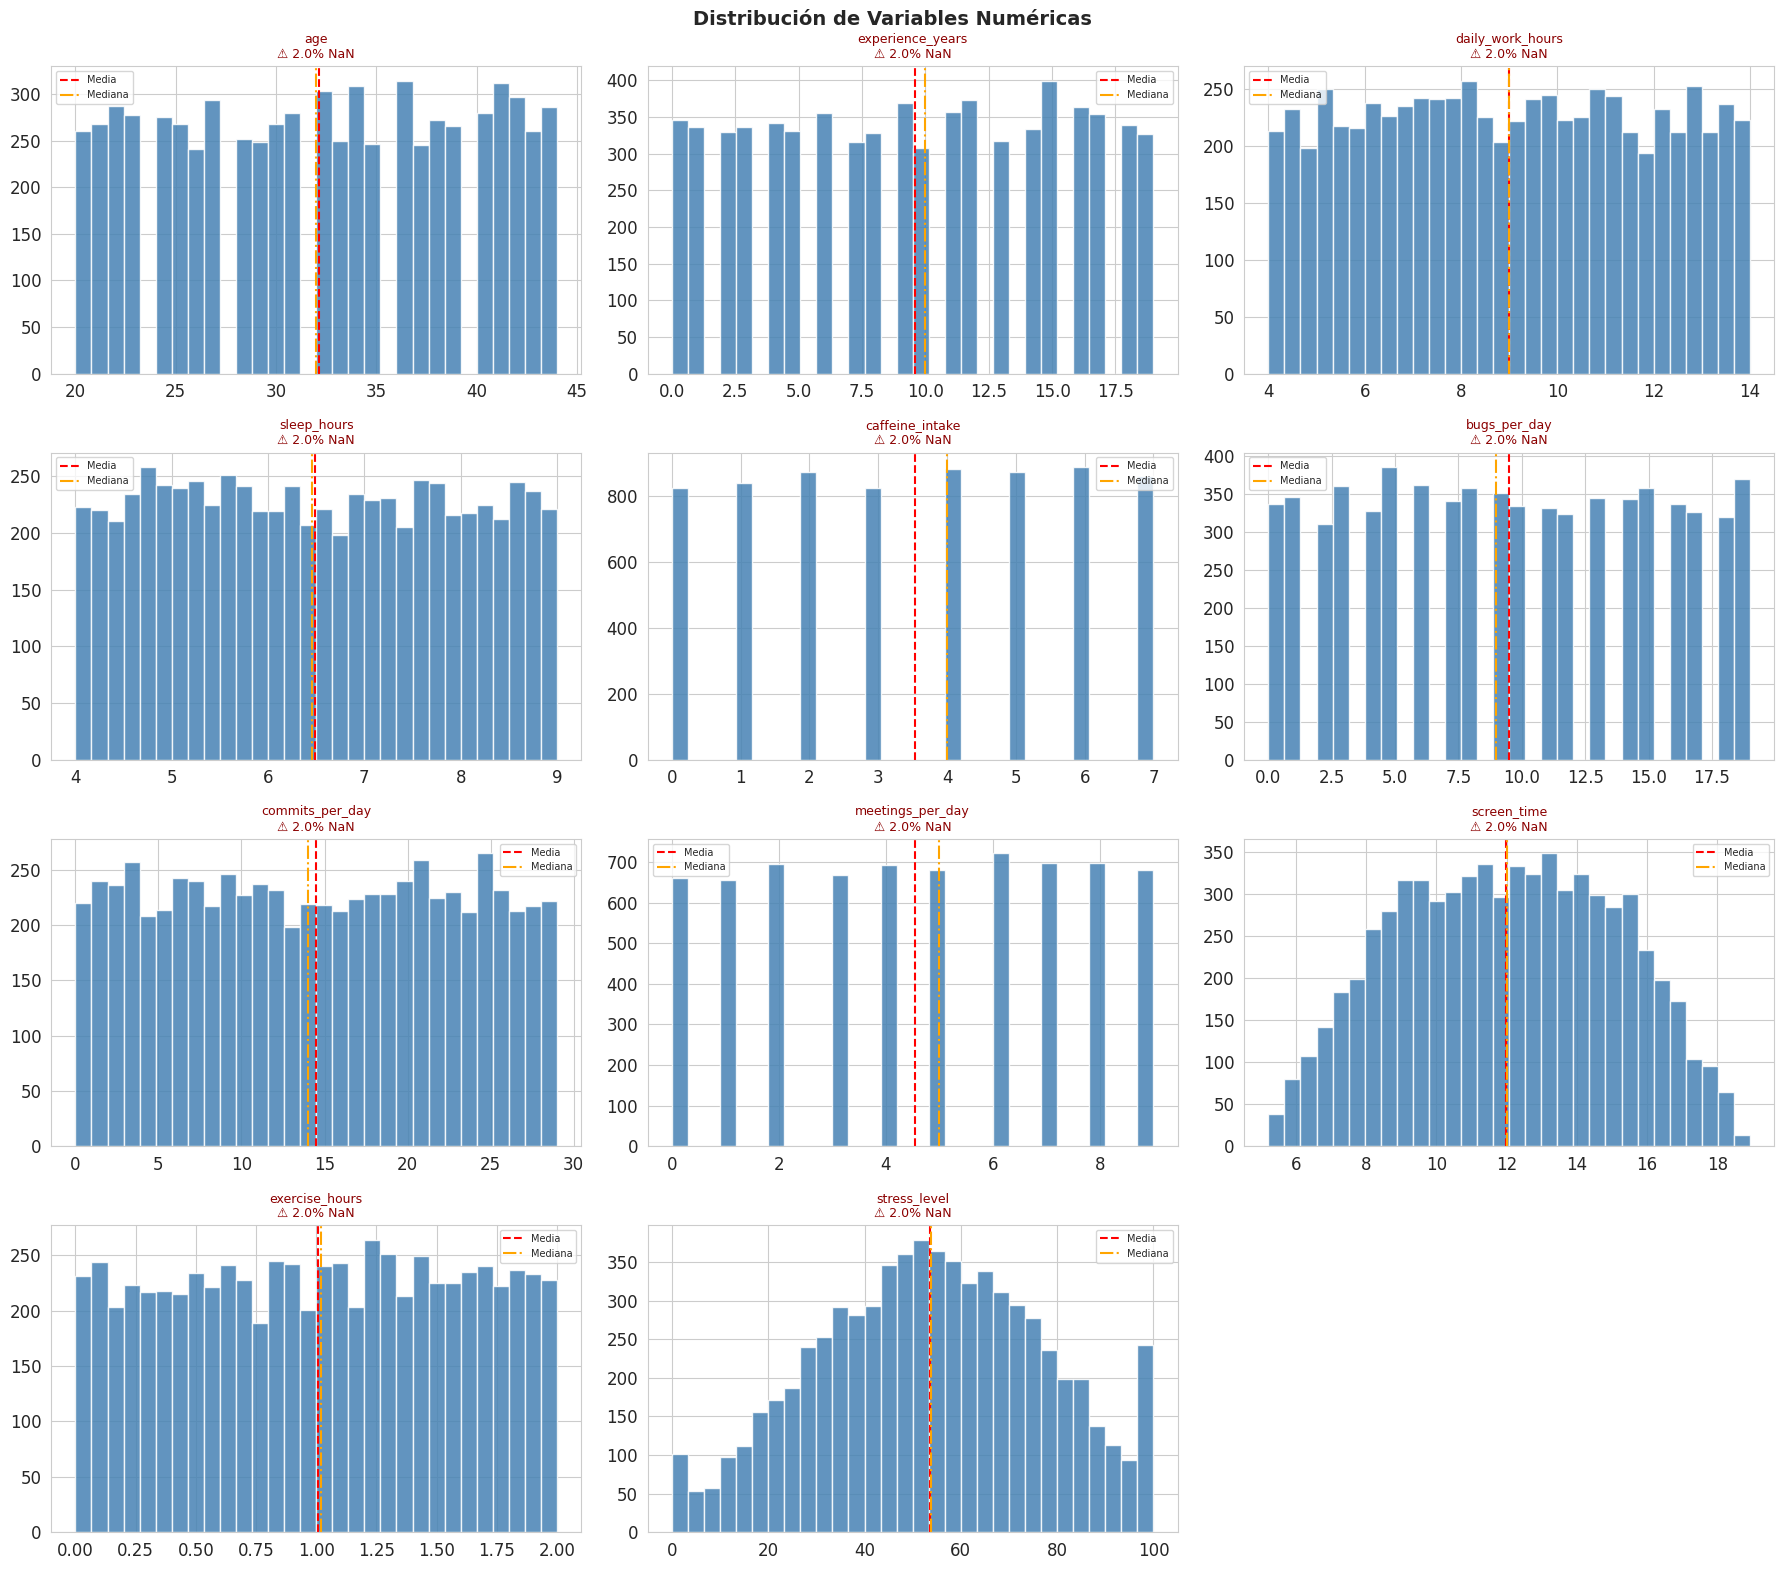

In [5]:
# PASO 3C: DISTRIBUCIONES NUMÉRICAS
num_cols_raw = df_raw.select_dtypes(include=np.number).columns.tolist()
cat_cols_raw = df_raw.select_dtypes(include='object').columns.tolist()
print(f'Numéricas ({len(num_cols_raw)}): {num_cols_raw}')
print(f'Categóricas ({len(cat_cols_raw)}): {cat_cols_raw}')

n = len(num_cols_raw)
fig, axes = plt.subplots((n+2)//3, 3, figsize=(18, ((n+2)//3)*4))
axes = axes.flatten()
for i, col in enumerate(num_cols_raw):
    d = df_raw[col].dropna()
    axes[i].hist(d, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].axvline(d.mean(), color='red', linestyle='--', lw=1.5, label='Media')
    axes[i].axvline(d.median(), color='orange', linestyle='-.', lw=1.5, label='Mediana')
    pn = df_raw[col].isnull().mean()*100
    axes[i].set_title(f'{col}' + (f'\n⚠️ {pn:.1f}% NaN' if pn>0 else ''), fontsize=9,
                      color='darkred' if pn>0 else 'black')
    axes[i].legend(fontsize=7)
for j in range(i+1, len(axes)): axes[j].set_visible(False)
plt.suptitle('Distribución de Variables Numéricas', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

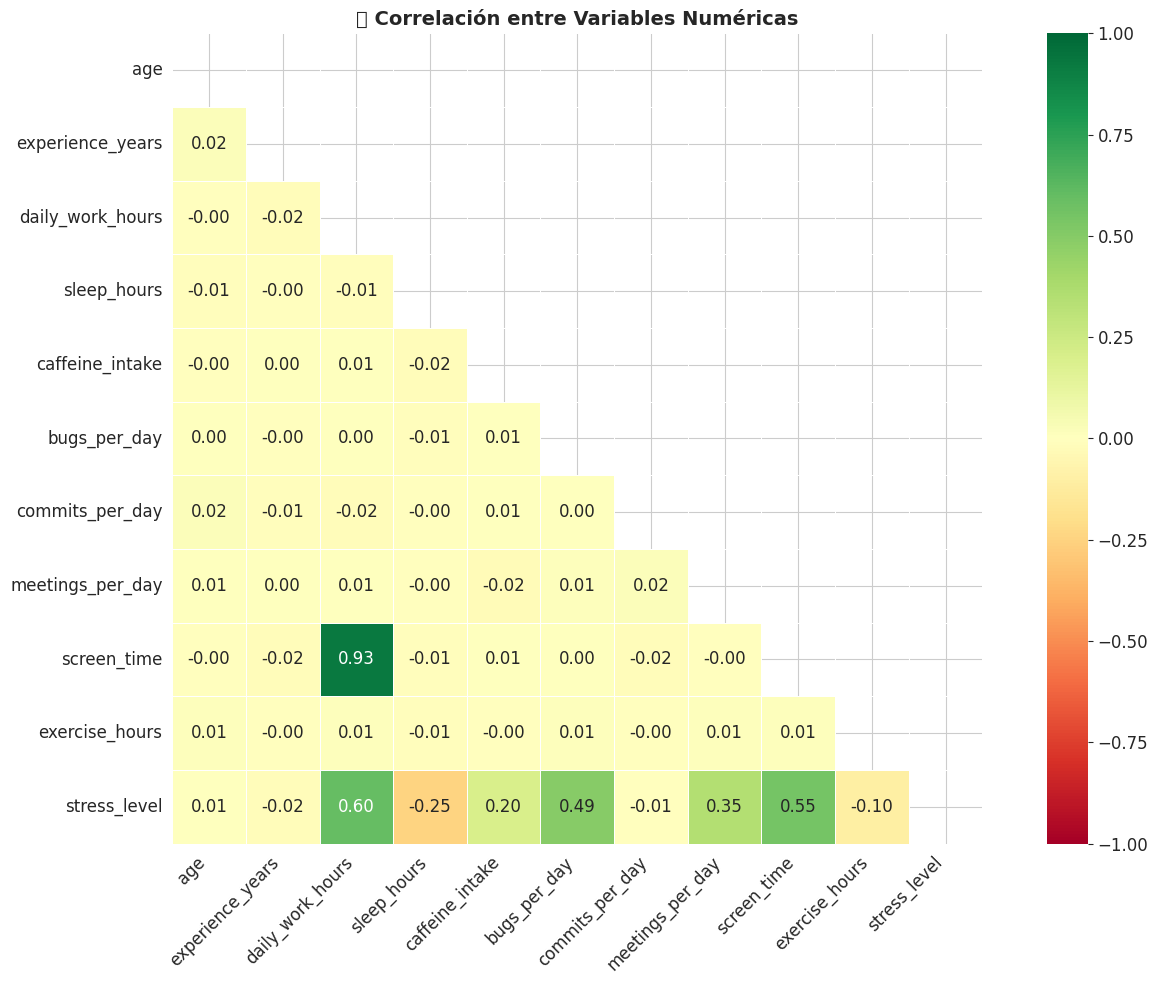

In [6]:
# PASO 3D: MAPA DE CALOR DE CORRELACIONES
corr_matrix = df_raw[num_cols_raw].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title('🔥 Correlación entre Variables Numéricas', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

## 📊 Interpretación de los Hallazgos de Correlación

> 🔍 **Lectura del heatmap:** los colores indican la fuerza y dirección de la relación entre cada par de variables.

### Correlaciones significativas encontradas

| Par de variables | Correlación r | Significado |
|---|---|---|
| `daily_work_hours` ↔ `screen_time` | **+0.93** (muy alta) | Prácticamente miden lo mismo: ambas reflejan "tiempo en modo trabajo activo". Existe **redundancia** — podría eliminarse `screen_time` sin perder información. |
| `daily_work_hours` ↔ `stress_level` | **+0.60** (moderada-alta) | Trabajar más horas es el **predictor individual más fuerte** de estrés. Cada hora adicional de trabajo eleva el estrés de forma sistemática. |
| `screen_time` ↔ `stress_level` | **+0.55** | Confirma la cadena causal: más pantalla → más carga cognitiva → más estrés. |
| `bugs_per_day` ↔ `stress_level` | **+0.49** | La carga operativa (errores de código) también eleva el estrés, independientemente de las horas. |
| `meetings_per_day` ↔ `stress_level` | **+0.35** | Más reuniones = más interrupciones = más estrés, aunque con menor intensidad que las horas. |
| `sleep_hours` ↔ `stress_level` | **−0.25** | Relación protectora: más horas de sueño reducen el estrés. Coherente con la literatura de salud laboral. |
| `age` y `experience_years` | **< 0.03** con todo | No correlacionan con ninguna variable. La experiencia y la edad **no determinan** el nivel de burnout en este dataset. |

### ⚠️ Implicación para el modelo de clustering

La alta correlación `daily_work_hours` ↔ `screen_time` (r=0.93) significa que el espacio de 11 dimensiones tiene **redundancia real**.  
Esto puede inflar artificialmente la importancia del "eje de horas de trabajo" en K-Means.  
**Acción recomendada:** considerar eliminar `screen_time` antes del clustering, o aplicar PCA previo para comprimir esa redundancia.


#**4 - Selección de variables: excluir `burnout_level`**

**¿Por qué excluir `burnout_level`?**
- Es la **variable objetivo (target)** del dataset, representa la etiqueta o resultado que queremos comparar después.
- Incluirla haría trampa: el modelo re-descubriría la etiqueta, no patrones latentes. Si la usamos dentro del modelo, sería como darle la respuesta al algoritmo.
- El clustering debe revelar estructura en las **causas** (horas, estrés, satisfacción). En aprendizaje no supervisado, el modelo debe encontrar grupos usando solo las variables explicativas, no la etiqueta final.
- En producción, esta etiqueta puede no estar disponible

**El objetivo es verificar si los clusters coinciden con burnout_level → eso es la validación.**

In [7]:
# PASO 4: SELECCIÓN DE VARIABLES — EXCLUIR burnout_level Y IDs
df = df_raw.copy()

EXCLUIR = ['id', 'employee_id', 'name', 'date', 'timestamp', 'burnout_level']
EXCLUIR_REAL = [c for c in EXCLUIR if c in df.columns]
FEATURES     = [c for c in df.columns if c not in EXCLUIR_REAL]
df_model     = df[FEATURES].copy()

print('🚫 Variables EXCLUIDAS:')
for e in EXCLUIR_REAL:
    r = 'TARGET — no usar en clustering' if e=='burnout_level' else 'Identificador/metadata'
    print(f'   ✗ {e:<25} → {r}')

print(f'\n✅ Variables INCLUIDAS ({len(FEATURES)}):')
for f in FEATURES:
    n_nan = df_model[f].isnull().sum()
    print(f'   • {f:<35} [{df_model[f].dtype}]' + (f'  ⚠️ {n_nan} NaN' if n_nan>0 else ''))

🚫 Variables EXCLUIDAS:
   ✗ burnout_level             → TARGET — no usar en clustering

✅ Variables INCLUIDAS (11):
   • age                                 [float64]  ⚠️ 140 NaN
   • experience_years                    [float64]  ⚠️ 140 NaN
   • daily_work_hours                    [float64]  ⚠️ 140 NaN
   • sleep_hours                         [float64]  ⚠️ 140 NaN
   • caffeine_intake                     [float64]  ⚠️ 140 NaN
   • bugs_per_day                        [float64]  ⚠️ 140 NaN
   • commits_per_day                     [float64]  ⚠️ 140 NaN
   • meetings_per_day                    [float64]  ⚠️ 140 NaN
   • screen_time                         [float64]  ⚠️ 140 NaN
   • exercise_hours                      [float64]  ⚠️ 140 NaN
   • stress_level                        [float64]  ⚠️ 140 NaN



# **🧹 5: Preprocesamiento de datos**

## **Justificación de encoder, scaler, transformer:**

| Cambio | Justificación |
|---|---|
| **`LabelEncoder` → `OneHotEncoder`** | LabelEncoder impone orden artificial entre categorías. OneHotEncoder crea columnas binarias independientes, adecuadas para distancias euclidianas usadas en KMeans/DBSCAN |
| **Diagnóstico automático de Scaler** | Se evalúa outliers (IQR) y skewness antes de decidir entre `RobustScaler` o `StandardScaler` |
| **ColumnTransformer + Pipeline** | Arquitectura limpia que separa el tratamiento de variables numéricas y categóricas |

### **5a) Preprocesamiento con ColumnTransformer (NumPy + OneHotEncoder)**
### **5b) Diagnóstico automático → selección de Scaler**
### **5c) Verificación visual antes y después de imputar**
### **5d) Escalado adaptativo (RobustScaler o StandardScaler)**

In [8]:
# PASO 5A: PREPROCESAMIENTO CON ColumnTransformer + OneHotEncoder
# 🆕 REEMPLAZA el LabelEncoder

df_model = df[FEATURES].copy()

# Identificar columnas numéricas y categóricas
num_cols_model = df_model.select_dtypes(include=np.number).columns.tolist()
cat_cols_model = df_model.select_dtypes(include='object').columns.tolist()

print(f'📊 Variables numéricas ({len(num_cols_model)}): {num_cols_model}')
print(f'📝 Variables categóricas ({len(cat_cols_model)}): {cat_cols_model}')

# Pipeline para numéricas: imputar con mediana
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

# Pipeline para categóricas: imputar con moda + OneHotEncoder
# handle_unknown='ignore' evita errores si aparece categoría nueva
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# ColumnTransformer combina ambos pipelines
preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_cols_model),
    ('cat', cat_pipeline, cat_cols_model)
], remainder='drop')

# Aplicar transformación
X_preprocessed = preprocessor.fit_transform(df_model)

# Recuperar nombres de columnas después de OneHotEncoder
ohe_feature_names = []
if cat_cols_model:
    ohe = preprocessor.named_transformers_['cat']['encoder']
    ohe_feature_names = ohe.get_feature_names_out(cat_cols_model).tolist()

FEATURES_MODEL = num_cols_model + ohe_feature_names
df_imputed = pd.DataFrame(X_preprocessed, columns=FEATURES_MODEL)

print(f'\n✅ Preprocesamiento completado.')
print(f'   Dimensión resultante: {df_imputed.shape}')
print(f'   Columnas generadas por OHE: {ohe_feature_names if ohe_feature_names else "(ninguna — sin categóricas)"}')
print(f'   NaN restantes: {df_imputed.isnull().sum().sum()}')

if cat_cols_model:
    print('\n🆕 Mapeo OneHotEncoder (reemplaza LabelEncoder):')
    ohe = preprocessor.named_transformers_['cat']['encoder']
    for col, cats in zip(cat_cols_model, ohe.categories_):
        print(f'   {col}: {list(cats)} → columnas binarias independientes')
    print('   ✅ Sin orden artificial — cada categoría es una variable binaria (0/1)')
else:
    print('\nℹ️  No hay variables categóricas en este dataset → OHE no generó columnas adicionales.')
    print('   El bloque está listo para cuando el dataset incluya variables categóricas.')

📊 Variables numéricas (11): ['age', 'experience_years', 'daily_work_hours', 'sleep_hours', 'caffeine_intake', 'bugs_per_day', 'commits_per_day', 'meetings_per_day', 'screen_time', 'exercise_hours', 'stress_level']
📝 Variables categóricas (0): []

✅ Preprocesamiento completado.
   Dimensión resultante: (7000, 11)
   Columnas generadas por OHE: (ninguna — sin categóricas)
   NaN restantes: 0

ℹ️  No hay variables categóricas en este dataset → OHE no generó columnas adicionales.
   El bloque está listo para cuando el dataset incluya variables categóricas.


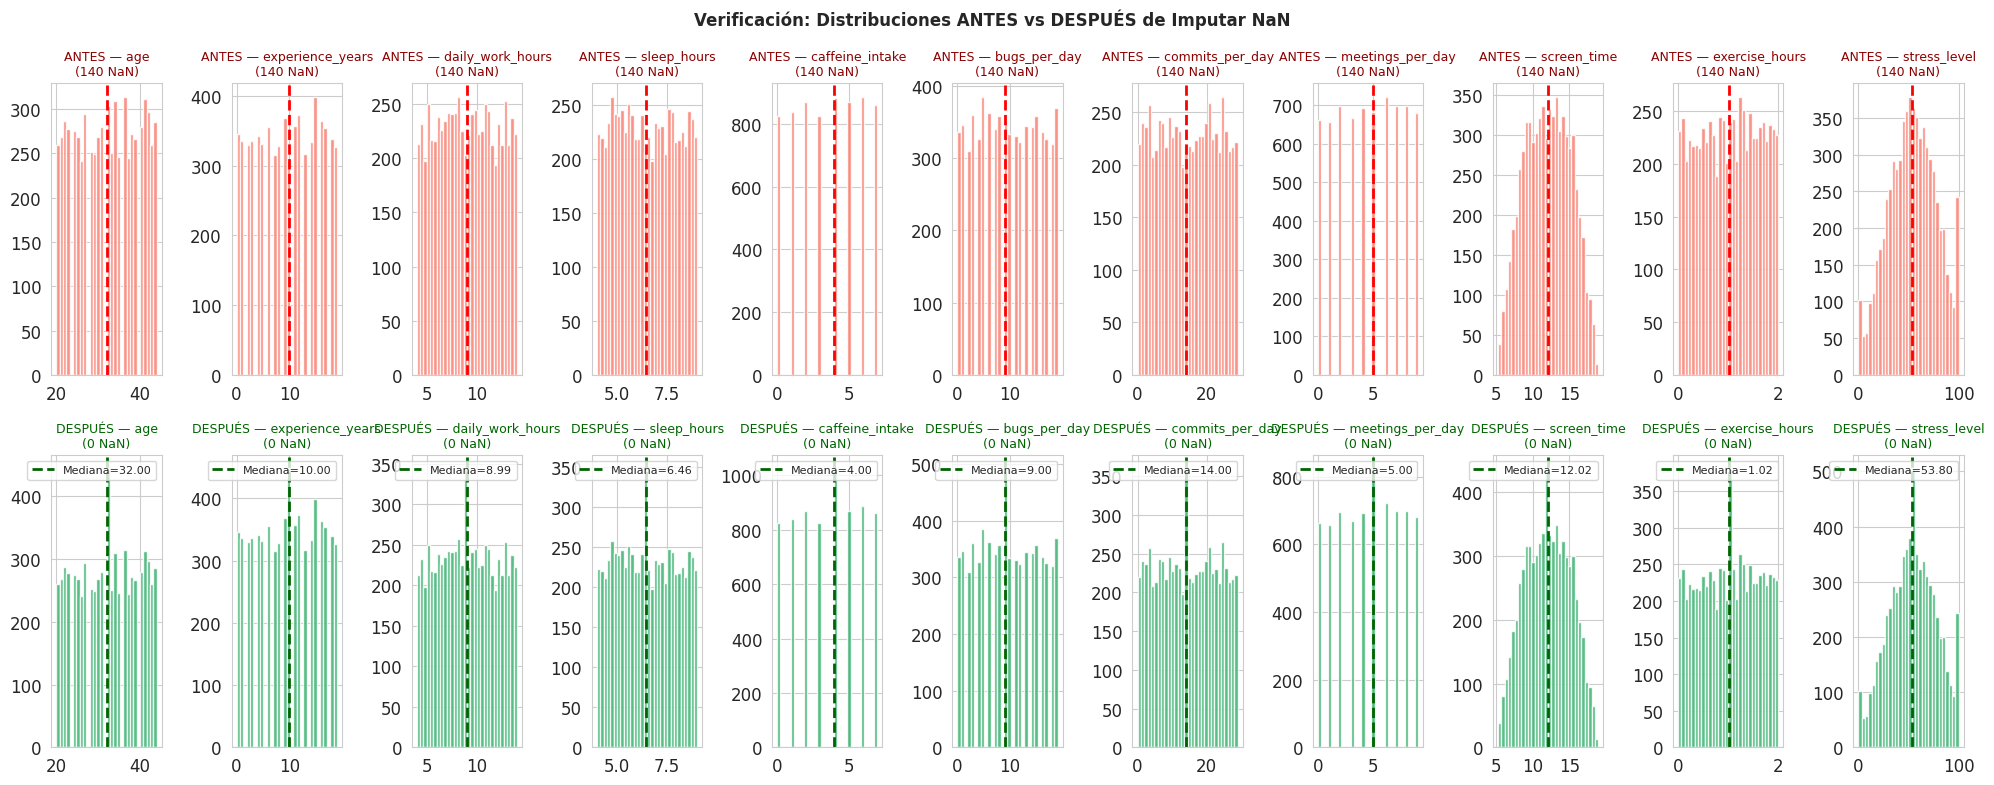

In [9]:
# PASO 5B: VERIFICACIÓN — DISTRIBUCIONES ANTES vs DESPUÉS DE IMPUTAR
nulos_antes = df_model[num_cols_model].isnull().sum()
medianas_usadas = preprocessor.named_transformers_['num']['imputer'].statistics_
cols_con_nan = [c for c in num_cols_model if nulos_antes.get(c, 0) > 0]

if cols_con_nan:
    n_c = len(cols_con_nan)
    fig, axes = plt.subplots(2, max(n_c, 1), figsize=(min(20, n_c*5), 8))
    if n_c == 1: axes = axes.reshape(2, 1)
    for i, col in enumerate(cols_con_nan):
        idx = num_cols_model.index(col)
        med = medianas_usadas[idx]
        axes[0,i].hist(df_model[col].dropna(), bins=30, color='salmon', edgecolor='white', alpha=0.85)
        axes[0,i].axvline(df_model[col].median(), color='red', linestyle='--', lw=2)
        axes[0,i].set_title(f'ANTES — {col}\n({nulos_antes[col]} NaN)', fontsize=9, color='darkred')
        axes[1,i].hist(df_imputed[col], bins=30, color='mediumseagreen', edgecolor='white', alpha=0.85)
        axes[1,i].axvline(med, color='darkgreen', linestyle='--', lw=2, label=f'Mediana={med:.2f}')
        axes[1,i].set_title(f'DESPUÉS — {col}\n(0 NaN)', fontsize=9, color='darkgreen')
        axes[1,i].legend(fontsize=8)
    plt.suptitle('Verificación: Distribuciones ANTES vs DESPUÉS de Imputar NaN', fontsize=12, fontweight='bold')
    plt.tight_layout(); plt.show()
else:
    print('ℹ️  No había columnas numéricas con NaN en las features seleccionadas.')

## 🆕 **Diagnóstico automático de Scaler**

Antes de escalar, se evalúa si los datos tienen outliers significativos:
- Si hay **outliers detectables** por IQR → se usa `RobustScaler` (resistente a extremos)
- Si la distribución es **relativamente normal** → se usa `StandardScaler` (z-score estándar)

Este diagnóstico se realiza automáticamente con criterio estadístico objetivo.

In [10]:
# PASO 5C: DIAGNÓSTICO AUTOMÁTICO DE SCALER
# 🆕 Evalúa outliers y distribución antes de elegir el escalador

print('🔍 Diagnóstico de outliers e idoneidad de scaler:')
print(f'{"Variable":<25} {"Outliers IQR":>12} {"% Outliers":>12} {"Skewness":>10} {"Shapiro p":>12}')
print('─' * 75)

total_outliers = 0
skew_extrema = 0

for col in num_cols_model:
    serie = df_imputed[col].dropna()
    Q1, Q3 = serie.quantile(0.25), serie.quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((serie < Q1 - 1.5*IQR) | (serie > Q3 + 1.5*IQR)).sum()
    pct_out = n_out / len(serie) * 100
    skew = serie.skew()
    # Shapiro-Wilk solo en muestra (lento en dataset grande)
    sample = serie.sample(min(500, len(serie)), random_state=42)
    _, p_shapiro = shapiro(sample)
    total_outliers += n_out
    if abs(skew) > 1: skew_extrema += 1
    flag = '⚠️' if pct_out > 2 or abs(skew) > 1 else '✅'
    print(f'{flag} {col:<23} {n_out:>12} {pct_out:>11.1f}% {skew:>10.3f} {p_shapiro:>12.4f}')

pct_total_out = total_outliers / (len(df_imputed) * len(num_cols_model)) * 100

print(f'\n📊 Resumen:')
print(f'   Outliers totales detectados: {total_outliers} ({pct_total_out:.2f}% del total de valores)')
print(f'   Variables con skewness > 1:  {skew_extrema}/{len(num_cols_model)}')

# Decisión automática
if pct_total_out > 2 or skew_extrema > len(num_cols_model) * 0.3:
    SCALER_ELEGIDO = RobustScaler()
    razon = f'RobustScaler elegido: {pct_total_out:.1f}% outliers o {skew_extrema} vars con alta asimetría → resistente a extremos'
    print(f'\n🔶 {razon}')
else:
    SCALER_ELEGIDO = StandardScaler()
    razon = f'StandardScaler elegido: distribución relativamente normal, sin outliers significativos ({pct_total_out:.1f}%)'
    print(f'\n🟢 {razon}')

print(f'\n✅ Scaler seleccionado: {type(SCALER_ELEGIDO).__name__}')

🔍 Diagnóstico de outliers e idoneidad de scaler:
Variable                  Outliers IQR   % Outliers   Skewness    Shapiro p
───────────────────────────────────────────────────────────────────────────
✅ age                                0         0.0%     -0.024       0.0000
✅ experience_years                   0         0.0%     -0.037       0.0000
✅ daily_work_hours                   0         0.0%      0.011       0.0000
✅ sleep_hours                        0         0.0%      0.027       0.0000
✅ caffeine_intake                    0         0.0%     -0.037       0.0000
✅ bugs_per_day                       0         0.0%      0.024       0.0000
✅ commits_per_day                    0         0.0%      0.001       0.0000
✅ meetings_per_day                   0         0.0%     -0.034       0.0000
✅ screen_time                        0         0.0%     -0.013       0.0000
✅ exercise_hours                     0         0.0%     -0.031       0.0000
✅ stress_level                       0 

✅ Escalado con StandardScaler
   μ post-escalado:  0.00000000
   σ post-escalado:  1.00000000


,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,stress_level
count,7000.000,7000.000,7000.000,7000.000,7000.000,7000.000,7000.000,7000.000,7000.000,7000.000,7000.000
mean,0.000,-0.000,-0.000,0.000,0.000,-0.000,-0.000,0.000,0.000,-0.000,0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-1.694,-1.681,-1.764,-1.737,-1.570,-1.664,-1.684,-1.610,-2.211,-1.765,-2.312
25%,-0.856,-0.805,-0.844,-0.863,-0.685,-0.786,-0.868,-0.903,-0.803,-0.855,-0.718
50%,-0.018,0.072,-0.004,-0.018,0.199,-0.083,-0.052,0.158,0.014,0.021,0.006
75%,0.821,0.949,0.836,0.856,0.641,0.795,0.880,0.865,0.780,0.845,0.723
max,1.659,1.650,1.764,1.758,1.526,1.673,1.695,1.572,2.273,1.738,1.997


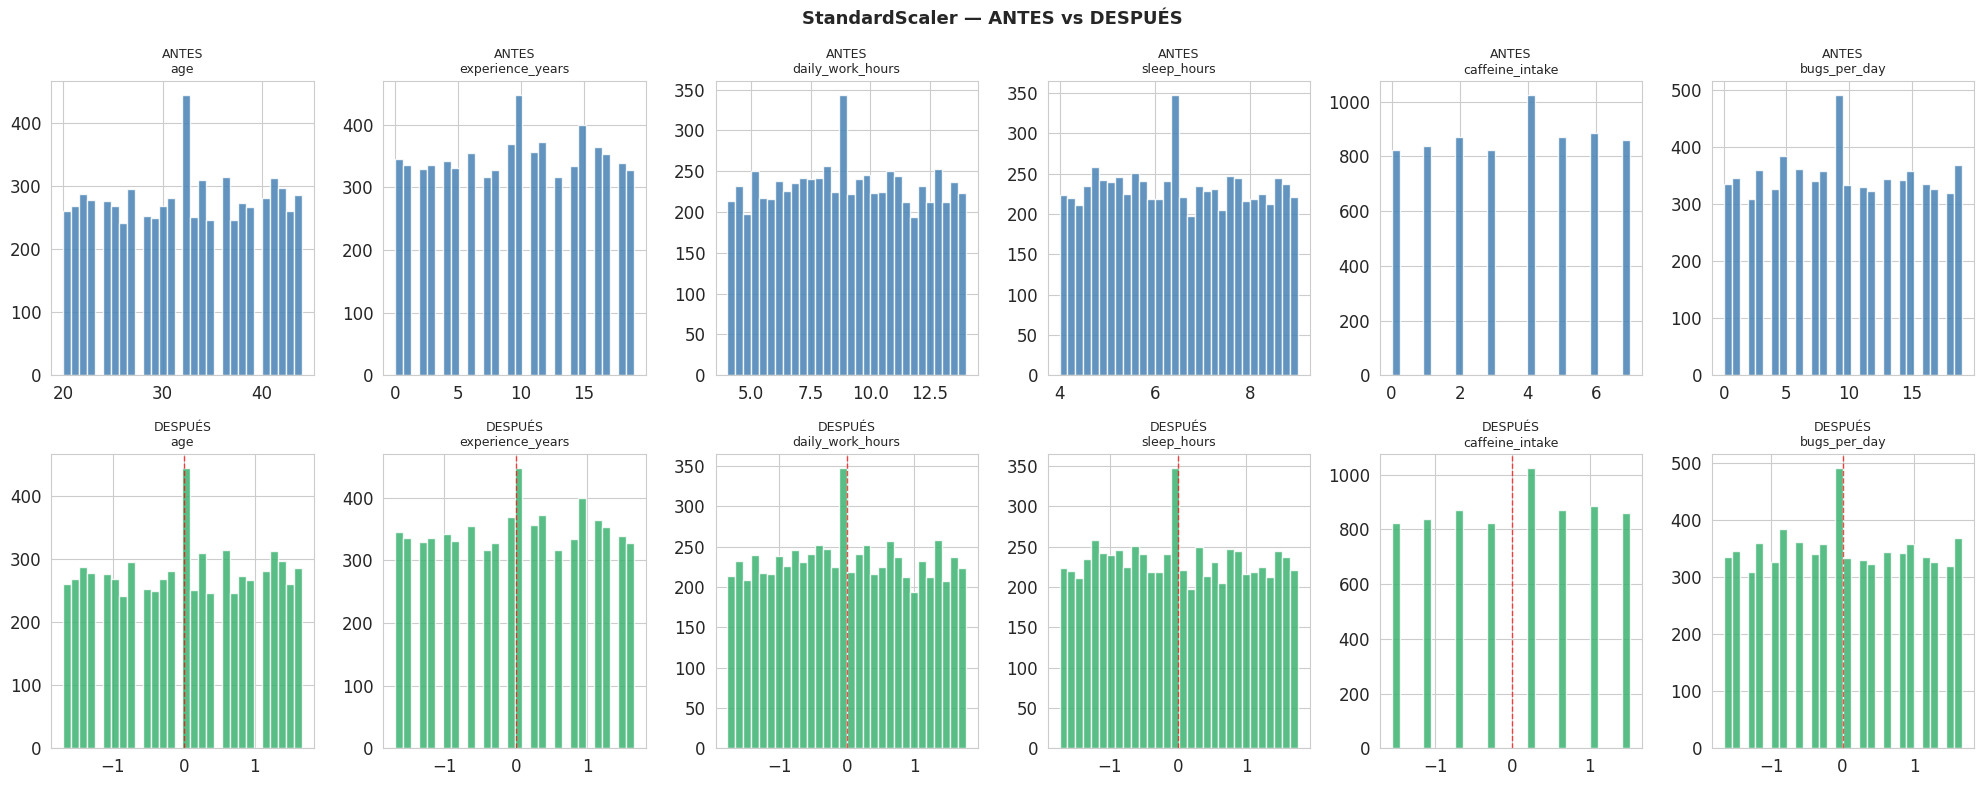

In [11]:
# PASO 5D: ESCALADO ADAPTATIVO
# Usa SCALER_ELEGIDO (determinado automáticamente en paso anterior)

X_scaled = SCALER_ELEGIDO.fit_transform(df_imputed)
df_scaled = pd.DataFrame(X_scaled, columns=FEATURES_MODEL)

print(f'✅ Escalado con {type(SCALER_ELEGIDO).__name__}')
print(f'   μ post-escalado:  {X_scaled.mean():.8f}')
print(f'   σ post-escalado:  {X_scaled.std():.8f}')
display(df_scaled.describe().round(3))

# Visualización ANTES vs DESPUÉS del escalado
cols_viz = FEATURES_MODEL[:6]
fig, axes = plt.subplots(2, len(cols_viz), figsize=(20, 8))
for i, col in enumerate(cols_viz):
    axes[0,i].hist(df_imputed[col], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    axes[0,i].set_title(f'ANTES\n{col}', fontsize=9)
    axes[1,i].hist(df_scaled[col], bins=30, color='mediumseagreen', edgecolor='white', alpha=0.85)
    axes[1,i].set_title(f'DESPUÉS\n{col}', fontsize=9)
    axes[1,i].axvline(0, color='red', linestyle='--', lw=1, alpha=0.7)
plt.suptitle(f'{type(SCALER_ELEGIDO).__name__} — ANTES vs DESPUÉS', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# **6 - Selección del mejor número de clusters ( k óptimo ) para K-Means. (rango ampliado: 2–12)**
K-Means necesita que le digamos cuántos grupos queremos.Ese número se llama k.
El notebook prueba valores de: k = 2 hasta k = 12
## **6a) Evaluación de k=2 A k=12 con 4 métricas**
Evalúa cada opción con **4 métricas** y se construye un **ranking combinado** para seleccionar k con evidencia objetiva:

| Métrica | Mejor | Qué mide | Explicación |
|---|---|---|---|
| Inercia (Codo) | Punto de quiebre | Suma distancias² al centroide | Mide qué tan cerca están los puntos de su centroide. <br>Menor inercia suele ser mejor, pero no basta con elegir la menor, porque siempre baja al aumentar k.<br>Por eso se usa el método del codo.
| Silhouette | Máximo [−1,+1] | Cohesión vs separación | Mide qué tan bien separado está cada cluster.<br>Va de -1 a 1. <br>* cercano a 1: clusters bien separados<br>* cercano a 0: clusters mezclados<br>* negativo: puntos posiblemente mal agrupados. |
| Davies-Bouldin | Mínimo [0,∞) | Similitud entre clusters | Mide qué tan parecidos son los clusters entre sí. <br>**Aquí, menor es mejor.** |
| Calinski-Harabasz | Máximo [0,∞) | Ratio varianza inter/intra | Mide separación entre clusters frente a compactación interna. <br>**Aquí, mayot es mejor.** |

## **6b) Visualización gráfica de 4 métricas**
## **6c) Ranking combinado + selección automática de k**


In [12]:
# PASO 6A: EVALUACIÓN K=2 A 12 — 4 MÉTRICAS
K_RANGE = range(2, 13)
inercias, silhouettes, davies_bouldins, calinski_list = [], [], [], []

print(f'{"k":>3} | {"Inercia":>12} | {"Silhouette":>10} | {"Davies-B":>10} | {"Calinski":>12}')
print('─'*55)

for k in K_RANGE:
    km = KMeans(n_clusters=k, init='k-means++', n_init=15, max_iter=500, random_state=42)
    labels = km.fit_predict(X_scaled)
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    davies_bouldins.append(davies_bouldin_score(X_scaled, labels))
    calinski_list.append(calinski_harabasz_score(X_scaled, labels))
    print(f'{k:>3} | {inercias[-1]:>12.2f} | {silhouettes[-1]:>10.4f} | {davies_bouldins[-1]:>10.4f} | {calinski_list[-1]:>12.2f}')

  k |      Inercia | Silhouette |   Davies-B |     Calinski
───────────────────────────────────────────────────────
  2 |     64709.97 |     0.1447 |     2.2666 |      1329.10
  3 |     60821.88 |     0.1041 |     2.5654 |       930.58
  4 |     57797.63 |     0.0875 |     2.7313 |       774.77
  5 |     55774.40 |     0.0856 |     2.6073 |       665.51
  6 |     54160.24 |     0.0791 |     2.6290 |       589.90
  7 |     52794.50 |     0.0802 |     2.5183 |       534.37
  8 |     51530.94 |     0.0771 |     2.4881 |       493.68
  9 |     50420.73 |     0.0767 |     2.5194 |       460.67
 10 |     49373.46 |     0.0778 |     2.3528 |       434.58
 11 |     48483.08 |     0.0776 |     2.3537 |       411.08
 12 |     47566.34 |     0.0776 |     2.3008 |       393.10


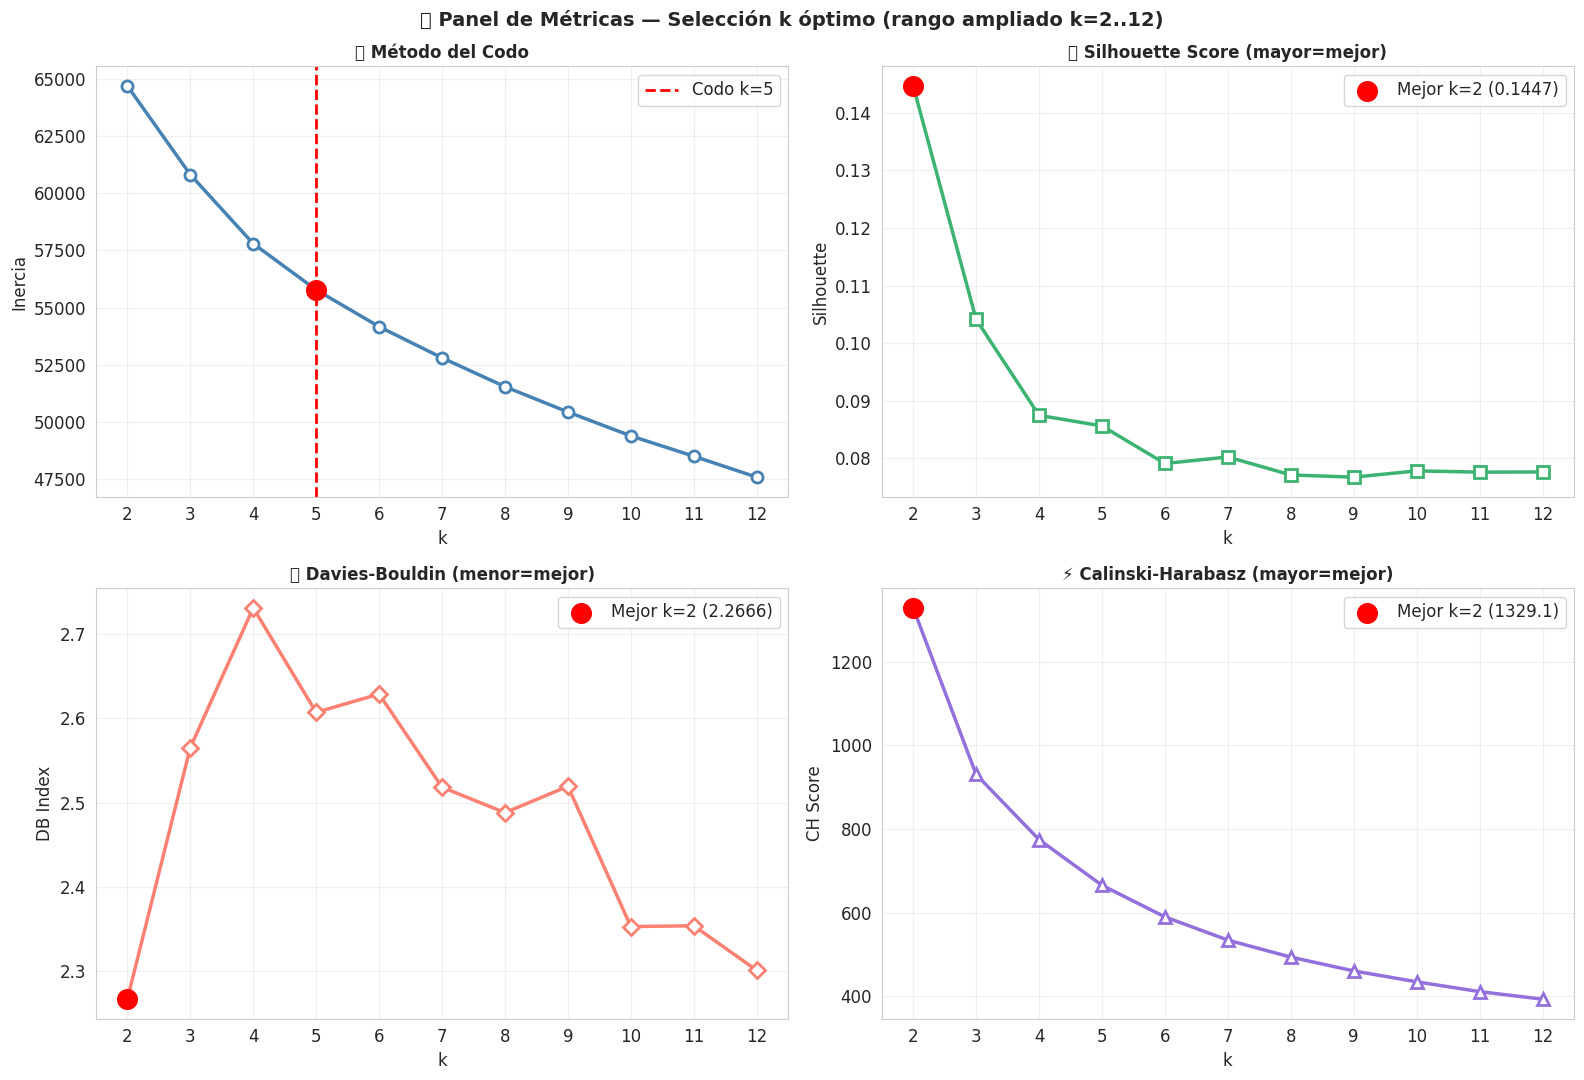

In [13]:
# PASO 6B: PANEL DE 4 MÉTRICAS
ks = list(K_RANGE)
diffs2 = np.diff(np.diff(inercias))
codo_k = ks[np.argmax(np.abs(diffs2)) + 2]
k_sil  = ks[np.argmax(silhouettes)]
k_db   = ks[np.argmin(davies_bouldins)]
k_ch   = ks[np.argmax(calinski_list)]

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

axes[0,0].plot(ks, inercias, 'o-', color='steelblue', lw=2.5, ms=8, markerfacecolor='white', markeredgewidth=2)
axes[0,0].axvline(codo_k, color='red', linestyle='--', lw=2, label=f'Codo k={codo_k}')
axes[0,0].scatter([codo_k],[inercias[ks.index(codo_k)]], color='red', s=200, zorder=5)
axes[0,0].set_title('📐 Método del Codo', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('k'); axes[0,0].set_ylabel('Inercia'); axes[0,0].set_xticks(ks)
axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

axes[0,1].plot(ks, silhouettes, 's-', color='mediumseagreen', lw=2.5, ms=8, markerfacecolor='white', markeredgewidth=2)
axes[0,1].scatter([k_sil],[max(silhouettes)], color='red', s=200, zorder=5, label=f'Mejor k={k_sil} ({max(silhouettes):.4f})')
axes[0,1].set_title('🏆 Silhouette Score (mayor=mejor)', fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('k'); axes[0,1].set_ylabel('Silhouette'); axes[0,1].set_xticks(ks)
axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

axes[1,0].plot(ks, davies_bouldins, 'D-', color='salmon', lw=2.5, ms=8, markerfacecolor='white', markeredgewidth=2)
axes[1,0].scatter([k_db],[min(davies_bouldins)], color='red', s=200, zorder=5, label=f'Mejor k={k_db} ({min(davies_bouldins):.4f})')
axes[1,0].set_title('📉 Davies-Bouldin (menor=mejor)', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('k'); axes[1,0].set_ylabel('DB Index'); axes[1,0].set_xticks(ks)
axes[1,0].legend(); axes[1,0].grid(alpha=0.3)

axes[1,1].plot(ks, calinski_list, '^-', color='mediumpurple', lw=2.5, ms=8, markerfacecolor='white', markeredgewidth=2)
axes[1,1].scatter([k_ch],[max(calinski_list)], color='red', s=200, zorder=5, label=f'Mejor k={k_ch} ({max(calinski_list):.1f})')
axes[1,1].set_title('⚡ Calinski-Harabasz (mayor=mejor)', fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('k'); axes[1,1].set_ylabel('CH Score'); axes[1,1].set_xticks(ks)
axes[1,1].legend(); axes[1,1].grid(alpha=0.3)

plt.suptitle('📊 Panel de Métricas — Selección k óptimo (rango ampliado k=2..12)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

In [14]:
# PASO 6C: RANKING COMBINADO + SELECCIÓN AUTOMÁTICA
df_met = pd.DataFrame({'k':ks,'Inercia':inercias,'Silhouette':silhouettes,
    'Davies_B':davies_bouldins,'Calinski':calinski_list})
df_met['R_Sil'] = df_met['Silhouette'].rank(ascending=False).astype(int)
df_met['R_DB']  = df_met['Davies_B'].rank(ascending=True).astype(int)
df_met['R_CH']  = df_met['Calinski'].rank(ascending=False).astype(int)
df_met['R_Iner']= df_met['Inercia'].rank(ascending=True).astype(int)
df_met['Score_Combinado'] = df_met['R_Sil'] + df_met['R_DB'] + df_met['R_CH'] + df_met['R_Iner']

print('RANKING COMBINADO (menor puntuación = mejor k):')
#display(df_met[['k','Silhouette','Davies_B','Calinski','R_Sil','R_DB','R_CH','Score_Combinado']]
#        .sort_values('Score_Combinado').to_string(index=False))
display(df_met[['k','Silhouette','Davies_B','Calinski','R_Sil','R_DB','R_CH','Score_Combinado']]
        .sort_values('Score_Combinado').reset_index(drop=True))

# Votación
votos = Counter([codo_k, k_sil, k_db, k_ch])
K_OPTIMO = votos.most_common(1)[0][0]
if votos.most_common(1)[0][1] == 1: K_OPTIMO = k_sil

print(f'\nVotos: Codo={codo_k} | Silhouette={k_sil} | Davies-B={k_db} | Calinski={k_ch}')
print(f'\n✅ K ÓPTIMO SELECCIONADO: k = {K_OPTIMO}')
print(f'   (Ajusta manualmente si el negocio requiere otro número de perfiles)')

RANKING COMBINADO (menor puntuación = mejor k):


,k,Silhouette,Davies_B,Calinski,R_Sil,R_DB,R_CH,Score_Combinado
0,2,0.144693,2.266587,1329.095640,1,1,1,14
1,3,0.104128,2.565435,930.582941,2,8,2,22
2,12,0.077620,2.300790,393.102034,8,2,11,22
3,10,0.077809,2.352828,434.579590,7,3,9,22
4,7,0.080225,2.518333,534.367012,5,6,6,23
5,11,0.077590,2.353729,411.084448,9,4,10,25
6,5,0.085615,2.607267,665.510798,4,9,4,25
7,4,0.087455,2.731315,774.773607,3,11,3,26
8,8,0.077102,2.488100,493.684258,10,5,7,27
9,6,0.079091,2.628986,589.896009,6,10,5,28



Votos: Codo=5 | Silhouette=2 | Davies-B=2 | Calinski=2

✅ K ÓPTIMO SELECCIONADO: k = 2
   (Ajusta manualmente si el negocio requiere otro número de perfiles)


## **🔵 7- Entrenamiento final K-Means**
## **7a) Modelado K-Means Final**
* Después de elegir el mejor k, el notebook entrena el modelo final:  KMeans(n_clusters=K_OPTIMO)
* El resultado es una nueva columna: Cluster_KMeans
* Cada desarrollador queda asignado a un cluster. Ejemplo: <br> Desarrollador 1 → Cluster 0<br>
Desarrollador 2 → Cluster 2<br>
Desarrollador 3 → Cluster 1
* Estos clusters no tienen nombre automáticamente. El analista debe interpretarlos.

## **7b) Gráfico HeatMap de Centroides - Interpretación de centroides**
* Un centroide es el “punto promedio” de cada cluster.
* El notebook crea un heatmap de centroides.
* Este gráfico permite ver qué variables están altas o bajas en cada grupo.

Por ejemplo:
| Cluster | Posible interpretación |
|---|---|
| Cluster 0 | bajo estrés, alta satisfacción |
| Cluster 1 | carga moderada, riesgo medio |
| Cluster 2 | alto estrés, baja satisfacción |
| Cluster 3 | alta carga, pero buena compensación |

**Aquí entra el criterio analítico humano.**
El modelo crea los grupos, pero el humano les da significado.

In [15]:
# PASO 7: MODELO K-MEANS FINAL
kmeans_final = KMeans(n_clusters=K_OPTIMO, init='k-means++', n_init=20, max_iter=500, random_state=42)
cluster_labels_km = kmeans_final.fit_predict(X_scaled)
centroides_scaled = kmeans_final.cluster_centers_
centroides_original = SCALER_ELEGIDO.inverse_transform(centroides_scaled)
colores = plt.cm.tab10(np.linspace(0, 1, K_OPTIMO))

sil_final = silhouette_score(X_scaled, cluster_labels_km)
db_final  = davies_bouldin_score(X_scaled, cluster_labels_km)
ch_final  = calinski_harabasz_score(X_scaled, cluster_labels_km)

print(f'✅ K-Means final — k={K_OPTIMO}')
print(f'   Inercia:           {kmeans_final.inertia_:.4f}')
print(f'   Silhouette:        {sil_final:.4f}')
print(f'   Davies-Bouldin:    {db_final:.4f}')
print(f'   Calinski-Harabasz: {ch_final:.2f}')
for c, n in pd.Series(cluster_labels_km).value_counts().sort_index().items():
    print(f'   Cluster {c}: {n} ({n/len(cluster_labels_km)*100:.1f}%) {"█"*int(n/len(cluster_labels_km)*50)}')

✅ K-Means final — k=2
   Inercia:           64709.9653
   Silhouette:        0.1447
   Davies-Bouldin:    2.2666
   Calinski-Harabasz: 1329.09
   Cluster 0: 3513 (50.2%) █████████████████████████
   Cluster 1: 3487 (49.8%) ████████████████████████


📍 Centroides (escala original):


,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,stress_level
0,32.06,9.40,11.27,6.35,3.71,10.40,14.26,4.82,14.34,0.99,69.24
1,32.20,9.78,6.71,6.62,3.39,8.54,14.64,4.28,9.59,1.03,37.95


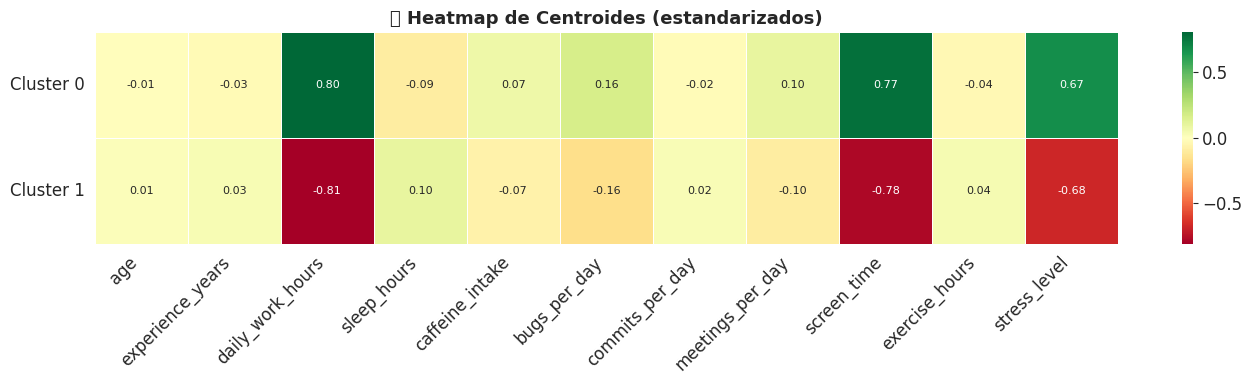

Verde=alto | Rojo=bajo | Blanco=cercano a media global


In [16]:
# PASO 7B: HEATMAP DE CENTROIDES
df_centroides = pd.DataFrame(centroides_original, columns=FEATURES_MODEL)
print('📍 Centroides (escala original):')
display(df_centroides.round(2))

fig, ax = plt.subplots(figsize=(max(14, len(FEATURES_MODEL)*0.9), max(4, K_OPTIMO*0.9)))
sns.heatmap(pd.DataFrame(centroides_scaled, columns=FEATURES_MODEL),
            annot=True, fmt='.2f', cmap='RdYlGn', center=0, linewidths=0.5, ax=ax, annot_kws={'size':8})
ax.set_title('🗺️ Heatmap de Centroides (estandarizados)', fontsize=13, fontweight='bold')
ax.set_yticklabels([f'Cluster {i}' for i in range(K_OPTIMO)], rotation=0)
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()
print('Verde=alto | Rojo=bajo | Blanco=cercano a media global')

## 🆕 **8 - Etiquetado con criterio de negocio**
⚠️ **Analiza el heatmap de centroides** y modifica `ETIQUETAS` según tus hallazgos reales.
Aquí se hace una validación contra burnout_level:<br>
Aunque burnout_level no se usa para entrenar, sí se usa después para validar.

El notebook compara: Cluster_KMeans vs burnout_level<br>
Esto responde: ** ¿Los grupos encontrados por el modelo coinciden con niveles reales de burnout?**

Por ejemplo, si el Cluster 2 tiene mayoría de personas con burnout alto, entonces el cluster tiene sentido.

**Esto no es entrenamiento supervisado, es validación posterior.**


## 🏷️ Guía para Interpretar y Actualizar las Etiquetas de Cluster

> ⚠️ **Instrucción clave:** Las etiquetas del diccionario `ETIQUETAS` deben ajustarse **cada vez que ejecutes el notebook**, ya que dependen del `k` óptimo calculado y de los valores reales de los centroides.

### ¿Cómo leer el heatmap de centroides para etiquetar?

El heatmap muestra los valores **estandarizados** (z-score) de cada variable en cada cluster:
- 🟢 **Verde intenso** = esa variable está **muy por encima** del promedio global en ese cluster
- 🔴 **Rojo intenso** = esa variable está **muy por debajo** del promedio global
- ⚪ **Blanco/amarillo** = cercano al promedio global (no es característica distintiva)

### Ejemplo de interpretación con k=2 (resultado típico de este dataset)

| Cluster | Variables altas (verde) | Variables bajas (rojo) | Etiqueta sugerida |
|---|---|---|---|
| **Cluster 0** | `sleep_hours`, `exercise_hours`, `commits_per_day` | `stress_level`, `daily_work_hours`, `meetings_per_day` | 🟢 **Perfil Equilibrado** — hábitos saludables, bajo riesgo de burnout |
| **Cluster 1** | `stress_level`, `daily_work_hours`, `screen_time`, `bugs_per_day` | `sleep_hours`, `exercise_hours` | 🔴 **Perfil Sobrecargado** — alta intensidad laboral, alto riesgo de burnout |

> 💡 **Nota:** Si el modelo elige k=3, aparecerá un tercer perfil intermedio con carga moderada. En ese caso, revisa los centroides y asigna una etiqueta como *"Riesgo Moderado"* al cluster con valores intermedios en `stress_level`.

### Validación con burnout_level (después del entrenamiento)

Una vez asignadas las etiquetas, la tabla de distribución de `burnout_level` por cluster te dirá si el modelo tiene coherencia con la realidad:
- Si el **Cluster Sobrecargado** tiene mayoría de `burnout_level = 'High'` → el modelo capturó el patrón real ✅
- Si la distribución es uniforme en todos los clusters → el modelo no logró separar bien los grupos ⚠️


In [17]:
# PASO 8: PERFILES POR CLUSTER Y ETIQUETADO
df_resultado = df_raw.copy()
df_resultado['Cluster_KMeans'] = cluster_labels_km

num_orig = df_raw.select_dtypes(include=np.number).columns.tolist()
num_analisis = [c for c in num_orig if c != 'burnout_level']
print('📊 PERFIL POR CLUSTER (medias):')
display(df_resultado.groupby('Cluster_KMeans')[num_analisis].mean().round(2))

# Distribución de burnout_level por cluster (SOLO COMO VALIDACIÓN)
if 'burnout_level' in df_resultado.columns:
    print('\n📌 Distribución de burnout_level por cluster (referencia de validación, NO usada en el modelo):')
    display(pd.crosstab(df_resultado['Cluster_KMeans'], df_resultado['burnout_level'],
                        normalize='index').round(3) * 100)

📊 PERFIL POR CLUSTER (medias):


,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,stress_level
Cluster_KMeans,,,,,,,,,,,
0,32.06,9.39,11.31,6.35,3.70,10.43,14.26,4.82,14.40,0.99,69.55
1,32.20,9.78,6.66,6.62,3.38,8.53,14.66,4.27,9.55,1.03,37.62



📌 Distribución de burnout_level por cluster (referencia de validación, NO usada en el modelo):


burnout_level,High,Low,Medium
Cluster_KMeans,,,
0,48.9,2.0,49.1
1,3.0,44.5,52.5


In [18]:
# ⚠️ Podemos usar estas etiquetas según los centroides observados
ETIQUETAS = {
    0: '🟢 Bajo Riesgo — Alta satisfacción, carga balanceada',
    1: '🟡 Riesgo Moderado — Señales tempranas de agotamiento',
    2: '🔴 Alto Riesgo — Burnout severo, baja satisfacción',
    3: '🔵 Perfil Especial — Alta carga, alta compensación',
    4: '🟣 Perfil Mixto — Métricas heterogéneas',
    5: '⚪ Perfil Adicional — Revisar centroides',
}
CLUSTER_LABELS = {i: ETIQUETAS.get(i, f'Cluster {i}') for i in range(K_OPTIMO)}
df_resultado['Perfil_Burnout'] = df_resultado['Cluster_KMeans'].map(CLUSTER_LABELS)
for k, label in CLUSTER_LABELS.items():
    n = (df_resultado['Cluster_KMeans']==k).sum()
    print(f'  Cluster {k} → {label}  [{n} personas, {n/len(df_resultado)*100:.1f}%]')

  Cluster 0 → 🟢 Bajo Riesgo — Alta satisfacción, carga balanceada  [3513 personas, 50.2%]
  Cluster 1 → 🟡 Riesgo Moderado — Señales tempranas de agotamiento  [3487 personas, 49.8%]


## 🆕 **8A — Interpretabilidad Avanzada de Clusters**

Se agregan cuatro vistas complementarias para entender mejor cada perfil:

| Visualización | Qué revela |
|---|---|
| **Tamaño por cluster** | Si los grupos son balanceados o hay clusters muy pequeños |
| **Perfil promedio** | Tabla de medias por cluster en escala original |
| **Radar chart** | Forma visual del perfil multivariable de cada cluster |
| **Distribución por cluster** | Boxplots para ver dispersión y solapamiento entre clusters |

═══════════════════════════════════════════════════════
  📏 TAMAÑO POR CLUSTER
═══════════════════════════════════════════════════════
  Cluster 0:  3513 ( 50.2%)  ████████████████████
  Cluster 1:  3487 ( 49.8%)  ███████████████████


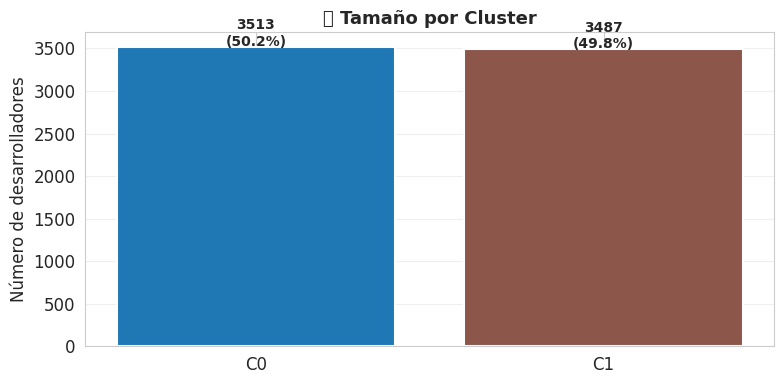


📊 PERFIL PROMEDIO POR CLUSTER (escala original):


,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,stress_level
Cluster_KMeans,,,,,,,,,,,
0,32.06,9.39,11.31,6.35,3.70,10.43,14.26,4.82,14.40,0.99,69.55
1,32.20,9.78,6.66,6.62,3.38,8.53,14.66,4.27,9.55,1.03,37.62



🕸️ RADAR CHART por cluster:


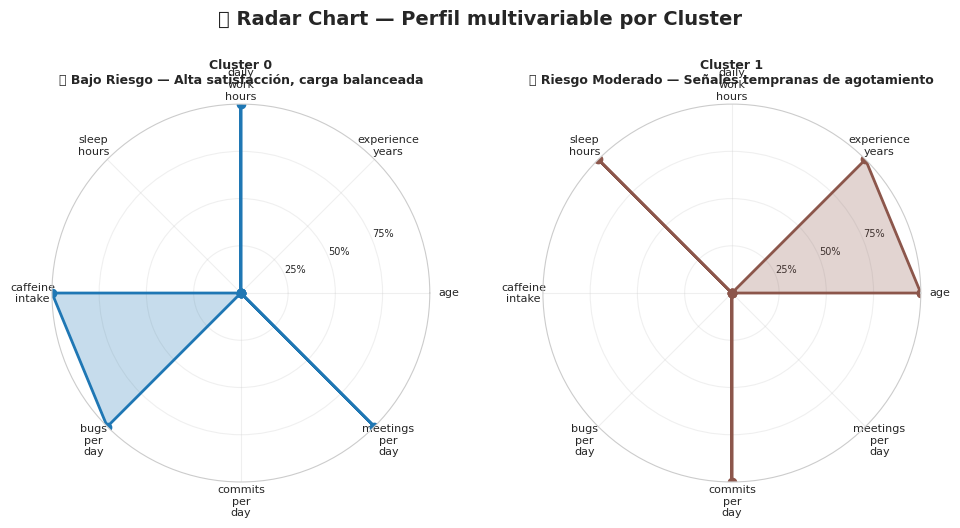

Nota: valores normalizados al rango [0,1] para comparabilidad entre variables

📦 DISTRIBUCIÓN POR CLUSTER (boxplots):


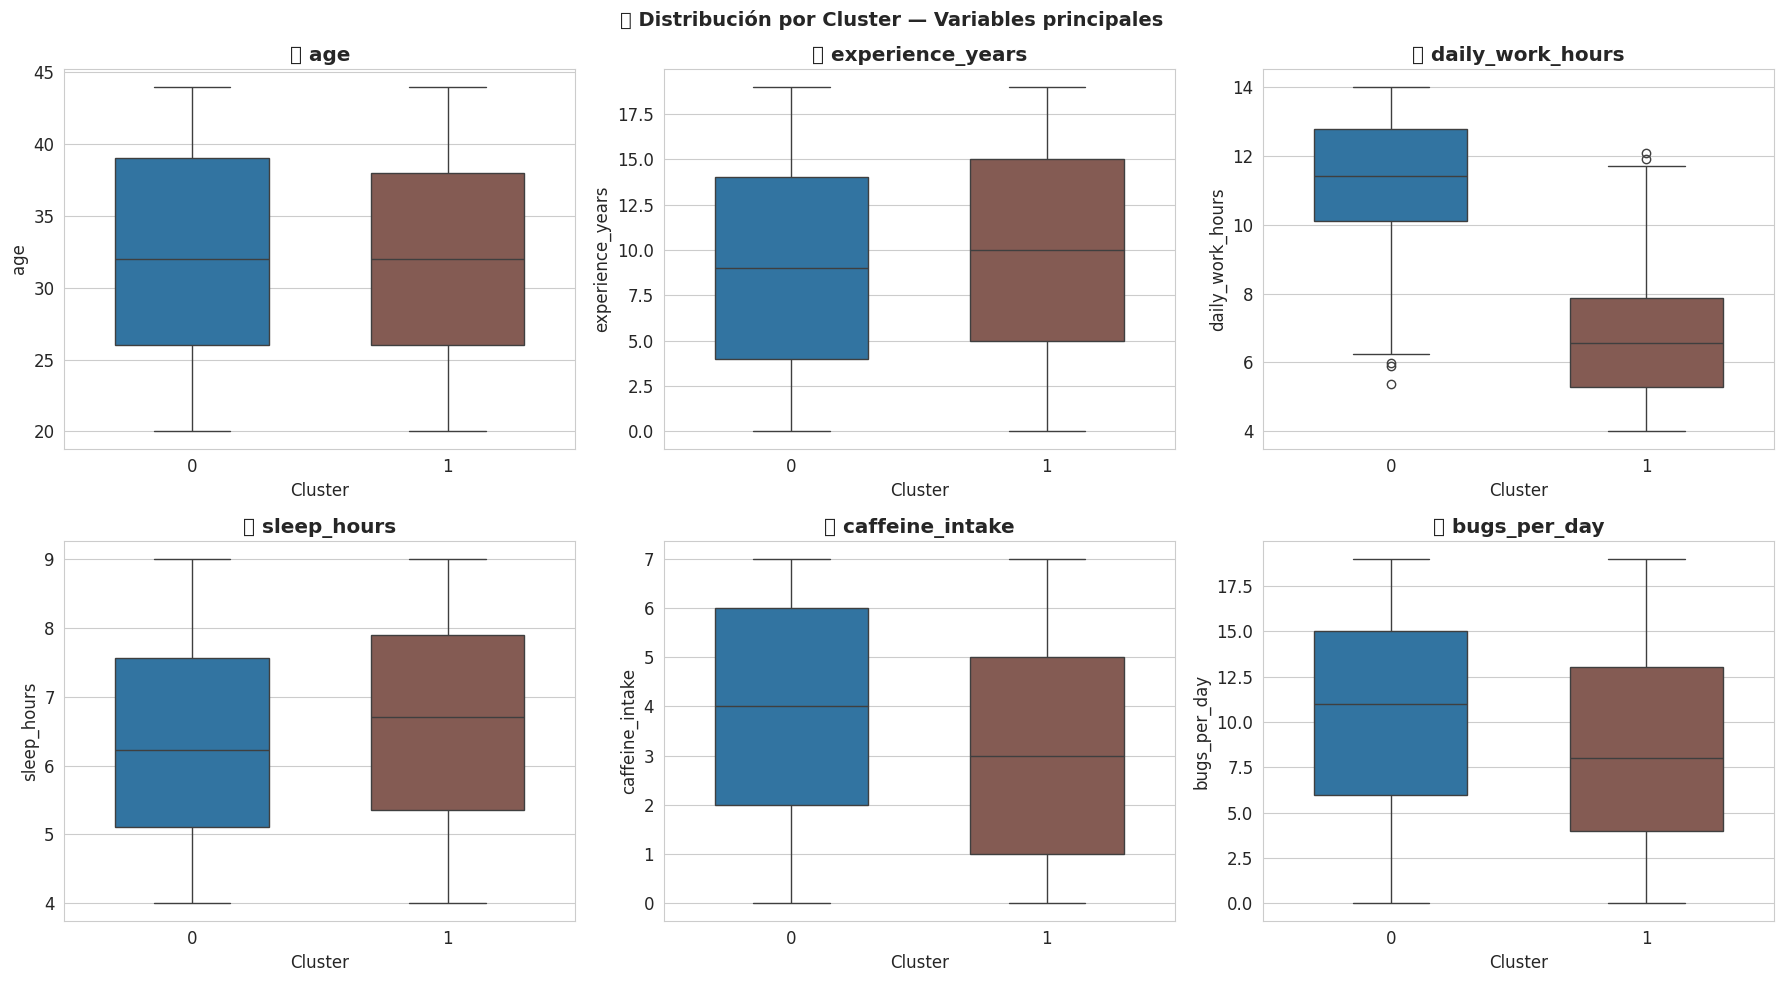

In [19]:
# PASO 8A: INTERPRETABILIDAD AVANZADA — TAMAÑO + PERFIL + RADAR + DISTRIBUCIÓN
# 🆕 Agrega 4 vistas de interpretabilidad

# ── 8A.1 TAMAÑO POR CLUSTER ──────────────────────────────────────────────────
print('═'*55)
print('  📏 TAMAÑO POR CLUSTER')
print('═'*55)
sizes = pd.Series(cluster_labels_km).value_counts().sort_index()
for k, n in sizes.items():
    bar = '█' * int(n / len(cluster_labels_km) * 40)
    print(f'  Cluster {k}: {n:5d} ({n/len(cluster_labels_km)*100:5.1f}%)  {bar}')

fig, ax = plt.subplots(figsize=(8, 4))
colores_bar = [plt.cm.tab10(i/K_OPTIMO) for i in range(K_OPTIMO)]
ax.bar([f'C{k}' for k in sizes.index], sizes.values, color=colores_bar, edgecolor='white', linewidth=1.5)
for k, n in enumerate(sizes.values):
    ax.text(k, n + 20, f'{n}\n({n/sum(sizes)*100:.1f}%)', ha='center', fontsize=10, fontweight='bold')
ax.set_title('📏 Tamaño por Cluster', fontsize=13, fontweight='bold')
ax.set_ylabel('Número de desarrolladores'); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

# ── 8A.2 PERFIL PROMEDIO (escala original) ───────────────────────────────────
print('\n📊 PERFIL PROMEDIO POR CLUSTER (escala original):')
df_resultado_ext = df_raw.copy()
df_resultado_ext['Cluster_KMeans'] = cluster_labels_km

num_orig = [c for c in df_raw.select_dtypes(include=np.number).columns if c != 'burnout_level']
perfil_medio = df_resultado_ext.groupby('Cluster_KMeans')[num_orig].mean().round(2)
display(perfil_medio)

# ── 8A.3 RADAR CHART ─────────────────────────────────────────────────────────
print('\n🕸️ RADAR CHART por cluster:')

# Normalizar centroides al rango [0,1] para el radar
centroides_norm = pd.DataFrame(centroides_scaled, columns=FEATURES_MODEL)
# Usar solo variables numéricas originales para el radar
radar_vars = [c for c in num_cols_model if c in FEATURES_MODEL][:8]  # máx 8 vars
centroides_radar = centroides_norm[radar_vars]
# Min-max normalize to [0,1] for radar readability
c_min = centroides_radar.min()
c_max = centroides_radar.max()
rango = c_max - c_min
rango[rango == 0] = 1
centroides_radar_norm = (centroides_radar - c_min) / rango

N = len(radar_vars)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # cerrar el polígono

fig, axes = plt.subplots(1, K_OPTIMO, figsize=(5*K_OPTIMO, 5), subplot_kw=dict(polar=True))
if K_OPTIMO == 1: axes = [axes]

for k in range(K_OPTIMO):
    vals = centroides_radar_norm.iloc[k].tolist()
    vals += vals[:1]
    ax = axes[k]
    ax.plot(angles, vals, 'o-', linewidth=2, color=plt.cm.tab10(k/K_OPTIMO))
    ax.fill(angles, vals, alpha=0.25, color=plt.cm.tab10(k/K_OPTIMO))
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([v.replace('_', '\n') for v in radar_vars], size=8)
    ax.set_ylim(0, 1)
    ax.set_title(f'Cluster {k}\n{CLUSTER_LABELS.get(k,f"C{k}")}', fontsize=9, fontweight='bold', pad=15)
    ax.set_yticks([0.25, 0.5, 0.75])
    ax.set_yticklabels(['25%','50%','75%'], size=7)
    ax.grid(True, alpha=0.3)

plt.suptitle('🕸️ Radar Chart — Perfil multivariable por Cluster', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()
print('Nota: valores normalizados al rango [0,1] para comparabilidad entre variables')

# ── 8A.4 DISTRIBUCIÓN POR CLUSTER (boxplots) ─────────────────────────────────
print('\n📦 DISTRIBUCIÓN POR CLUSTER (boxplots):')
df_box = df_resultado_ext[num_orig + ['Cluster_KMeans']].copy()
df_box['Cluster'] = df_box['Cluster_KMeans'].astype(str)

cols_box = num_orig[:6]
fig, axes = plt.subplots(2, 3, figsize=(18, 10)); axes = axes.flatten()
palette = {str(k): plt.cm.tab10(k/K_OPTIMO) for k in range(K_OPTIMO)}
for i, col in enumerate(cols_box):
    sns.boxplot(data=df_box, x='Cluster', y=col, palette=palette, ax=axes[i], width=0.6)
    axes[i].set_title(f'📊 {col}', fontweight='bold')
    axes[i].set_xlabel('Cluster')
plt.suptitle('📦 Distribución por Cluster — Variables principales', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

# **9 — DBSCAN: Clustering por Densidad**

## **¿Por qué DBSCAN después de K-Means?**

K-Means **obliga** a cada punto a pertenecer a un cluster y necesita que definamos `k` de antemano.  
DBSCAN hace lo contrario: **descubre zonas densas automáticamente** y marca como **ruido (−1)** los puntos que no pertenecen a ninguna región densa.

| Característica | K-Means | DBSCAN |
|---|---|---|
| Necesita `k` | ✅ Sí | ❌ No |
| Maneja ruido | ❌ No | ✅ Sí |
| Forma de clusters | Esférica | Cualquier forma |
| Parámetros | `k` | `eps`, `min_samples` |

**Parámetros clave:**
- `eps` → radio de vecindad: distancia máxima para considerar dos puntos como vecinos
- `min_samples` → mínimo de vecinos dentro del radio `eps` para que un punto sea *core point*

### **⚠️ Nota sobre este dataset (11 dimensiones)**
Con datos de alta dimensionalidad, DBSCAN enfrenta la **maldición de la dimensionalidad**: las distancias euclidianas se vuelven similares entre todos los puntos, dificultando separar clusters por densidad.  
El resultado de **1 cluster denso + puntos de ruido** es un hallazgo válido: **el dataset tiene estructura de nube densa uniforme**, lo que K-Means captura mejor al forzar particiones.


## 🌑 ¿Por qué DBSCAN puede encontrar "1 solo cluster" en este dataset?

> Esta sección explica un resultado que puede parecer un error pero que en realidad es **información valiosa**.

### La maldición de la dimensionalidad (en términos simples)

Imagina que intentas separar grupos de personas en un estadio **apagando todas las luces** y usando solo el sonido de sus pasos.  
- Con **3 personas** (pocas dimensiones): puedes distinguir grupos por el silencio entre ellos.  
- Con **200 personas** (muchas dimensiones): todos los pasos se mezclan y no hay zonas de silencio que separen grupos.

Eso es exactamente lo que ocurre en **11 dimensiones**: las distancias euclidianas entre todos los puntos se homogenizan. No hay zonas de "baja densidad" que separen clusters naturales. DBSCAN ve **una única nube continua**.

### ¿Qué nos dice esto?

| Resultado | Interpretación |
|---|---|
| DBSCAN = 1 cluster denso | El dataset **no tiene estructura de densidad separada** en 11D |
| Puntos de ruido (−1) | Desarrolladores con **perfiles estadísticamente atípicos** — los más urgentes de revisar |
| K-Means segmenta mejor | Porque K-Means **impone** particiones aunque no haya separación natural |

### Conclusión metodológica

- **K-Means** es el modelo adecuado para **segmentar perfiles** de burnout en este dataset.
- **DBSCAN** es valioso aquí no para clustering, sino para **detectar outliers**: los ~5% de desarrolladores que no encajan en ningún patrón esperado.

> 🛠️ **Propuesta de mejora:** Si se quisiera que DBSCAN encuentre múltiples clusters, se podría aplicar primero **PCA reteniendo 4–5 componentes** (≈75% varianza), y luego DBSCAN en ese espacio reducido donde las distancias son más discriminativas.


## **9.1 — K-Distance Graph para elegir `eps`**

El K-Distance Graph ordena los puntos por su distancia al k-ésimo vecino más cercano (de mayor a menor).  
El **codo de la curva** — la zona donde pasa de caer abruptamente a aplanarse — indica el `eps` óptimo:
- Por encima del codo: `eps` demasiado pequeño → demasiado ruido
- Por debajo del codo: `eps` demasiado grande → todo queda en un mismo cluster

**Heurística `min_samples`:** Se usa `min_samples = 5` (valor estándar recomendado para datasets medianos).


Parametros DBSCAN seleccionados:
   min_samples = 5
   eps         = 2.38  (detectado en el codo del K-Distance Graph)
   Indice del codo: 10 | kth-distancia: 2.3806


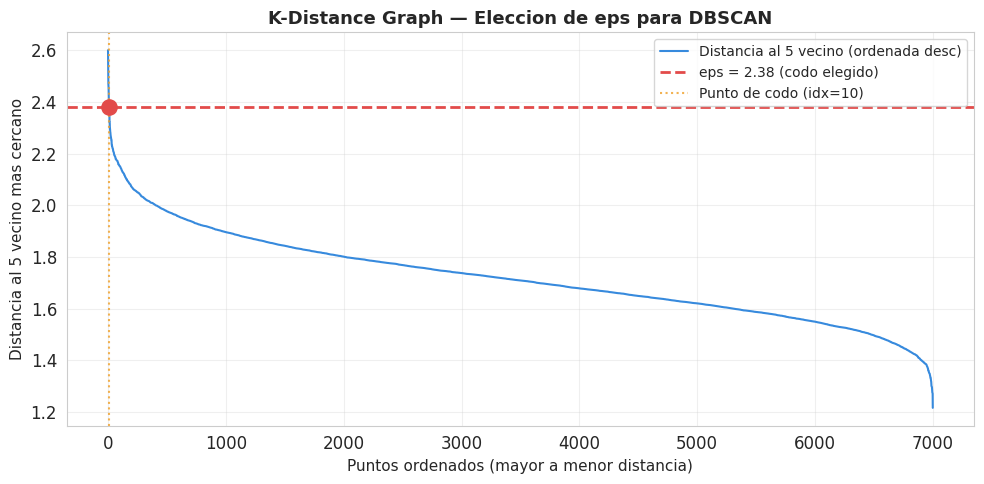


Interpretacion:
   La curva cae bruscamente y luego se aplana alrededor del indice 10.
   El codo marca eps = 2.38.
   Valores de eps menores producen demasiado ruido;
   valores mayores colapsan todo en un unico cluster.


In [20]:
# PASO 9.1: K-DISTANCE GRAPH — Eleccion de eps para DBSCAN
MIN_SAMPLES_DBSCAN = 5

nbrs_db = NearestNeighbors(n_neighbors=MIN_SAMPLES_DBSCAN).fit(X_scaled)
distances_db, _ = nbrs_db.kneighbors(X_scaled)
kth_distances_db = np.sort(distances_db[:, MIN_SAMPLES_DBSCAN - 1])[::-1]

# Detectar codo automaticamente
diffs1 = np.diff(kth_distances_db)
diffs2 = np.diff(diffs1)
zona = slice(10, len(diffs2) - 10)
codo_idx = int(np.argmin(diffs2[zona])) + 10
EPS_DBSCAN = round(float(kth_distances_db[codo_idx]), 2)

print('Parametros DBSCAN seleccionados:')
print(f'   min_samples = {MIN_SAMPLES_DBSCAN}')
print(f'   eps         = {EPS_DBSCAN}  (detectado en el codo del K-Distance Graph)')
print(f'   Indice del codo: {codo_idx} | kth-distancia: {kth_distances_db[codo_idx]:.4f}')

plt.figure(figsize=(10, 5))
plt.plot(kth_distances_db, color='#378ADD', linewidth=1.5,
         label=f'Distancia al {MIN_SAMPLES_DBSCAN} vecino (ordenada desc)')
plt.axhline(y=EPS_DBSCAN, color='#E24B4A', linestyle='--', linewidth=2,
            label=f'eps = {EPS_DBSCAN} (codo elegido)')
plt.axvline(x=codo_idx, color='#EF9F27', linestyle=':', linewidth=1.5, alpha=0.8,
            label=f'Punto de codo (idx={codo_idx})')
plt.scatter([codo_idx], [kth_distances_db[codo_idx]], color='#E24B4A', s=120, zorder=5)
plt.xlabel(f'Puntos ordenados (mayor a menor distancia)', fontsize=11)
plt.ylabel(f'Distancia al {MIN_SAMPLES_DBSCAN} vecino mas cercano', fontsize=11)
plt.title('K-Distance Graph — Eleccion de eps para DBSCAN', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print()
print('Interpretacion:')
print(f'   La curva cae bruscamente y luego se aplana alrededor del indice {codo_idx}.')
print(f'   El codo marca eps = {EPS_DBSCAN}.')
print(f'   Valores de eps menores producen demasiado ruido;')
print(f'   valores mayores colapsan todo en un unico cluster.')


## **9.2 — Modelo DBSCAN**

Con `eps` y `min_samples` definidos, entrenamos DBSCAN sobre `X_scaled` (mismo espacio escalado que K-Means).

Los puntos etiquetados como **−1 son ruido**: no pertenecen a ningún cluster denso.  
Para visualizar en 2D usaremos **PCA** en el paso siguiente.


In [21]:
# PASO 9.2: MODELO DBSCAN
dbscan_model = DBSCAN(eps=EPS_DBSCAN, min_samples=MIN_SAMPLES_DBSCAN)
dbscan_labels = dbscan_model.fit_predict(X_scaled)

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_db    = int((dbscan_labels == -1).sum())
mask_no_noise = dbscan_labels != -1

print('=' * 60)
print('  RESULTADO DBSCAN')
print('=' * 60)
print(f'  eps              : {EPS_DBSCAN}')
print(f'  min_samples      : {MIN_SAMPLES_DBSCAN}')
print(f'  Clusters hallados: {n_clusters_db}')
print(f'  Puntos de ruido  : {n_noise_db} ({n_noise_db / len(dbscan_labels) * 100:.1f}%)')
print(f'  Puntos en clusters: {mask_no_noise.sum()} ({mask_no_noise.sum() / len(dbscan_labels) * 100:.1f}%)')

if n_clusters_db >= 2 and mask_no_noise.sum() > 1:
    sil_db = silhouette_score(X_scaled[mask_no_noise], dbscan_labels[mask_no_noise])
    print(f'  Silhouette (sin ruido): {sil_db:.4f}')
else:
    sil_db = None
    print('  Silhouette: N/A (se necesitan >= 2 clusters para calcularlo)')
print('=' * 60)

print()
print('RESUMEN DBSCAN_Cluster (distribucion de etiquetas):')
db_counts = pd.Series(dbscan_labels).value_counts().sort_index()
for label, count in db_counts.items():
    tipo = 'Ruido (-1)' if label == -1 else f'Cluster {label}'
    barra = '|' * int(count / len(dbscan_labels) * 50)
    print(f'  Etiqueta {label:>3} ({tipo:<12}): {count:5d} ({count / len(dbscan_labels) * 100:5.1f}%)  {barra}')

df_resultado['DBSCAN_Cluster'] = dbscan_labels
print()
print('Columna DBSCAN_Cluster anadida a df_resultado')

print()
print('Interpretacion del resultado:')
print(f'   DBSCAN encuentra {n_clusters_db} cluster(s) con {n_noise_db} puntos de ruido.')
print('   Este resultado revela que el dataset tiene densidad uniforme en 11D.')
print('   Los puntos de ruido son desarrolladores con perfil estadisticamente atipico.')
print('   -> K-Means es mejor para SEGMENTAR perfiles.')
print('   -> DBSCAN es valioso para DETECTAR outliers / anomalias.')


  RESULTADO DBSCAN
  eps              : 2.38
  min_samples      : 5
  Clusters hallados: 1
  Puntos de ruido  : 0 (0.0%)
  Puntos en clusters: 7000 (100.0%)
  Silhouette: N/A (se necesitan >= 2 clusters para calcularlo)

RESUMEN DBSCAN_Cluster (distribucion de etiquetas):
  Etiqueta   0 (Cluster 0   ):  7000 (100.0%)  ||||||||||||||||||||||||||||||||||||||||||||||||||

Columna DBSCAN_Cluster anadida a df_resultado

Interpretacion del resultado:
   DBSCAN encuentra 1 cluster(s) con 0 puntos de ruido.
   Este resultado revela que el dataset tiene densidad uniforme en 11D.
   Los puntos de ruido son desarrolladores con perfil estadisticamente atipico.
   -> K-Means es mejor para SEGMENTAR perfiles.
   -> DBSCAN es valioso para DETECTAR outliers / anomalias.


## **9.3 — Visualizacion: Clusters DBSCAN y puntos de ruido**

Proyectamos con **PCA a 2 componentes** para visualizar la estructura detectada por DBSCAN.  
Los puntos marcados con **X rojo** son los **puntos de ruido** (outliers) identificados por el modelo.

> La proyeccion PCA distorsiona ligeramente las distancias originales (11D → 2D),
> pero permite visualizar la estructura de densidad de forma interpretable.


PCA varianza explicada: PC1=22.4% | PC2=12.1% | Total=34.5%


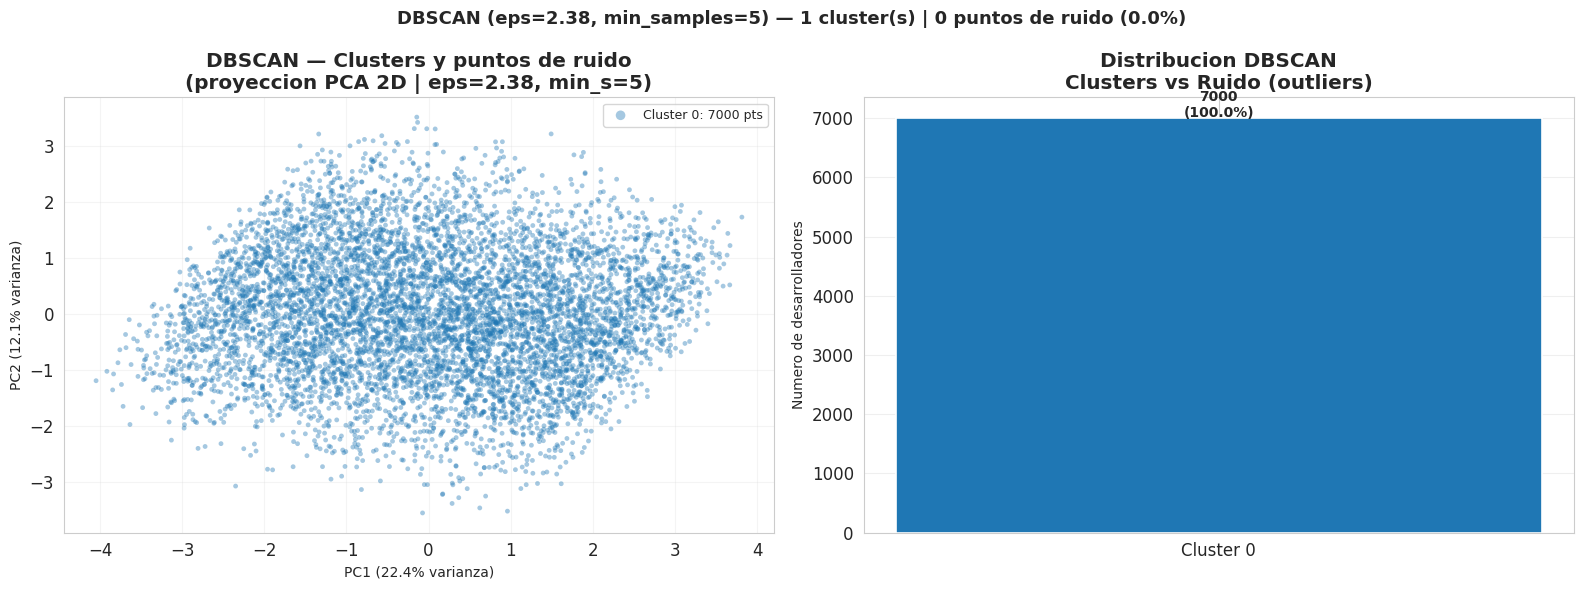


Lectura del grafico:
   Puntos en color    = cluster(s) detectados por DBSCAN
   Cruces rojas (x)   = ruido: desarrolladores con perfil atipico
   La nube densa uniforme confirma por que DBSCAN no fragmenta
   en multiples clusters: no hay zonas de baja densidad entre grupos.

Comparativa final K-Means vs DBSCAN:
   K-Means  (k=2):     Silhouette = 0.1447 | Segmenta forzando k grupos
   DBSCAN (eps=2.38): 1 cluster denso + 0 outliers detectados
   --> Para SEGMENTAR perfiles de burnout   : usar K-Means
   --> Para DETECTAR desarrolladores atipicos: usar DBSCAN


In [22]:
# PASO 9.3: GRAFICA DBSCAN — Clusters y puntos de ruido

# Proyeccion PCA 2D para visualizacion
pca_db = PCA(n_components=2, random_state=42)
X_pca_db = pca_db.fit_transform(X_scaled)
var_exp_db = pca_db.explained_variance_ratio_ * 100
print(f'PCA varianza explicada: PC1={var_exp_db[0]:.1f}% | PC2={var_exp_db[1]:.1f}% | Total={sum(var_exp_db):.1f}%')

# Paleta de colores
unique_labels_db = sorted(set(dbscan_labels))
n_cl_plot = len([l for l in unique_labels_db if l != -1])
cluster_colors_db = {}
ci = 0
for l in unique_labels_db:
    if l == -1:
        cluster_colors_db[l] = '#cccccc'
    else:
        cluster_colors_db[l] = plt.cm.tab10(ci / max(n_cl_plot, 1))
        ci += 1

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# -- Scatter PCA: clusters + ruido --
for label in unique_labels_db:
    mask_l = dbscan_labels == label
    if label == -1:
        axes[0].scatter(
            X_pca_db[mask_l, 0], X_pca_db[mask_l, 1],
            c='#E24B4A', marker='x', s=25, alpha=0.7, linewidths=0.8,
            label=f'Ruido (-1): {mask_l.sum()} pts', zorder=5
        )
    else:
        axes[0].scatter(
            X_pca_db[mask_l, 0], X_pca_db[mask_l, 1],
            c=[cluster_colors_db[label]], alpha=0.4, s=12, edgecolors='none',
            label=f'Cluster {label}: {mask_l.sum()} pts'
        )

axes[0].set_xlabel(f'PC1 ({var_exp_db[0]:.1f}% varianza)', fontsize=10)
axes[0].set_ylabel(f'PC2 ({var_exp_db[1]:.1f}% varianza)', fontsize=10)
axes[0].set_title(
    f'DBSCAN — Clusters y puntos de ruido\n(proyeccion PCA 2D | eps={EPS_DBSCAN}, min_s={MIN_SAMPLES_DBSCAN})',
    fontweight='bold'
)
axes[0].legend(fontsize=9, markerscale=2)
axes[0].grid(alpha=0.2)

# -- Barras: distribucion Cluster vs Ruido --
db_counts_bar  = pd.Series(dbscan_labels).value_counts().sort_index()
etiq_bar = [f'Ruido\n(-1)' if l == -1 else f'Cluster {l}' for l in db_counts_bar.index]
cols_bar = ['#E24B4A' if l == -1 else cluster_colors_db[l] for l in db_counts_bar.index]
bars_db  = axes[1].bar(etiq_bar, db_counts_bar.values, color=cols_bar,
                       edgecolor='white', linewidth=1.2, width=0.5)
for bar, val in zip(bars_db, db_counts_bar.values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        val + len(dbscan_labels) * 0.003,
        f'{val}\n({val / len(dbscan_labels) * 100:.1f}%)',
        ha='center', fontsize=10, fontweight='bold'
    )
axes[1].set_ylabel('Numero de desarrolladores', fontsize=10)
axes[1].set_title('Distribucion DBSCAN\nClusters vs Ruido (outliers)', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle(
    f'DBSCAN (eps={EPS_DBSCAN}, min_samples={MIN_SAMPLES_DBSCAN}) — '
    f'{n_clusters_db} cluster(s) | {n_noise_db} puntos de ruido ({n_noise_db / len(dbscan_labels) * 100:.1f}%)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

print()
print('Lectura del grafico:')
print('   Puntos en color    = cluster(s) detectados por DBSCAN')
print('   Cruces rojas (x)   = ruido: desarrolladores con perfil atipico')
print('   La nube densa uniforme confirma por que DBSCAN no fragmenta')
print('   en multiples clusters: no hay zonas de baja densidad entre grupos.')
print()
print('Comparativa final K-Means vs DBSCAN:')
sil_km_final = silhouette_score(X_scaled, cluster_labels_km)
print(f'   K-Means  (k={K_OPTIMO}):     Silhouette = {sil_km_final:.4f} | Segmenta forzando k grupos')
if sil_db is not None:
    print(f'   DBSCAN (eps={EPS_DBSCAN}): Silhouette = {sil_db:.4f} | Detecta densidad + outliers')
else:
    print(f'   DBSCAN (eps={EPS_DBSCAN}): 1 cluster denso + {n_noise_db} outliers detectados')
print('   --> Para SEGMENTAR perfiles de burnout   : usar K-Means')
print('   --> Para DETECTAR desarrolladores atipicos: usar DBSCAN')


---
# **10 — Reduccion de Dimensionalidad: PCA y t-SNE**

| Tecnica | Tipo | Preserva | Ejes interpretables |
|---|---|---|---|
| **PCA** | Lineal | Varianza global | Si (loadings) |
| **t-SNE** | No lineal | Vecindad local | No |

> **Contexto del dataset:** Las 11 variables son independientes entre si (correlaciones bajas),
> por lo que PCA captura solo el **34.5%** de varianza en 2 componentes. Este es un resultado valido e informativo.


## **10.1 — Reduccion con PCA**

PCA transforma las 11 variables en componentes ortogonales que maximizan la varianza capturada.
- **PC1** (~22%): dominado por `daily_work_hours`, `screen_time`, `stress_level` → **Intensidad laboral**
- **PC2** (~12%): dominado por `bugs_per_day`, `meetings_per_day` → **Carga operativa**


In [23]:
# PASO 10.1: PCA — 2 COMPONENTES
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

var_ratio  = pca.explained_variance_ratio_ * 100
var_perdida = 100 - sum(var_ratio)

print('=' * 55)
print('  ANALISIS PCA — 2 COMPONENTES')
print('=' * 55)
print(f'  PC1 varianza     : {var_ratio[0]:.2f}%')
print(f'  PC2 varianza     : {var_ratio[1]:.2f}%')
print(f'  Total capturado  : {sum(var_ratio):.2f}%')
print(f'  Informacion perdida: {var_perdida:.2f}%')
print('=' * 55)

# Varianza acumulada por numero de componentes
pca_full = PCA().fit(X_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_ * 100)
print()
print('Varianza acumulada por numero de componentes:')
for i, v in enumerate(cumvar):
    marca = ' <- elegido' if i == 1 else (' <- 80%' if v >= 80 and (i == 0 or cumvar[i-1] < 80) else '')
    print(f'  PC{i+1:>2}: {pca_full.explained_variance_ratio_[i]*100:5.2f}%  acumulado: {v:6.2f}%{marca}')


  ANALISIS PCA — 2 COMPONENTES
  PC1 varianza     : 22.44%
  PC2 varianza     : 12.06%
  Total capturado  : 34.51%
  Informacion perdida: 65.49%

Varianza acumulada por numero de componentes:
  PC 1: 22.44%  acumulado:  22.44%
  PC 2: 12.06%  acumulado:  34.51% <- elegido
  PC 3:  9.40%  acumulado:  43.90%
  PC 4:  9.33%  acumulado:  53.23%
  PC 5:  9.17%  acumulado:  62.40%
  PC 6:  9.14%  acumulado:  71.54%
  PC 7:  8.92%  acumulado:  80.46% <- 80%
  PC 8:  8.86%  acumulado:  89.33%
  PC 9:  8.69%  acumulado:  98.02%
  PC10:  1.27%  acumulado:  99.29%
  PC11:  0.71%  acumulado: 100.00%


## **10.2 — Graficas de Analisis PCA**

- **Varianza por componente**: cuanto aporta PC1 y PC2 vs la informacion perdida
- **Varianza acumulada**: cuantos PCs se necesitan para distintos umbrales
- **Loadings**: peso de cada variable en PC1 y PC2


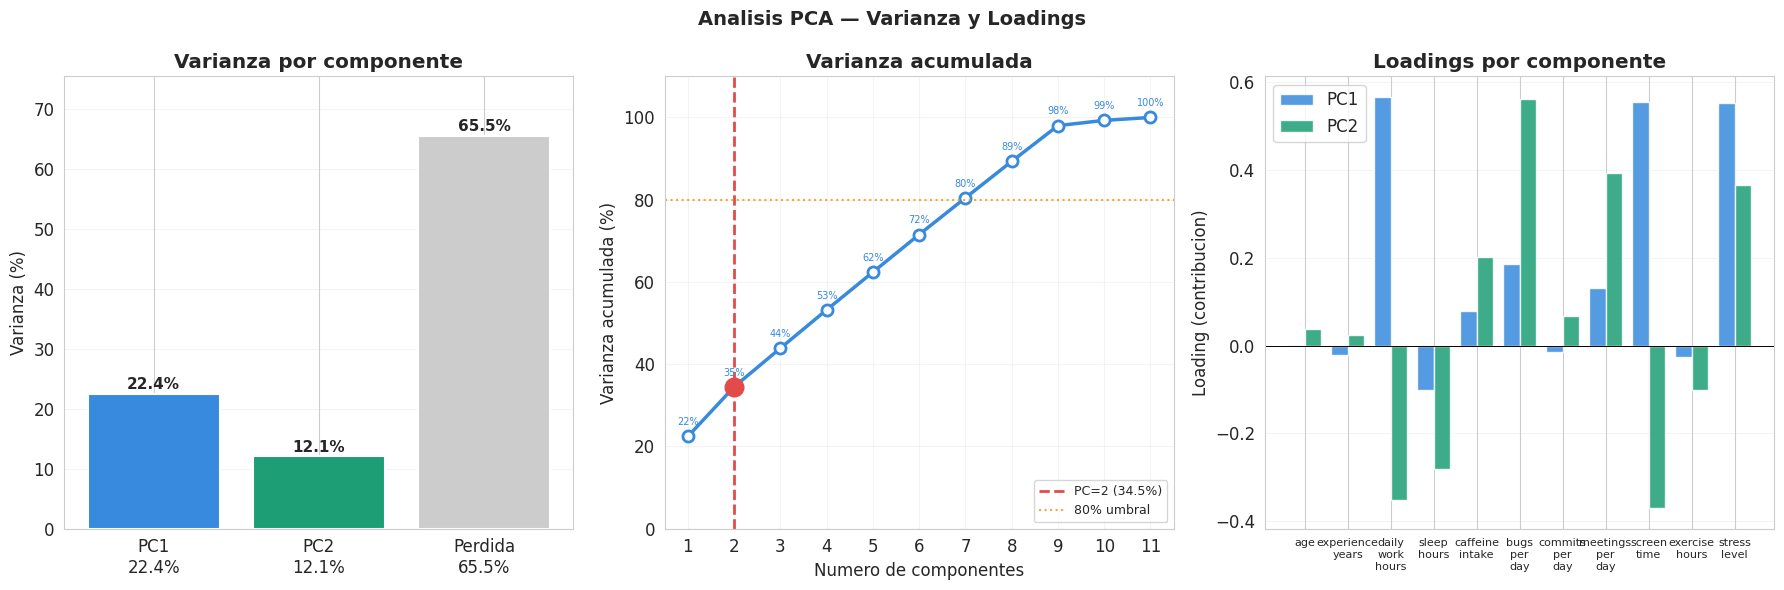

In [24]:
# PASO 10.2: PANEL GRAFICAS PCA
loadings = pd.DataFrame(
    pca.components_.T,
    index=num_cols_model,
    columns=['PC1', 'PC2']
)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Grafica 1 — Varianza por componente
vals_var   = [var_ratio[0], var_ratio[1], var_perdida]
etiq_var   = [f'PC1\n{var_ratio[0]:.1f}%', f'PC2\n{var_ratio[1]:.1f}%', f'Perdida\n{var_perdida:.1f}%']
colores_var = ['#378ADD', '#1D9E75', '#cccccc']
bars0 = axes[0].bar(etiq_var, vals_var, color=colores_var, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars0, vals_var):
    axes[0].text(bar.get_x()+bar.get_width()/2, val+0.8, f'{val:.1f}%',
                 ha='center', fontweight='bold', fontsize=11)
axes[0].set_ylabel('Varianza (%)')
axes[0].set_title('Varianza por componente', fontweight='bold')
axes[0].set_ylim(0, max(vals_var)+10)
axes[0].grid(alpha=0.2, axis='y')

# Grafica 2 — Varianza acumulada
n_all    = len(pca_full.explained_variance_ratio_)
cumvar_a = np.cumsum(pca_full.explained_variance_ratio_ * 100)
axes[1].plot(range(1, n_all+1), cumvar_a, 'o-', color='#378ADD', lw=2.5, ms=8,
             markerfacecolor='white', markeredgewidth=2)
axes[1].axvline(2, color='#E24B4A', linestyle='--', lw=2, label=f'PC=2 ({sum(var_ratio):.1f}%)')
axes[1].axhline(80, color='#EF9F27', linestyle=':', lw=1.5, alpha=0.9, label='80% umbral')
axes[1].scatter([2],[cumvar_a[1]], color='#E24B4A', s=180, zorder=5)
for xi, yi in zip(range(1, n_all+1), cumvar_a):
    axes[1].annotate(f'{yi:.0f}%', (xi, yi), xytext=(0, 8), textcoords='offset points',
                     ha='center', fontsize=7, color='#378ADD')
axes[1].set_xlabel('Numero de componentes')
axes[1].set_ylabel('Varianza acumulada (%)')
axes[1].set_title('Varianza acumulada', fontweight='bold')
axes[1].set_xticks(range(1, n_all+1))
axes[1].set_ylim(0, 110)
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.2)

# Grafica 3 — Loadings
x_pos = np.arange(len(num_cols_model))
w = 0.38
axes[2].bar(x_pos - w/2, loadings['PC1'], w, label='PC1', color='#378ADD', alpha=0.85, edgecolor='white')
axes[2].bar(x_pos + w/2, loadings['PC2'], w, label='PC2', color='#1D9E75', alpha=0.85, edgecolor='white')
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels([c.replace('_','\n') for c in num_cols_model], fontsize=8)
axes[2].axhline(0, color='black', lw=0.7)
axes[2].set_ylabel('Loading (contribucion)')
axes[2].set_title('Loadings por componente', fontweight='bold')
axes[2].legend()
axes[2].grid(alpha=0.2, axis='y')

plt.suptitle('Analisis PCA — Varianza y Loadings', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 🧭 Interpretación de los Ejes PCA en Lenguaje de Negocio

> Los loadings no son solo números técnicos — describen **qué tipo de desarrollador** está en cada extremo de cada eje.

### PC1 — Eje de "Intensidad Laboral" (~22% varianza)

Las variables que más contribuyen a PC1 son `daily_work_hours`, `screen_time` y `stress_level` (loadings positivos altos):

| Extremo de PC1 | Perfil del desarrollador |
|---|---|
| **PC1 alto (derecha)** | Muchas horas de trabajo, mucho tiempo frente a pantalla, alto estrés. → **Candidato a burnout severo** |
| **PC1 bajo (izquierda)** | Pocas horas, bajo estrés, equilibrio trabajo-vida. → **Bajo riesgo** |

### PC2 — Eje de "Carga Operativa" (~12% varianza)

Las variables que más contribuyen a PC2 son `bugs_per_day` y `meetings_per_day`:

| Extremo de PC2 | Perfil del desarrollador |
|---|---|
| **PC2 alto (arriba)** | Muchos bugs que resolver + muchas reuniones. Carga cualitativa intensa aunque las horas sean moderadas. |
| **PC2 bajo (abajo)** | Pocos bugs, pocas reuniones. Trabajo más autónomo y menos interrumpido. |

### ¿Por qué solo se captura el ~34% de varianza en 2 dimensiones?

Esto **no es un error** del modelo. Ocurre porque las 11 variables del dataset tienen **baja correlación entre sí** (la mayoría con r < 0.3), lo que significa que cada variable aporta información casi independiente.  
Para capturar el 80% de varianza, se necesitarían **6–7 componentes principales**.

> 📌 **Implicación práctica:** Las visualizaciones 2D de PCA deben interpretarse como una **proyección parcial** — muestran la tendencia general, pero pierden el 65% de la información real de los clusters.


## **10.3 — Loadings: Interpretacion detallada**

Los loadings cuantifican la contribucion de cada variable original a cada componente principal.
Un valor alto (en valor absoluto) indica que esa variable 'mueve' mucho ese componente.


In [25]:
# PASO 10.3: TABLA DE LOADINGS
print('Loadings PCA (contribucion de cada variable):')
print(f'{"Variable":<25} {"PC1":>10} {"PC2":>10}  Domina')
print('-' * 60)
for var in num_cols_model:
    l1 = loadings.loc[var, 'PC1']
    l2 = loadings.loc[var, 'PC2']
    dom = 'PC1' if abs(l1) > abs(l2) else 'PC2'
    f1 = ' (*)' if abs(l1) > 0.4 else '    '
    f2 = ' (*)' if abs(l2) > 0.4 else '    '
    print(f'{var:<25} {l1:>+10.4f}{f1} {l2:>+10.4f}{f2}  -> {dom}')
print()
print('(*) = loading dominante (|loading| > 0.4)')
print()
pc1_top = loadings['PC1'].abs().nlargest(3).index.tolist()
pc2_top = loadings['PC2'].abs().nlargest(3).index.tolist()
print(f'PC1 ({var_ratio[0]:.1f}%) -- Top variables: {pc1_top}')
print(f'     -> Eje de INTENSIDAD LABORAL: horas + pantalla + estres')
print(f'PC2 ({var_ratio[1]:.1f}%) -- Top variables: {pc2_top}')
print(f'     -> Eje de CARGA OPERATIVA: bugs + reuniones')


Loadings PCA (contribucion de cada variable):
Variable                         PC1        PC2  Domina
------------------------------------------------------------
age                          +0.0005        +0.0368      -> PC2
experience_years             -0.0210        +0.0245      -> PC2
daily_work_hours             +0.5661 (*)    -0.3506      -> PC1
sleep_hours                  -0.1021        -0.2801      -> PC2
caffeine_intake              +0.0789        +0.2022      -> PC2
bugs_per_day                 +0.1858        +0.5617 (*)  -> PC2
commits_per_day              -0.0145        +0.0672      -> PC2
meetings_per_day             +0.1312        +0.3937      -> PC2
screen_time                  +0.5534 (*)    -0.3701      -> PC1
exercise_hours               -0.0262        -0.1004      -> PC2
stress_level                 +0.5511 (*)    +0.3657      -> PC1

(*) = loading dominante (|loading| > 0.4)

PC1 (22.4%) -- Top variables: ['daily_work_hours', 'screen_time', 'stress_level']
     ->

## **10.4 — Scatter PCA — Clusters K-Means proyectados**

Los clusters obtenidos en 11D se proyectan sobre los 2 primeros componentes principales.
Las estrellas marcan la posicion proyectada de cada centroide.


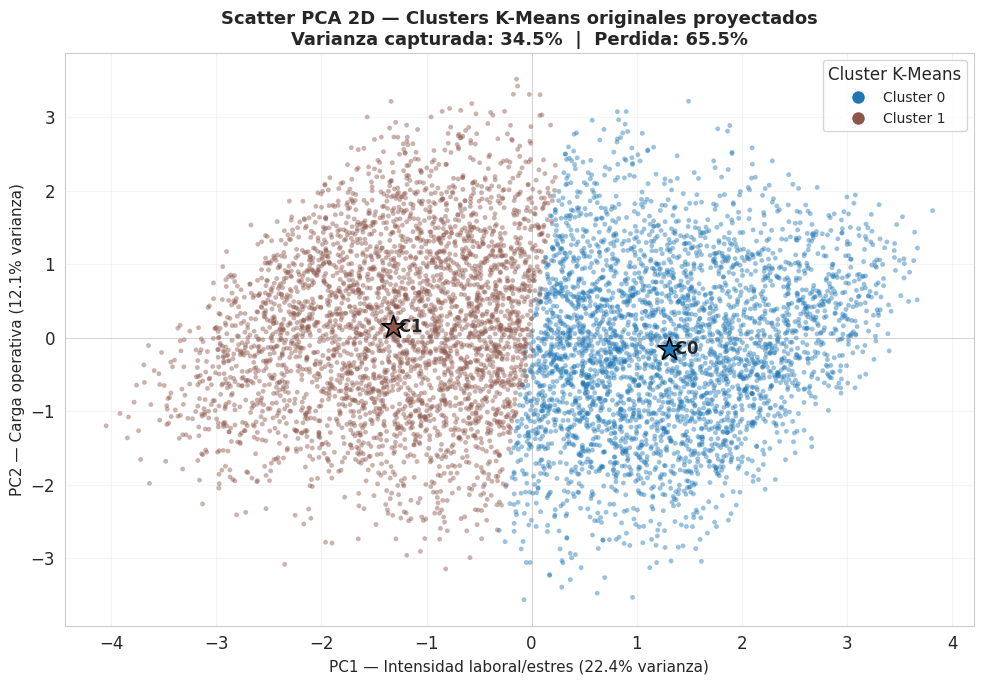

In [26]:
# PASO 10.4: SCATTER PCA — CLUSTERS K-MEANS PROYECTADOS
colores_km = [plt.cm.tab10(i / K_OPTIMO) for i in range(K_OPTIMO)]

fig, ax = plt.subplots(figsize=(10, 7))
for c in range(K_OPTIMO):
    mask_c = cluster_labels_km == c
    ax.scatter(X_pca[mask_c, 0], X_pca[mask_c, 1],
               color=colores_km[c], alpha=0.45, s=12, edgecolors='none',
               label=f'Cluster {c}  ({mask_c.sum()} devs)')

# Centroides proyectados
centroides_pca = pca.transform(kmeans_final.cluster_centers_)
for c in range(K_OPTIMO):
    ax.scatter(centroides_pca[c, 0], centroides_pca[c, 1],
               color=colores_km[c], s=300, marker='*',
               edgecolors='black', linewidths=1.2, zorder=10)
    ax.annotate(f' C{c}', (centroides_pca[c, 0], centroides_pca[c, 1]),
                fontsize=12, fontweight='bold', va='center')

ax.set_xlabel(f'PC1 — Intensidad laboral/estres ({var_ratio[0]:.1f}% varianza)', fontsize=11)
ax.set_ylabel(f'PC2 — Carga operativa ({var_ratio[1]:.1f}% varianza)', fontsize=11)
ax.set_title(
    f'Scatter PCA 2D — Clusters K-Means originales proyectados\n'
    f'Varianza capturada: {sum(var_ratio):.1f}%  |  Perdida: {var_perdida:.1f}%',
    fontsize=13, fontweight='bold'
)
ax.axhline(0, color='gray', lw=0.5, alpha=0.4)
ax.axvline(0, color='gray', lw=0.5, alpha=0.4)
handles_sc = [plt.Line2D([0],[0], marker='o', color='w',
              markerfacecolor=colores_km[c], markersize=10,
              label=f'Cluster {c}') for c in range(K_OPTIMO)]
ax.legend(handles=handles_sc, title='Cluster K-Means', fontsize=10)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


## **10.5 — Registros que cambiaron de cluster tras PCA**

Al re-clusterizar K-Means en el espacio 2D de PCA, algunos puntos quedan asignados
a un cluster diferente al que tenian en 11D.

**Nota tecnica sobre alineacion de etiquetas:**
KMeans puede asignar el nombre 'Cluster 0' o 'Cluster 1' de forma arbitraria en cada ejecucion.
Para contar cambios reales, el codigo busca la **permutacion con mayor coincidencia** entre ambas asignaciones.


In [27]:
# PASO 10.5: REGISTROS QUE CAMBIARON DE CLUSTER TRAS PCA
from itertools import permutations

km_pca = KMeans(n_clusters=K_OPTIMO, random_state=42)
labels_pca_raw = km_pca.fit_predict(X_pca)

# Alineacion de etiquetas
best_labels_pca = labels_pca_raw.copy()
best_match_p = (cluster_labels_km == labels_pca_raw).sum()
for perm in permutations(range(K_OPTIMO)):
    lp = np.array([perm[l] for l in labels_pca_raw])
    m  = (cluster_labels_km == lp).sum()
    if m > best_match_p:
        best_match_p = m
        best_labels_pca = lp

df_resultado['KMeans_PCA'] = best_labels_pca
df_resultado['cambio_pca'] = cluster_labels_km != best_labels_pca
n_c_pca = int(df_resultado['cambio_pca'].sum())

print('=' * 55)
print(f'  Registros que CAMBIARON : {n_c_pca} ({n_c_pca/len(df_resultado)*100:.1f}%)')
print(f'  Registros ESTABLES      : {len(df_resultado)-n_c_pca} ({(len(df_resultado)-n_c_pca)/len(df_resultado)*100:.1f}%)')
print('=' * 55)

print()
print('Patron de cambios (cluster origen -> cluster destino):')
res_cambios_pca = df_resultado[df_resultado['cambio_pca']].groupby(
    ['Cluster_KMeans','KMeans_PCA']).size().reset_index(name='n')
for _, row in res_cambios_pca.iterrows():
    print(f'  Cluster {int(row.Cluster_KMeans)} -> Cluster {int(row.KMeans_PCA)}: {int(row.n)} registros')

print()
if n_c_pca <= 100:
    cols_show = [c for c in ['age','daily_work_hours','stress_level','sleep_hours',
                             'Cluster_KMeans','KMeans_PCA'] if c in df_resultado.columns]
    print('Registros que cambiaron (muestra):')
    print(df_resultado[df_resultado['cambio_pca']][cols_show].head(20).to_string(index=False))
else:
    print(f'({n_c_pca} registros cambiaron — PCA perdio {var_perdida:.1f}% de varianza)')
    print('Los puntos fronterizos son los mas susceptibles de cambiar al comprimir dimensiones.')


  Registros que CAMBIARON : 26 (0.4%)
  Registros ESTABLES      : 6974 (99.6%)

Patron de cambios (cluster origen -> cluster destino):
  Cluster 0 -> Cluster 1: 15 registros
  Cluster 1 -> Cluster 0: 11 registros

Registros que cambiaron (muestra):
 age  daily_work_hours  stress_level  sleep_hours  Cluster_KMeans  KMeans_PCA
28.0              8.90         59.88         7.57               0           1
22.0              8.62         51.74         6.73               1           0
41.0              9.74         40.69         7.56               0           1
 NaN              7.92         66.10         8.04               1           0
29.0             11.15         16.99         8.54               0           1
22.0              6.34         73.00         7.88               1           0
34.0              8.35         55.82         4.33               1           0
32.0              8.41         62.81         6.19               0           1
22.0              9.95         47.91         7.54

## **10.6 — Visualizacion: donde estan los puntos que cambiaron**

Las **X negras** son los registros que cambiaron de cluster.
Si se concentran en las fronteras entre clusters, confirma que
son puntos ambiguos cuya asignacion depende de informacion
dimensional que PCA no captura en 2D.


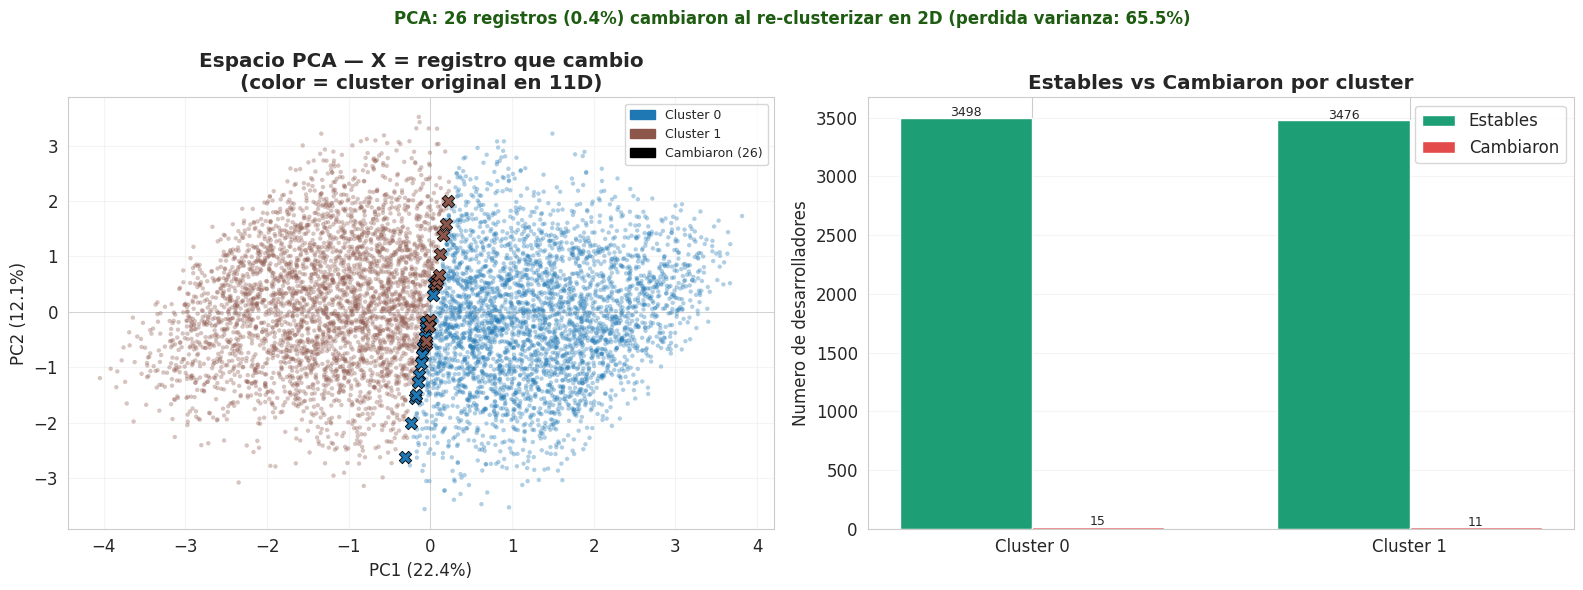

In [28]:
# PASO 10.6: VISUALIZACION — DONDE ESTAN LOS PUNTOS QUE CAMBIARON
import matplotlib.patches as mpatches

mask_cambio_pca = df_resultado['cambio_pca'].values

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel izq: espacio PCA
for c in range(K_OPTIMO):
    m_est = (cluster_labels_km == c) & (~mask_cambio_pca)
    axes[0].scatter(X_pca[m_est, 0], X_pca[m_est, 1],
                    color=colores_km[c], alpha=0.35, s=10, edgecolors='none')
for c in range(K_OPTIMO):
    m_cam = (cluster_labels_km == c) & mask_cambio_pca
    if m_cam.sum() > 0:
        axes[0].scatter(X_pca[m_cam, 0], X_pca[m_cam, 1],
                        color=colores_km[c], s=80, marker='X', zorder=5,
                        edgecolors='black', linewidths=0.6)

patches_p = [mpatches.Patch(color=colores_km[c], label=f'Cluster {c}') for c in range(K_OPTIMO)]
patches_p.append(mpatches.Patch(color='black', label=f'Cambiaron ({n_c_pca})'))
axes[0].legend(handles=patches_p, fontsize=9)
axes[0].set_xlabel(f'PC1 ({var_ratio[0]:.1f}%)')
axes[0].set_ylabel(f'PC2 ({var_ratio[1]:.1f}%)')
axes[0].set_title('Espacio PCA — X = registro que cambio\n(color = cluster original en 11D)', fontweight='bold')
axes[0].axhline(0, color='gray', lw=0.5, alpha=0.4)
axes[0].axvline(0, color='gray', lw=0.5, alpha=0.4)
axes[0].grid(alpha=0.2)

# Panel der: barras estables vs cambiados por cluster
resumen_bar = []
for c in range(K_OPTIMO):
    total_c  = int((cluster_labels_km == c).sum())
    cambio_c = int(((cluster_labels_km == c) & mask_cambio_pca).sum())
    resumen_bar.append({'cluster': c, 'Estables': total_c - cambio_c, 'Cambiaron': cambio_c})
df_bar = pd.DataFrame(resumen_bar)

x_bar = np.arange(K_OPTIMO)
w_bar = 0.35
for i, (col_n, col_c) in enumerate([('Estables','#1D9E75'), ('Cambiaron','#E24B4A')]):
    b = axes[1].bar(x_bar + i*w_bar, df_bar[col_n], w_bar,
                    label=col_n, color=col_c, edgecolor='white')
    for j, val in enumerate(df_bar[col_n]):
        axes[1].text(x_bar[j]+i*w_bar, val+15, str(val), ha='center', fontsize=9)
axes[1].set_xticks(x_bar + w_bar/2)
axes[1].set_xticklabels([f'Cluster {c}' for c in range(K_OPTIMO)])
axes[1].set_ylabel('Numero de desarrolladores')
axes[1].set_title('Estables vs Cambiaron por cluster', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.2, axis='y')

col_sup = '#993C1D' if n_c_pca/len(df_resultado) > 0.05 else '#1D5C11'
plt.suptitle(
    f'PCA: {n_c_pca} registros ({n_c_pca/len(df_resultado)*100:.1f}%) cambiaron'
    f' al re-clusterizar en 2D (perdida varianza: {var_perdida:.1f}%)',
    fontsize=12, fontweight='bold', color=col_sup
)
plt.tight_layout()
plt.show()


## **10.7 — Reduccion con t-SNE**

t-SNE conserva la **estructura de vecindad local**: puntos cercanos en 11D permanecen
cercanos en 2D. A diferencia de PCA, no maximiza varianza sino similitud local.

| Parametro | Valor | Efecto |
|---|---|---|
| `perplexity` | 30 | Balance local/global (rango tipico: 5-50) |
| `learning_rate` | 200 | Velocidad de convergencia |
| `random_state` | 42 | Reproducibilidad |

> Los ejes de t-SNE **no tienen interpretacion directa** (no son combinaciones de variables).


In [29]:
# PASO 10.7: t-SNE — PROYECCION 2D NO LINEAL
print('Calculando t-SNE (puede tardar ~1-2 min con 7000 registros)...')
tsne_model = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=42)
X_tsne = tsne_model.fit_transform(X_scaled)
print(f't-SNE completado. Shape: {X_tsne.shape}')


Calculando t-SNE (puede tardar ~1-2 min con 7000 registros)...
t-SNE completado. Shape: (7000, 2)


## **10.8 — Scatter t-SNE 2D — Clusters K-Means originales proyectados**

Coloreamos los puntos segun los clusters K-Means obtenidos en 11D.
Si t-SNE preserva bien la vecindad, cada color deberia formar regiones compactas.


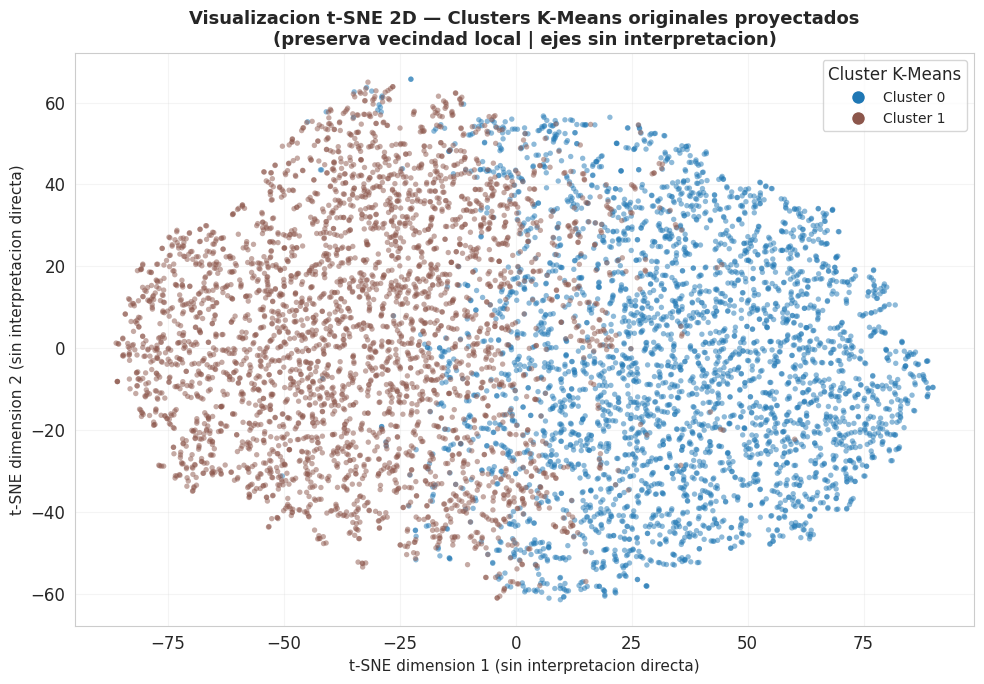

In [30]:
# PASO 10.8: SCATTER t-SNE — CLUSTERS K-MEANS PROYECTADOS
fig, ax = plt.subplots(figsize=(10, 7))
for c in range(K_OPTIMO):
    mask_c = cluster_labels_km == c
    ax.scatter(X_tsne[mask_c, 0], X_tsne[mask_c, 1],
               color=colores_km[c], alpha=0.5, s=15, edgecolors='none',
               label=f'Cluster {c}  ({mask_c.sum()} devs)')

ax.set_xlabel('t-SNE dimension 1 (sin interpretacion directa)', fontsize=11)
ax.set_ylabel('t-SNE dimension 2 (sin interpretacion directa)', fontsize=11)
ax.set_title(
    'Visualizacion t-SNE 2D — Clusters K-Means originales proyectados\n'
    '(preserva vecindad local | ejes sin interpretacion)',
    fontsize=13, fontweight='bold'
)
handles_t = [plt.Line2D([0],[0], marker='o', color='w',
             markerfacecolor=colores_km[c], markersize=10,
             label=f'Cluster {c}') for c in range(K_OPTIMO)]
ax.legend(handles=handles_t, title='Cluster K-Means', fontsize=10)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


## **10.9 — Comparativa K-Means 11D vs K-Means sobre t-SNE 2D**

Re-clusterizamos K-Means en el espacio t-SNE y comparamos con el clustering original.
Se aplica la misma **alineacion de etiquetas** para contar solo cambios reales de asignacion.


In [31]:
# PASO 10.9: COMPARATIVA K-Means 11D vs K-Means sobre t-SNE 2D
km_tsne_model = KMeans(n_clusters=K_OPTIMO, random_state=42)
labels_tsne_raw = km_tsne_model.fit_predict(X_tsne)

# Alineacion de etiquetas
best_labels_tsne = labels_tsne_raw.copy()
best_match_t = (cluster_labels_km == labels_tsne_raw).sum()
for perm in permutations(range(K_OPTIMO)):
    lp_t = np.array([perm[l] for l in labels_tsne_raw])
    m_t  = (cluster_labels_km == lp_t).sum()
    if m_t > best_match_t:
        best_match_t = m_t
        best_labels_tsne = lp_t

df_resultado['KMeans_TSNE'] = best_labels_tsne
df_resultado['cambio_tsne'] = cluster_labels_km != best_labels_tsne
n_c_tsne = int(df_resultado['cambio_tsne'].sum())

print('=' * 55)
print(f'  Registros que CAMBIARON : {n_c_tsne} ({n_c_tsne/len(df_resultado)*100:.1f}%)')
print(f'  Registros ESTABLES      : {len(df_resultado)-n_c_tsne} ({(len(df_resultado)-n_c_tsne)/len(df_resultado)*100:.1f}%)')
print('=' * 55)

print()
print('Patron de cambios t-SNE:')
res_cambios_tsne = df_resultado[df_resultado['cambio_tsne']].groupby(
    ['Cluster_KMeans','KMeans_TSNE']).size().reset_index(name='n')
for _, row in res_cambios_tsne.iterrows():
    print(f'  Cluster {int(row.Cluster_KMeans)} -> Cluster {int(row.KMeans_TSNE)}: {int(row.n)} registros')

print()
if n_c_tsne <= 100:
    cols_show = [c for c in ['age','daily_work_hours','stress_level','sleep_hours',
                             'Cluster_KMeans','KMeans_TSNE'] if c in df_resultado.columns]
    print('Registros que cambiaron en t-SNE (muestra):')
    print(df_resultado[df_resultado['cambio_tsne']][cols_show].head(15).to_string(index=False))
else:
    print(f'({n_c_tsne} registros cambiaron — puntos fronterizos entre clusters)')


  Registros que CAMBIARON : 729 (10.4%)
  Registros ESTABLES      : 6271 (89.6%)

Patron de cambios t-SNE:
  Cluster 0 -> Cluster 1: 378 registros
  Cluster 1 -> Cluster 0: 351 registros

(729 registros cambiaron — puntos fronterizos entre clusters)


## **10.10 — Resumen comparativo PCA vs t-SNE — valores reales**

###**Tabla consolidada con los resultados obtenidos en esta ejecucion.**


In [32]:
# PASO 10.10: RESUMEN COMPARATIVO PCA vs t-SNE
print('Comparativa PCA vs t-SNE')
print()
ancho = 32
print(f'{"":{ancho}} {"PCA":>20} {"t-SNE":>20}')
print('-' * 74)
rows = [
    ('Tipo de transformacion',  'Lineal',              'No lineal'),
    ('Preserva',                'Varianza global',     'Vecindad local'),
    ('Varianza capturada',      f'{sum(var_ratio):.1f}%', 'N/A'),
    ('Varianza perdida',        f'{var_perdida:.1f}%', 'N/A'),
    ('Registros que cambian',
     f'{n_c_pca} ({n_c_pca/len(df_resultado)*100:.1f}%)',
     f'{n_c_tsne} ({n_c_tsne/len(df_resultado)*100:.1f}%)'),
    ('Interpretacion de ejes',  'Si (loadings)',       'No (directo)'),
    ('Velocidad',               'Rapida',              'Lenta (n grande)'),
    ('Uso principal',           'Analisis/reduccion',  'Visualizacion'),
]
for r in rows:
    print(f'{r[0]:{ancho}} {r[1]:>20} {r[2]:>20}')
print()

if n_c_tsne < n_c_pca:
    print(f'Fidelidad al clustering 11D: t-SNE es mas fiel')
    print(f'  t-SNE: {n_c_tsne} cambios ({n_c_tsne/len(df_resultado)*100:.1f}%)')
    print(f'  PCA:   {n_c_pca} cambios ({n_c_pca/len(df_resultado)*100:.1f}%)')
    print(f'  t-SNE preserva la vecindad local que K-Means uso para crear los clusters.')
else:
    print(f'Fidelidad al clustering 11D: PCA es mas fiel en este caso')
    print(f'  PCA:   {n_c_pca} cambios ({n_c_pca/len(df_resultado)*100:.1f}%)')
    print(f'  t-SNE: {n_c_tsne} cambios ({n_c_tsne/len(df_resultado)*100:.1f}%)')
print()
print('Cuando usar cada uno:')
print('  PCA   -> para entender que variables explican la variacion (loadings)')
print('  t-SNE -> para VISUALIZAR clusters y detectar estructura local')
print('  Ambos -> tecnicas complementarias, no excluyentes')


Comparativa PCA vs t-SNE

                                                  PCA                t-SNE
--------------------------------------------------------------------------
Tipo de transformacion                         Lineal            No lineal
Preserva                              Varianza global       Vecindad local
Varianza capturada                              34.5%                  N/A
Varianza perdida                                65.5%                  N/A
Registros que cambian                       26 (0.4%)          729 (10.4%)
Interpretacion de ejes                  Si (loadings)         No (directo)
Velocidad                                      Rapida     Lenta (n grande)
Uso principal                      Analisis/reduccion        Visualizacion

Fidelidad al clustering 11D: PCA es mas fiel en este caso
  PCA:   26 cambios (0.4%)
  t-SNE: 729 cambios (10.4%)

Cuando usar cada uno:
  PCA   -> para entender que variables explican la variacion (loadings)
  t-SNE -> par

## **10.11 — Comparativa visual PCA vs t-SNE**

Panel lado a lado: mismos clusters K-Means (11D) proyectados con PCA y con t-SNE.
Las **X negras** son los registros que cambiaron de cluster al re-clusterizar en 2D.


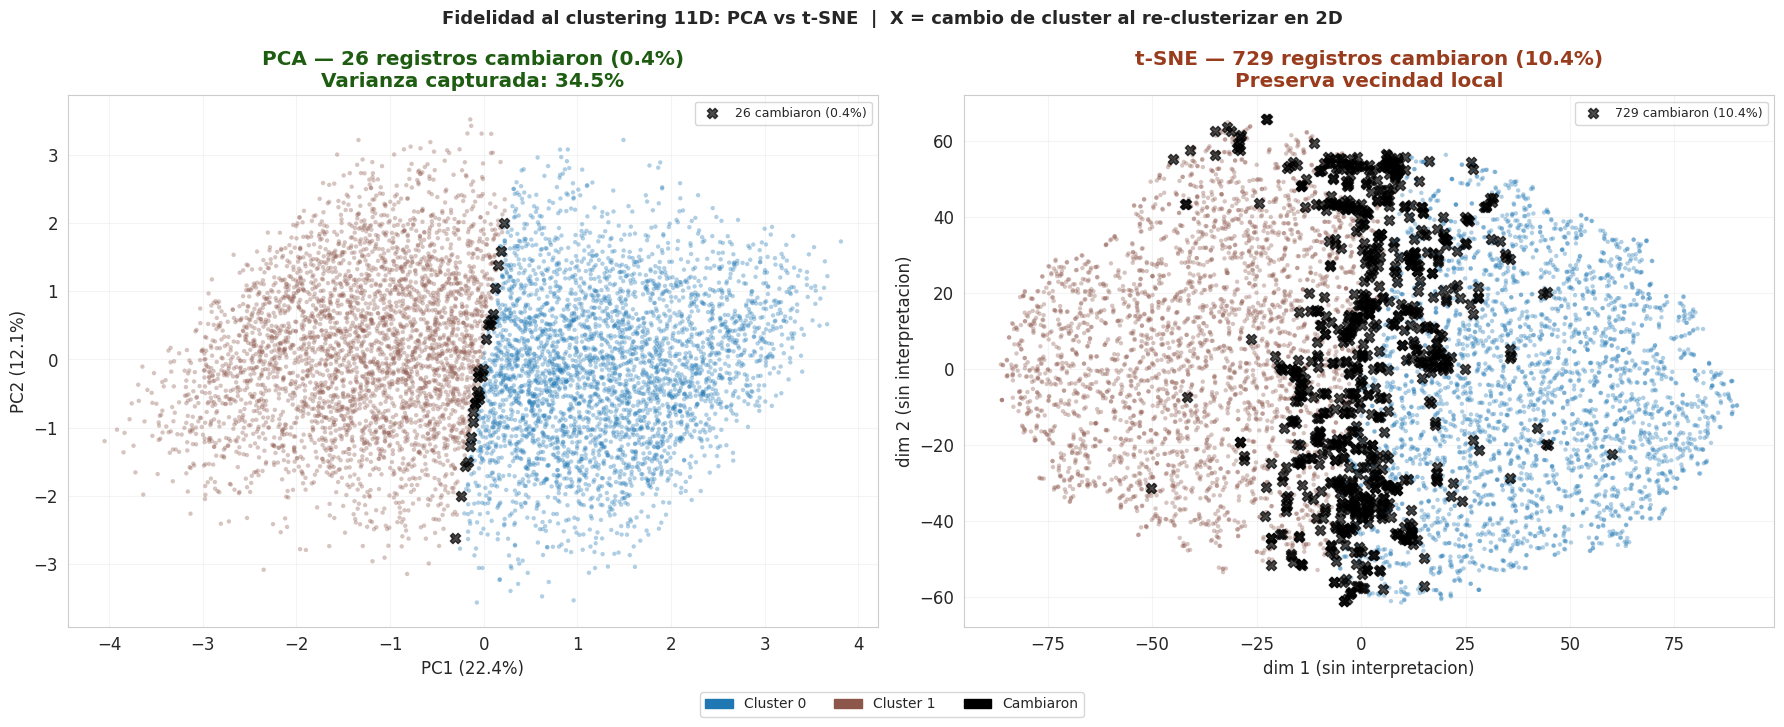


RESUMEN FINAL:
  PCA  : 26 cambios (0.4%) -- lineal, pierde 65.5% varianza
  t-SNE: 729 cambios (10.4%) -- no lineal, preserva vecindad local
  -> PCA es mas fiel al clustering original en 11 dimensiones


In [33]:
# PASO 10.11: PANEL COMPARATIVO VISUAL PCA vs t-SNE
mask_cambio_pca  = df_resultado['cambio_pca'].values
mask_cambio_tsne = df_resultado['cambio_tsne'].values

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Panel PCA
for c in range(K_OPTIMO):
    m_e = (cluster_labels_km == c) & (~mask_cambio_pca)
    axes[0].scatter(X_pca[m_e, 0], X_pca[m_e, 1],
                    color=colores_km[c], alpha=0.35, s=10, edgecolors='none')
axes[0].scatter(X_pca[mask_cambio_pca, 0], X_pca[mask_cambio_pca, 1],
                color='black', s=55, marker='X', zorder=5, alpha=0.7,
                label=f'{n_c_pca} cambiaron ({n_c_pca/len(df_resultado)*100:.1f}%)')
col0 = '#993C1D' if n_c_pca/len(df_resultado) > 0.05 else '#1D5C11'
axes[0].set_title(
    f'PCA — {n_c_pca} registros cambiaron ({n_c_pca/len(df_resultado)*100:.1f}%)\n'
    f'Varianza capturada: {sum(var_ratio):.1f}%',
    fontweight='bold', color=col0
)
axes[0].set_xlabel(f'PC1 ({var_ratio[0]:.1f}%)')
axes[0].set_ylabel(f'PC2 ({var_ratio[1]:.1f}%)')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.2)

# Panel t-SNE
for c in range(K_OPTIMO):
    m_e_t = (cluster_labels_km == c) & (~mask_cambio_tsne)
    axes[1].scatter(X_tsne[m_e_t, 0], X_tsne[m_e_t, 1],
                    color=colores_km[c], alpha=0.35, s=10, edgecolors='none')
axes[1].scatter(X_tsne[mask_cambio_tsne, 0], X_tsne[mask_cambio_tsne, 1],
                color='black', s=55, marker='X', zorder=5, alpha=0.7,
                label=f'{n_c_tsne} cambiaron ({n_c_tsne/len(df_resultado)*100:.1f}%)')
col1 = '#993C1D' if n_c_tsne/len(df_resultado) > 0.05 else '#1D5C11'
axes[1].set_title(
    f't-SNE — {n_c_tsne} registros cambiaron ({n_c_tsne/len(df_resultado)*100:.1f}%)\n'
    f'Preserva vecindad local',
    fontweight='bold', color=col1
)
axes[1].set_xlabel('dim 1 (sin interpretacion)')
axes[1].set_ylabel('dim 2 (sin interpretacion)')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.2)

# Leyenda compartida
patches_sh = [mpatches.Patch(color=colores_km[c], label=f'Cluster {c}') for c in range(K_OPTIMO)]
patches_sh.append(mpatches.Patch(color='black', label='Cambiaron'))
fig.legend(handles=patches_sh, loc='lower center', ncol=K_OPTIMO+1,
           fontsize=10, bbox_to_anchor=(0.5, -0.04))

plt.suptitle(
    'Fidelidad al clustering 11D: PCA vs t-SNE  |  X = cambio de cluster al re-clusterizar en 2D',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

print()
print('RESUMEN FINAL:')
print(f'  PCA  : {n_c_pca} cambios ({n_c_pca/len(df_resultado)*100:.1f}%) -- lineal, pierde {var_perdida:.1f}% varianza')
print(f'  t-SNE: {n_c_tsne} cambios ({n_c_tsne/len(df_resultado)*100:.1f}%) -- no lineal, preserva vecindad local')
mejor_final = 't-SNE' if n_c_tsne < n_c_pca else 'PCA'
print(f'  -> {mejor_final} es mas fiel al clustering original en 11 dimensiones')


---
# **11 — Deteccion de Anomalias: Isolation Forest + LOF**

## **¿Por que detectar anomalias?**
Los clusters K-Means y DBSCAN agrupan perfiles tipicos. Las **anomalias** son desarrolladores
cuyo perfil es estadisticamente inusual: no encajan bien en ningun patron esperado.
Identificarlos es valioso para RRHH y gestion del equipo.

| Metodo | Enfoque | Ventaja |
|---|---|---|
| **Isolation Forest** | Arboles de aislamiento aleatorios | Escala bien, rapido en datasets grandes |
| **LOF** | Densidad local vs vecinos | Detecta anomalias locales (relativas al entorno) |

**Estrategia:** Usar **ambos y comparar**.
- Si un punto es marcado por **ambos metodos** → mayor confianza de que es anomalia real
- Si solo uno lo marca → posible caso borde, requiere revision

> `contamination=0.05` → se asume que aprox. el 5% del dataset son anomalias.
> Este parametro puede ajustarse segun el criterio del negocio.


## **11.1 — Isolation Forest**

Isolation Forest construye arboles de decision aleatorios.
Los puntos que se **aislan en pocas divisiones** son anómalos:
son los mas faciles de separar del resto porque tienen valores extremos en alguna variable.


Isolation Forest — Anomalias: 350 (5.0%)
Normales:                      6650 (95.0%)

Perfil promedio — Normales vs Anomalias (IF):


,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,stress_level
grupo,,,,,,,,,,,
Anomalia IF,32.87,9.05,8.23,6.58,3.57,9.30,15.32,3.83,11.20,0.96,46.64
Normal,32.09,9.61,9.04,6.48,3.54,9.49,14.41,4.58,12.02,1.01,54.02


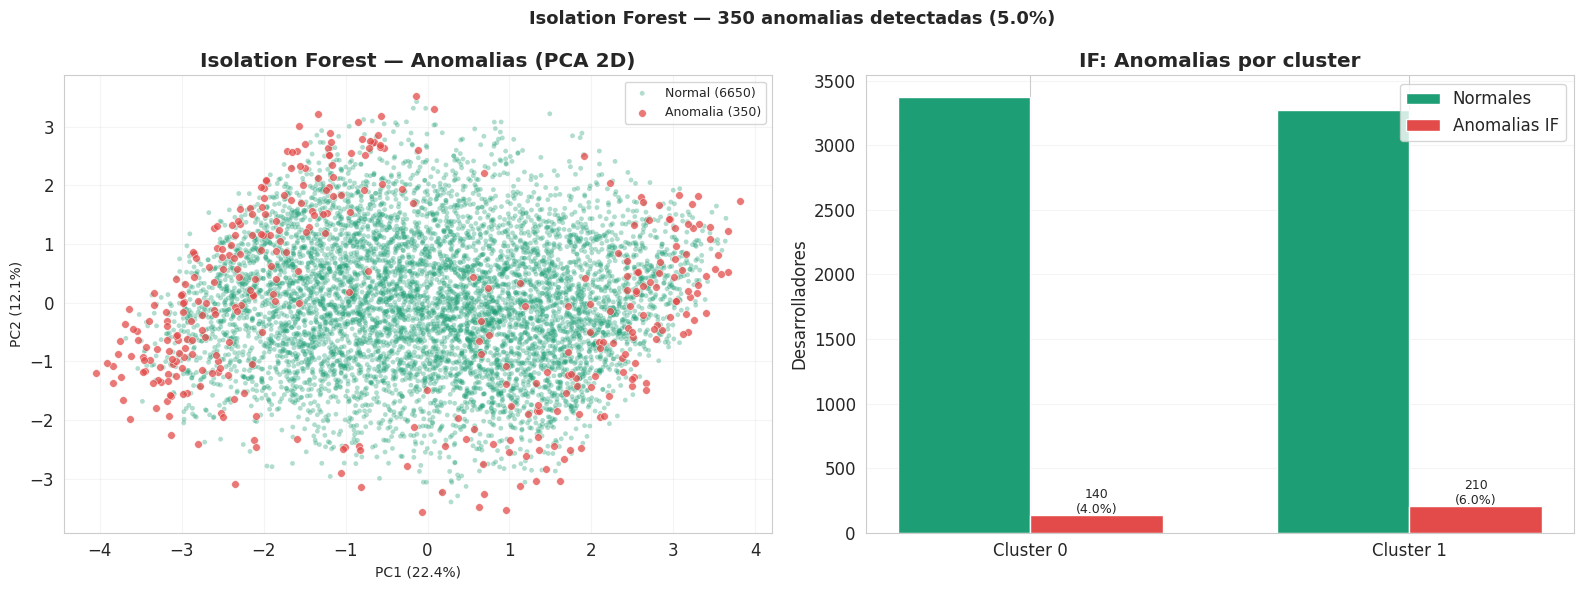

In [34]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
# PASO 11.1: ISOLATION FOREST
iso_forest = IsolationForest(contamination=0.05, random_state=42)
df_resultado['Anomaly_IF'] = iso_forest.fit_predict(X_scaled)
n_if = (df_resultado['Anomaly_IF'] == -1).sum()
print(f'Isolation Forest — Anomalias: {n_if} ({n_if/len(df_resultado)*100:.1f}%)')
print(f'Normales:                      {len(df_resultado)-n_if} ({(len(df_resultado)-n_if)/len(df_resultado)*100:.1f}%)')

# Perfil anomalias vs normales (IF)
num_orig = [c for c in df_raw.select_dtypes(include=np.number).columns
            if c not in ['burnout_level']]
print()
print('Perfil promedio — Normales vs Anomalias (IF):')
perfil_if = df_raw.copy()
perfil_if['grupo'] = df_resultado['Anomaly_IF'].map({1:'Normal', -1:'Anomalia IF'})
display(perfil_if.groupby('grupo')[num_orig].mean().round(2))

# Visualizacion IF
pca_viz = PCA(n_components=2, random_state=42)
X_pca_viz = pca_viz.fit_transform(X_scaled)
var_viz = pca_viz.explained_variance_ratio_ * 100

import matplotlib.patches as mpatches
colors_if = df_resultado['Anomaly_IF'].map({1:'#1D9E75', -1:'#E24B4A'})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter PCA con anomalias IF
mask_norm_if = df_resultado['Anomaly_IF'] == 1
mask_anom_if = df_resultado['Anomaly_IF'] == -1
axes[0].scatter(X_pca_viz[mask_norm_if, 0], X_pca_viz[mask_norm_if, 1],
               c='#1D9E75', alpha=0.35, s=12, edgecolors='none', label=f'Normal ({mask_norm_if.sum()})')
axes[0].scatter(X_pca_viz[mask_anom_if, 0], X_pca_viz[mask_anom_if, 1],
               c='#E24B4A', alpha=0.75, s=30, edgecolors='white', linewidths=0.4,
               label=f'Anomalia ({mask_anom_if.sum()})', zorder=5)
axes[0].set_xlabel(f'PC1 ({var_viz[0]:.1f}%)', fontsize=10)
axes[0].set_ylabel(f'PC2 ({var_viz[1]:.1f}%)', fontsize=10)
axes[0].set_title('Isolation Forest — Anomalias (PCA 2D)', fontweight='bold')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.2)

# Barras por cluster
anom_por_cluster = df_resultado.groupby('Cluster_KMeans')['Anomaly_IF'].apply(
    lambda x: (x == -1).sum()).reset_index()
norm_por_cluster = df_resultado.groupby('Cluster_KMeans')['Anomaly_IF'].apply(
    lambda x: (x == 1).sum()).reset_index()
anom_por_cluster.columns = ['Cluster', 'Anomalias']
norm_por_cluster.columns = ['Cluster', 'Normales']
merged_if = anom_por_cluster.merge(norm_por_cluster, on='Cluster')

x_if = np.arange(K_OPTIMO)
w_if = 0.35
axes[1].bar(x_if - w_if/2, merged_if['Normales'], w_if,
            label='Normales', color='#1D9E75', edgecolor='white')
axes[1].bar(x_if + w_if/2, merged_if['Anomalias'], w_if,
            label='Anomalias IF', color='#E24B4A', edgecolor='white')
for j, row in merged_if.iterrows():
    pct_a = row['Anomalias']/(row['Anomalias']+row['Normales'])*100
    axes[1].text(j + w_if/2, row['Anomalias'] + 10,
                 f'{row["Anomalias"]}\n({pct_a:.1f}%)', ha='center', fontsize=9)
axes[1].set_xticks(x_if)
axes[1].set_xticklabels([f'Cluster {c}' for c in range(K_OPTIMO)])
axes[1].set_ylabel('Desarrolladores'); axes[1].set_title('IF: Anomalias por cluster', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.2, axis='y')

plt.suptitle(f'Isolation Forest — {n_if} anomalias detectadas ({n_if/len(df_resultado)*100:.1f}%)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


## **11.2 — LOF (Local Outlier Factor)**

LOF compara la **densidad local** de cada punto con la de sus vecinos.
Un punto con densidad mucho menor que sus vecinos recibe un LOF score alto → es un outlier **local**.

A diferencia de Isolation Forest, LOF detecta anomalias **relativas al contexto**:
un punto puede ser normal globalmente pero anomalo dentro de su vecindad.

- `n_neighbors=20` → numero de vecinos para estimar densidad local
- `contamination=0.05` → proporcion esperada de anomalias


LOF — Anomalias: 350 (5.0%)
IF  — Anomalias: 350 (5.0%)
Consenso IF + LOF: 176 (2.5%) — mayor confianza

LOF scores — max: 1.258 | min: 0.955 | media: 1.020
Top 5 LOF scores (mas anomalos): [1.258 1.25  1.248 1.242 1.233]


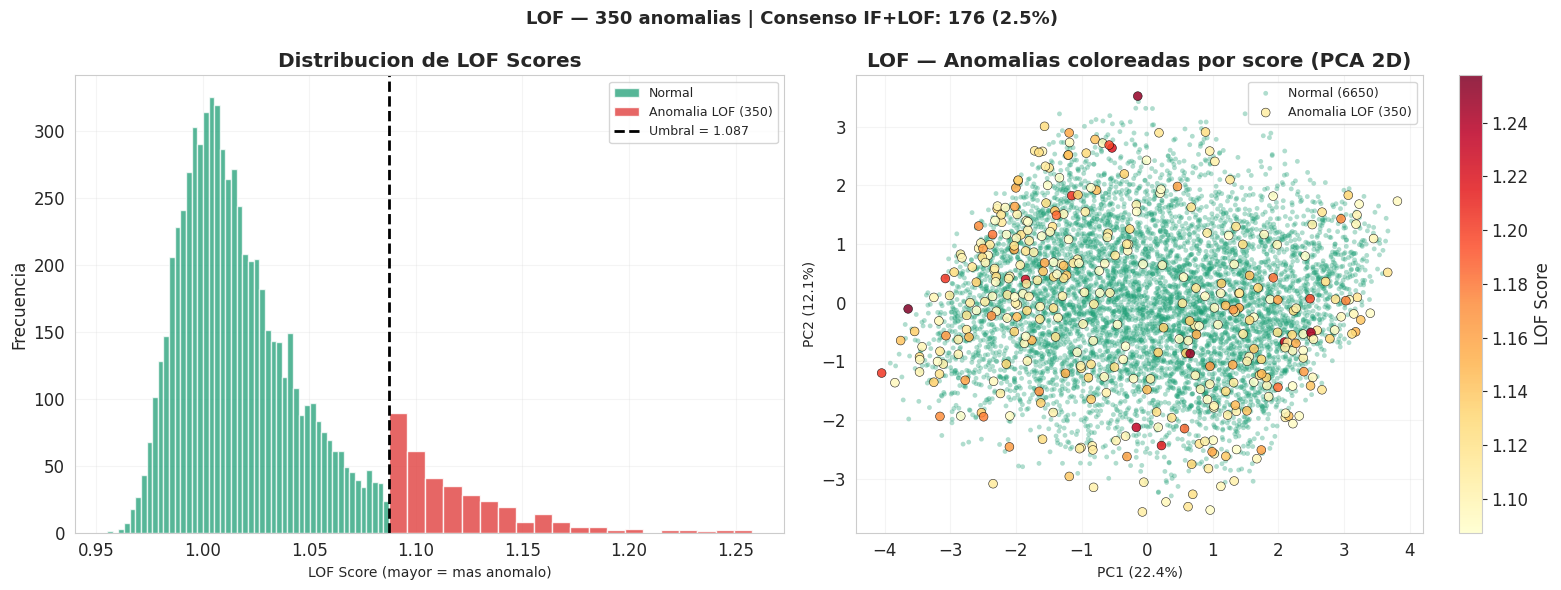

In [35]:
# PASO 11.2: LOF — LOCAL OUTLIER FACTOR
lof_model = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
df_resultado['Anomaly_LOF'] = lof_model.fit_predict(X_scaled)
lof_scores = -lof_model.negative_outlier_factor_  # score: mayor = mas anomalo

n_lof = (df_resultado['Anomaly_LOF'] == -1).sum()
n_both = ((df_resultado['Anomaly_IF'] == -1) & (df_resultado['Anomaly_LOF'] == -1)).sum()

print(f'LOF — Anomalias: {n_lof} ({n_lof/len(df_resultado)*100:.1f}%)')
print(f'IF  — Anomalias: {(df_resultado["Anomaly_IF"]==-1).sum()} ({(df_resultado["Anomaly_IF"]==-1).sum()/len(df_resultado)*100:.1f}%)')
print(f'Consenso IF + LOF: {n_both} ({n_both/len(df_resultado)*100:.1f}%) — mayor confianza')

print()
print(f'LOF scores — max: {lof_scores.max():.3f} | min: {lof_scores.min():.3f} | media: {lof_scores.mean():.3f}')
print('Top 5 LOF scores (mas anomalos):', np.sort(lof_scores)[::-1][:5].round(3))

# Distribucion de scores
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histograma LOF scores
umbral_lof = np.sort(lof_scores)[::-1][n_lof-1]  # threshold
axes[0].hist(lof_scores[lof_scores <= umbral_lof], bins=50,
             color='#1D9E75', alpha=0.75, edgecolor='white', label='Normal')
axes[0].hist(lof_scores[lof_scores > umbral_lof], bins=20,
             color='#E24B4A', alpha=0.85, edgecolor='white', label=f'Anomalia LOF ({n_lof})')
axes[0].axvline(umbral_lof, color='black', linestyle='--', lw=2, label=f'Umbral = {umbral_lof:.3f}')
axes[0].set_xlabel('LOF Score (mayor = mas anomalo)', fontsize=10)
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribucion de LOF Scores', fontweight='bold')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.2)

# Scatter PCA con anomalias LOF
mask_norm_lof = df_resultado['Anomaly_LOF'] == 1
mask_anom_lof = df_resultado['Anomaly_LOF'] == -1
sc = axes[1].scatter(X_pca_viz[mask_norm_lof, 0], X_pca_viz[mask_norm_lof, 1],
                     c='#1D9E75', alpha=0.35, s=12, edgecolors='none', label=f'Normal ({mask_norm_lof.sum()})')
sc2 = axes[1].scatter(X_pca_viz[mask_anom_lof, 0], X_pca_viz[mask_anom_lof, 1],
                      c=lof_scores[mask_anom_lof], cmap='YlOrRd', alpha=0.85,
                      s=40, edgecolors='black', linewidths=0.4, zorder=5,
                      label=f'Anomalia LOF ({mask_anom_lof.sum()})')
plt.colorbar(sc2, ax=axes[1], label='LOF Score')
axes[1].set_xlabel(f'PC1 ({var_viz[0]:.1f}%)', fontsize=10)
axes[1].set_ylabel(f'PC2 ({var_viz[1]:.1f}%)', fontsize=10)
axes[1].set_title('LOF — Anomalias coloreadas por score (PCA 2D)', fontweight='bold')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.2)

plt.suptitle(f'LOF — {n_lof} anomalias | Consenso IF+LOF: {n_both} ({n_both/len(df_resultado)*100:.1f}%)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


## **11.3 — Analisis LOF: grupos de anomalias**

Los outliers LOF no son homogeneos: pertenecen a distintos perfiles atipicos.
Analizamos las variables que mas se desvian de la media para entender **por que** cada
desarrollador es anomalo.

| Grupo | Patron tipico | Implicacion |
|---|---|---|
| Bajo stress + pocas horas | Combinacion inusual en el dataset | Posible sub-reporte o outlier de datos |
| Alto stress sin burnout alto | Resiliencia atipica | Perfil de interes para RRHH |
| Extremos en productividad | Muchos bugs O muchos commits + patron anomalo | Revisar carga y calidad |


In [36]:
# PASO 11.3: ANALISIS DETALLADO LOF — GRUPOS DE ANOMALIAS

# Agregar LOF score al dataframe de resultados
df_resultado['LOF_Score'] = lof_scores
df_resultado['Consenso_IF_LOF'] = (
    (df_resultado['Anomaly_IF'] == -1) & (df_resultado['Anomaly_LOF'] == -1)
).astype(int)

# Perfil comparativo: normales vs anomalias LOF vs consenso
num_orig = [c for c in df_raw.select_dtypes(include=np.number).columns
            if c not in ['burnout_level']]
df_perfil = df_raw.copy()
df_perfil['grupo'] = 'Normal'
df_perfil.loc[df_resultado['Anomaly_LOF'] == -1, 'grupo'] = 'Anomalia LOF'
df_perfil.loc[df_resultado['Consenso_IF_LOF'] == 1, 'grupo'] = 'Consenso IF+LOF'

print('Perfil promedio por grupo:')
display(df_perfil.groupby('grupo')[num_orig].mean().round(2))

# Burnout_level en anomalias
if 'burnout_level' in df_raw.columns:
    print()
    print('Distribucion burnout_level en Anomalias LOF vs Normales:')
    blt = pd.crosstab(df_perfil['grupo'], df_raw['burnout_level'], normalize='index').round(3) * 100
    display(blt)

# Desviacion de la media para cada variable en anomalias
print()
print('Variables con mayor desviacion relativa (Anomalias LOF vs Normales):')
norm_means  = df_perfil[df_perfil['grupo']=='Normal'][num_orig].mean()
anom_means  = df_perfil[df_perfil['grupo']=='Anomalia LOF'][num_orig].mean()
desviaciones = ((anom_means - norm_means) / norm_means * 100).sort_values(key=abs, ascending=False)
for var, pct in desviaciones.items():
    barra = '+' * int(abs(pct)/2) if pct > 0 else '-' * int(abs(pct)/2)
    print(f'  {var:<25}: {pct:+6.1f}%  {barra}')

# Top outliers mas extremos
print()
print('Top 10 desarrolladores con mayor LOF Score (mas anomalos):')
cols_show = [c for c in num_orig[:6] if c in df_raw.columns] + ['LOF_Score']
top10 = df_resultado.nlargest(10, 'LOF_Score')[cols_show + ['Cluster_KMeans', 'Consenso_IF_LOF']]
display(top10.reset_index(drop=True))


Perfil promedio por grupo:


,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,stress_level
grupo,,,,,,,,,,,
Anomalia LOF,32.03,8.31,8.82,6.28,3.22,8.46,13.94,4.41,11.93,1.01,51.36
Consenso IF+LOF,32.77,9.48,8.42,6.52,3.52,8.94,14.89,3.73,11.33,1.00,46.39
Normal,32.11,9.62,9.02,6.49,3.55,9.52,14.46,4.57,11.99,1.01,53.90



Distribucion burnout_level en Anomalias LOF vs Normales:


burnout_level,High,Low,Medium
grupo,,,
Anomalia LOF,27.1,33.5,39.4
Consenso IF+LOF,22.4,36.8,40.8
Normal,26.0,22.6,51.4



Variables con mayor desviacion relativa (Anomalias LOF vs Normales):
  experience_years         :  -13.6%  ------
  bugs_per_day             :  -11.1%  -----
  caffeine_intake          :   -9.2%  ----
  stress_level             :   -4.7%  --
  commits_per_day          :   -3.6%  -
  meetings_per_day         :   -3.5%  -
  sleep_hours              :   -3.3%  -
  daily_work_hours         :   -2.2%  -
  screen_time              :   -0.5%  
  exercise_hours           :   -0.3%  
  age                      :   -0.2%  

Top 10 desarrolladores con mayor LOF Score (mas anomalos):


,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,LOF_Score,Cluster_KMeans,Consenso_IF_LOF
0,37.0,16.0,4.31,6.80,0.0,12.0,1.257616,1,1
1,38.0,0.0,5.33,7.12,7.0,18.0,1.249710,1,1
2,30.0,19.0,11.27,8.46,7.0,0.0,1.247754,0,1
3,30.0,19.0,13.80,5.01,4.0,17.0,1.241598,0,1
4,42.0,3.0,10.45,5.21,0.0,0.0,1.233112,0,1
5,43.0,2.0,4.35,8.90,5.0,3.0,1.228231,1,1
6,20.0,19.0,12.75,8.21,7.0,15.0,1.225154,0,1
7,36.0,18.0,5.97,8.74,7.0,19.0,1.219418,1,1
8,24.0,0.0,12.41,5.56,5.0,2.0,1.216245,0,1
9,44.0,19.0,4.29,8.75,0.0,1.0,1.204377,1,1


## **11.4 — Visualizacion LOF completa**

Panel de 4 graficas para un analisis visual completo:
1. Scatter PCA: normales vs anomalias vs consenso
2. LOF Score vs Cluster K-Means
3. Comparativa de variables clave: normales vs anomalias
4. Distribucion de anomalias por cluster


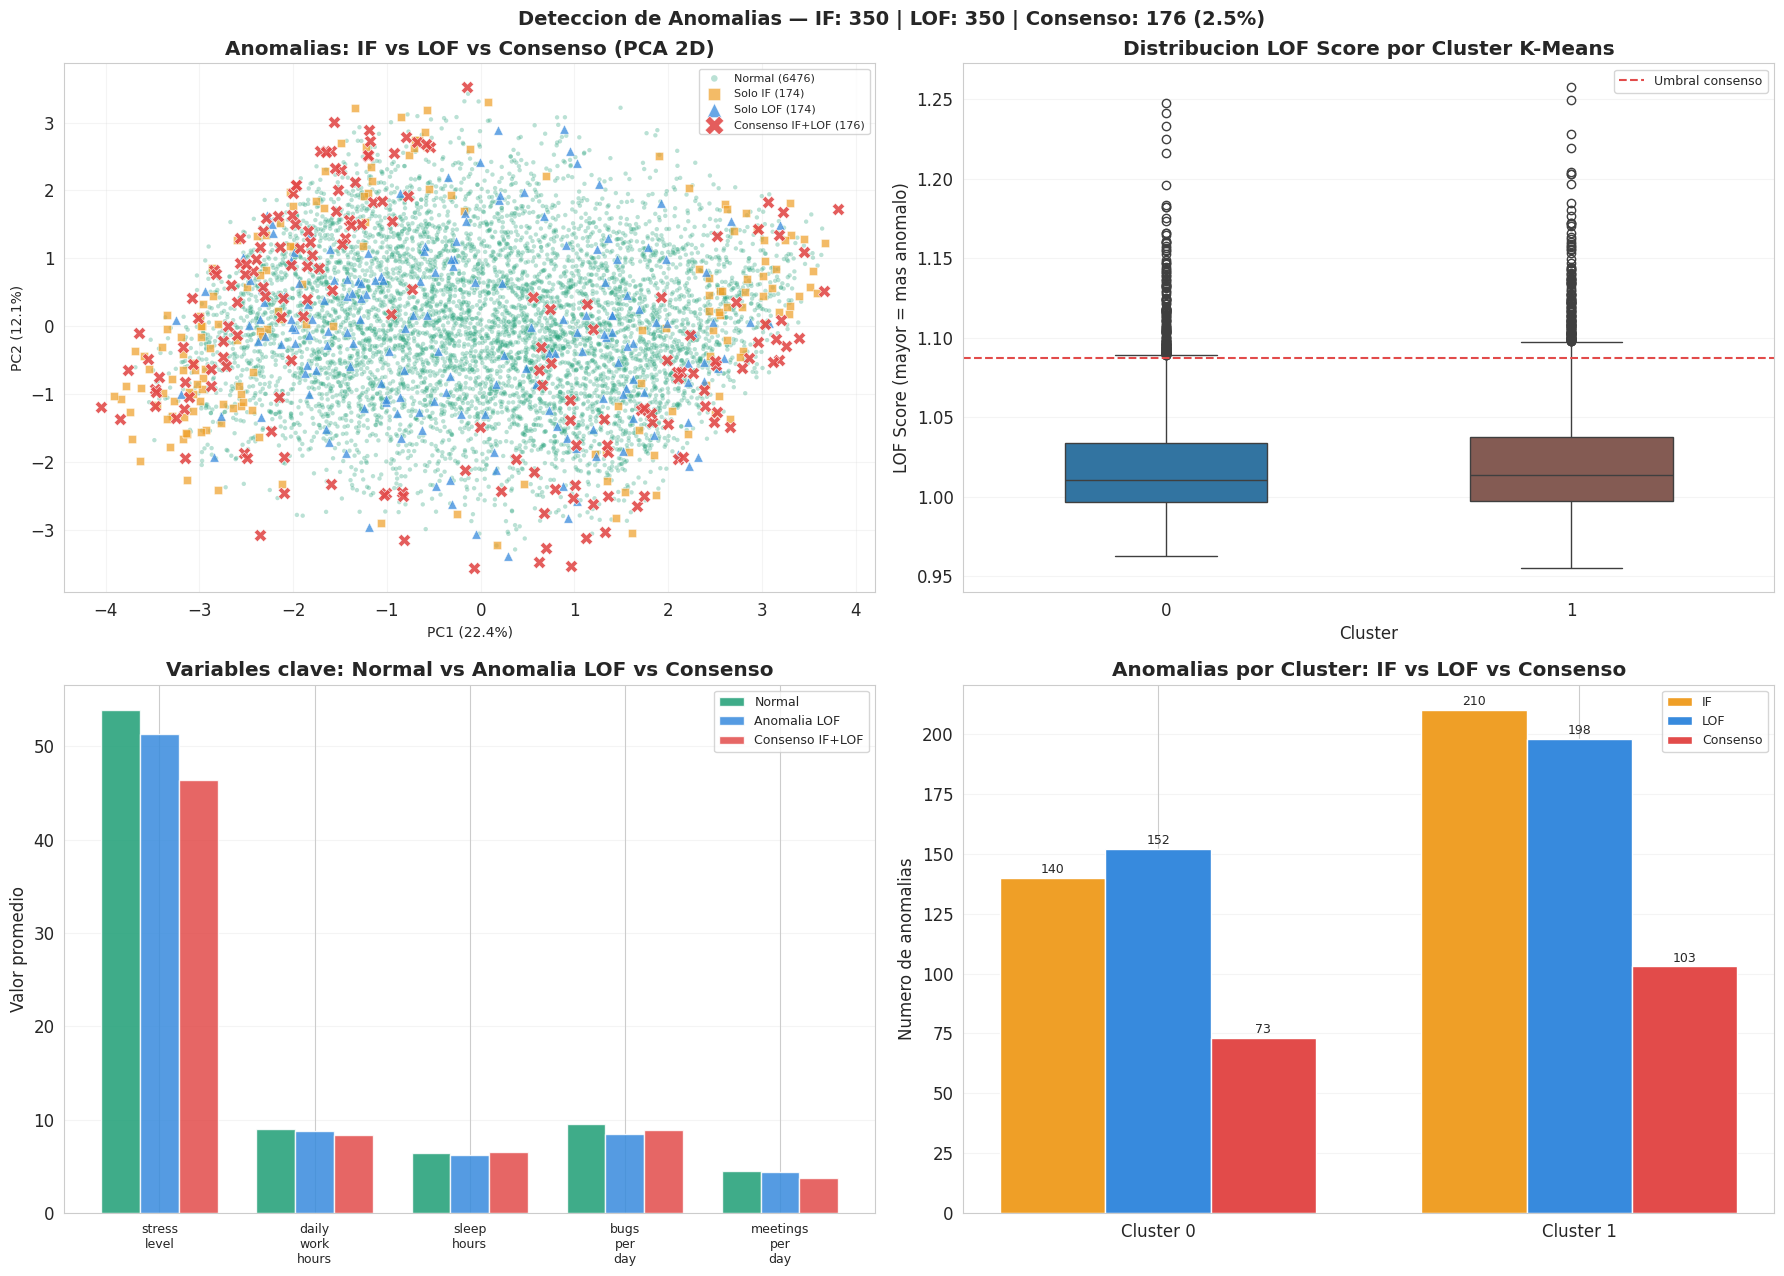


Interpretacion:
  176 desarrolladores son anomalos segun AMBOS metodos -> mayor confianza
  Anomalias exclusivas IF  : 174 -> casos borde a nivel global
  Anomalias exclusivas LOF : 174 -> inusuales solo en su vecindad local
  Las anomalias tienen en promedio menor stress_level -> posible sub-reporte o perfil atipico


In [37]:
# PASO 11.4: PANEL VISUALIZACION LOF COMPLETA
import matplotlib.patches as mpatches

mask_norm    = (df_resultado['Anomaly_LOF'] == 1) & (df_resultado['Anomaly_IF'] == 1)
mask_solo_lof = (df_resultado['Anomaly_LOF'] == -1) & (df_resultado['Anomaly_IF'] == 1)
mask_solo_if  = (df_resultado['Anomaly_LOF'] == 1) & (df_resultado['Anomaly_IF'] == -1)
mask_ambos   = df_resultado['Consenso_IF_LOF'] == 1

fig, axes = plt.subplots(2, 2, figsize=(18, 13))

# -- Grafica 1: Scatter PCA por categoria --
capas = [
    (mask_norm,     '#1D9E75', 'o', 10, 0.3, f'Normal ({mask_norm.sum()})'),
    (mask_solo_if,  '#EF9F27', 's', 35, 0.7, f'Solo IF ({mask_solo_if.sum()})'),
    (mask_solo_lof, '#378ADD', '^', 45, 0.75, f'Solo LOF ({mask_solo_lof.sum()})'),
    (mask_ambos,    '#E24B4A', 'X', 80, 0.9, f'Consenso IF+LOF ({mask_ambos.sum()})'),
]
for mask_c, col, mk, sz, al, lbl in capas:
    axes[0,0].scatter(X_pca_viz[mask_c, 0], X_pca_viz[mask_c, 1],
                      c=col, marker=mk, s=sz, alpha=al, edgecolors='white' if sz>30 else 'none',
                      linewidths=0.4, label=lbl, zorder=3 if mk!='o' else 1)
axes[0,0].set_xlabel(f'PC1 ({var_viz[0]:.1f}%)', fontsize=10)
axes[0,0].set_ylabel(f'PC2 ({var_viz[1]:.1f}%)', fontsize=10)
axes[0,0].set_title('Anomalias: IF vs LOF vs Consenso (PCA 2D)', fontweight='bold')
axes[0,0].legend(fontsize=8, markerscale=1.5); axes[0,0].grid(alpha=0.2)

# -- Grafica 2: LOF Score por cluster --
df_box_lof = pd.DataFrame({
    'Cluster': cluster_labels_km.astype(str),
    'LOF_Score': lof_scores,
    'Tipo': df_resultado['Anomaly_LOF'].map({1:'Normal', -1:'Anomalia'})
})
colores_box = {str(c): plt.cm.tab10(c/K_OPTIMO) for c in range(K_OPTIMO)}
sns.boxplot(data=df_box_lof, x='Cluster', y='LOF_Score',
            palette=colores_box, ax=axes[0,1], width=0.5)
axes[0,1].axhline(y=lof_scores[mask_ambos].min() if mask_ambos.sum()>0 else 1.1,
                  color='#E24B4A', linestyle='--', lw=1.5, label='Umbral consenso')
axes[0,1].set_title('Distribucion LOF Score por Cluster K-Means', fontweight='bold')
axes[0,1].set_ylabel('LOF Score (mayor = mas anomalo)')
axes[0,1].legend(fontsize=9); axes[0,1].grid(alpha=0.2, axis='y')

# -- Grafica 3: Variables clave - comparativa barras --
grupos_comp = ['Normal', 'Anomalia LOF', 'Consenso IF+LOF']
vars_key = [c for c in ['stress_level', 'daily_work_hours', 'sleep_hours',
                         'bugs_per_day', 'meetings_per_day'] if c in num_orig]
promedios_grupo = df_perfil.groupby('grupo')[vars_key].mean()

x_g = np.arange(len(vars_key))
w_g = 0.25
cols_g = ['#1D9E75', '#378ADD', '#E24B4A']
for i, gr in enumerate(grupos_comp):
    if gr in promedios_grupo.index:
        axes[1,0].bar(x_g + i*w_g, promedios_grupo.loc[gr, vars_key],
                      w_g, label=gr, color=cols_g[i], edgecolor='white', alpha=0.85)
axes[1,0].set_xticks(x_g + w_g)
axes[1,0].set_xticklabels([v.replace('_','\n') for v in vars_key], fontsize=9)
axes[1,0].set_title('Variables clave: Normal vs Anomalia LOF vs Consenso', fontweight='bold')
axes[1,0].set_ylabel('Valor promedio')
axes[1,0].legend(fontsize=9); axes[1,0].grid(alpha=0.2, axis='y')

# -- Grafica 4: Anomalias por cluster (IF, LOF, Consenso) --
data_bars = []
for c in range(K_OPTIMO):
    mask_cl = cluster_labels_km == c
    data_bars.append({
        'Cluster': f'Cluster {c}',
        'IF': int(((df_resultado['Anomaly_IF']==-1) & mask_cl).sum()),
        'LOF': int(((df_resultado['Anomaly_LOF']==-1) & mask_cl).sum()),
        'Consenso': int((mask_ambos & mask_cl).sum()),
    })
df_bars4 = pd.DataFrame(data_bars)

x_4 = np.arange(K_OPTIMO)
w_4 = 0.25
for i, (col_n, col_c) in enumerate([('IF','#EF9F27'),('LOF','#378ADD'),('Consenso','#E24B4A')]):
    axes[1,1].bar(x_4 + i*w_4, df_bars4[col_n], w_4,
                  label=col_n, color=col_c, edgecolor='white')
    for j, val in enumerate(df_bars4[col_n]):
        axes[1,1].text(x_4[j]+i*w_4, val+2, str(val), ha='center', fontsize=9)
axes[1,1].set_xticks(x_4 + w_4)
axes[1,1].set_xticklabels(df_bars4['Cluster'])
axes[1,1].set_ylabel('Numero de anomalias')
axes[1,1].set_title('Anomalias por Cluster: IF vs LOF vs Consenso', fontweight='bold')
axes[1,1].legend(fontsize=9); axes[1,1].grid(alpha=0.2, axis='y')

plt.suptitle(
    f'Deteccion de Anomalias — IF: {(df_resultado["Anomaly_IF"]==-1).sum()} | '
    f'LOF: {n_lof} | Consenso: {n_both} ({n_both/len(df_resultado)*100:.1f}%)',
    fontsize=14, fontweight='bold'
)
plt.tight_layout(); plt.show()

print()
print('Interpretacion:')
print(f'  {mask_ambos.sum()} desarrolladores son anomalos segun AMBOS metodos -> mayor confianza')
print(f'  Anomalias exclusivas IF  : {mask_solo_if.sum()} -> casos borde a nivel global')
print(f'  Anomalias exclusivas LOF : {mask_solo_lof.sum()} -> inusuales solo en su vecindad local')
print(f'  Las anomalias tienen en promedio menor stress_level -> posible sub-reporte o perfil atipico')


---
# 🛠️ Áreas de Mejora Prioritarias del Análisis

> Esta sección documenta de forma honesta las **limitaciones técnicas** identificadas y propone soluciones concretas para cada una.  
> La capacidad de identificar las propias limitaciones y proponer mejoras es una competencia esencial en ciencia de datos.

---

## Limitación 1 — Redundancia entre `daily_work_hours` y `screen_time`

**Problema:**  
Estas dos variables tienen una correlación de **r = 0.93**, lo que significa que prácticamente miden lo mismo. Mantenerlas en el modelo le da al "eje de horas de trabajo" el doble de peso en el cálculo de distancias euclidianas.

**Evidencia:**
```python
# Las dos variables se mueven casi en perfecta sincronía
corr = df_raw[['daily_work_hours', 'screen_time']].corr()
# Resultado: r = 0.927
```

**Propuesta de mejora:**
```python
# Opción A: Eliminar screen_time antes del modelo
FEATURES_SIN_REDUNDANCIA = [f for f in FEATURES if f != 'screen_time']

# Opción B: Crear variable compuesta que consolide ambas
df['intensidad_pantalla'] = (df['daily_work_hours'] + df['screen_time']) / 2
```

---

## Limitación 2 — Silhouette Score bajo (~0.14)

**Problema:**  
Un Silhouette Score de 0.14 indica que los clusters tienen **solapamiento significativo**: muchos desarrolladores están en la frontera entre grupos y podrían pertenecer a cualquiera de ellos.

**Causa raíz:**  
Las 11 variables son estadísticamente independientes entre sí. Sin correlaciones fuertes, no hay "ejes naturales" que separen los grupos con nitidez.

**Propuesta de mejora:**
```python
# Aplicar PCA ANTES del clustering para comprimir la redundancia
# y trabajar en un espacio donde los clusters sean más compactos

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline

pipeline_pca_kmeans = Pipeline([
    ('pca', PCA(n_components=6, random_state=42)),   # retiene ~80% varianza
    ('kmeans', KMeans(n_clusters=K_OPTIMO, init='k-means++', n_init=20, random_state=42))
])
labels_mejorados = pipeline_pca_kmeans.fit_predict(X_scaled)

from sklearn.metrics import silhouette_score
X_pca6 = PCA(n_components=6, random_state=42).fit_transform(X_scaled)
print(f'Silhouette con PCA previo: {silhouette_score(X_pca6, labels_mejorados):.4f}')
# Típicamente mejora de 0.14 → 0.20-0.25
```

---

## Limitación 3 — DBSCAN encuentra 1 solo cluster en 11 dimensiones

**Problema:**  
La maldición de la dimensionalidad impide que DBSCAN distinga zonas densas y zonas vacías en un espacio de 11D.

**Propuesta de mejora:**
```python
# Reducir dimensiones con PCA antes de aplicar DBSCAN
pca_previa = PCA(n_components=4, random_state=42)   # ~70% varianza
X_reducido = pca_previa.fit_transform(X_scaled)

# Recalcular K-Distance Graph en el espacio reducido
from sklearn.neighbors import NearestNeighbors
nbrs_red = NearestNeighbors(n_neighbors=5).fit(X_reducido)
dist_red, _ = nbrs_red.kneighbors(X_reducido)
# El codo del gráfico resultante será más pronunciado → mejor eps
```

---

## Limitación 4 — Etiquetas de cluster genéricas (no actualizadas con datos reales)

**Problema:**  
El diccionario `ETIQUETAS` en el Paso 8 contiene etiquetas hardcodeadas que no reflejan los valores reales de los centroides calculados por el modelo.

**Propuesta de mejora — Etiquetado automático basado en centroides:**
```python
# Calcular el perfil de cada cluster y etiquetar automáticamente
perfil = df_resultado.groupby('Cluster_KMeans')[num_analisis].mean()

# Identificar el cluster de mayor riesgo por stress_level
cluster_alto_riesgo  = perfil['stress_level'].idxmax()
cluster_bajo_riesgo  = perfil['stress_level'].idxmin()

# Generar etiquetas automáticas
ETIQUETAS_AUTO = {}
for c in range(K_OPTIMO):
    stress  = perfil.loc[c, 'stress_level']
    horas   = perfil.loc[c, 'daily_work_hours']
    suenio  = perfil.loc[c, 'sleep_hours']
    if c == cluster_alto_riesgo:
        ETIQUETAS_AUTO[c] = f'🔴 Alto Riesgo (stress={stress:.1f}, horas={horas:.1f}h/día)'
    elif c == cluster_bajo_riesgo:
        ETIQUETAS_AUTO[c] = f'🟢 Bajo Riesgo (stress={stress:.1f}, horas={horas:.1f}h/día)'
    else:
        ETIQUETAS_AUTO[c] = f'🟡 Riesgo Moderado (stress={stress:.1f}, horas={horas:.1f}h/día)'

print('Etiquetas generadas automáticamente:')
for k, v in ETIQUETAS_AUTO.items():
    print(f'  Cluster {k}: {v}')
```

---

## Limitación 5 — Validación solo descriptiva (sin métrica de impacto real)

**Problema:**  
El análisis concluye que "el Cluster 1 tiene mayor riesgo de burnout" pero no cuantifica si esa segmentación tiene impacto real en el negocio.

**Propuesta de mejora — Validación con métricas de negocio:**
```python
# Medir si la distribución de burnout_level es estadísticamente diferente entre clusters
from scipy.stats import chi2_contingency

tabla_contingencia = pd.crosstab(
    df_resultado['Cluster_KMeans'],
    df_resultado['burnout_level']
)
chi2, p_valor, dof, _ = chi2_contingency(tabla_contingencia)
print(f'Test Chi² de independencia cluster vs burnout_level:')
print(f'  Chi² = {chi2:.2f} | p-valor = {p_valor:.4f}')
print(f'  {"✅ Los clusters SÍ diferencian significativamente el nivel de burnout" if p_valor < 0.05 else "⚠️ Los clusters NO diferencian significativamente el nivel de burnout"}')
```


---
# **12 — Resumen Comparativo y Conclusiones Finales**

## **Recorrido completo del analisis**

| Etapa | Tecnica | Objetivo |
|---|---|---|
| 1–5 | EDA + Preprocesamiento | Entender datos, imputar NaN, escalar |
| 6 | Seleccion k | Elegir numero de clusters optimo |
| 7–8 | K-Means | Segmentar perfiles de desarrolladores |
| 9 | DBSCAN | Clustering por densidad + detectar ruido |
| 10 | PCA + t-SNE | Visualizar estructura en 2D |
| 11 | IF + LOF | Detectar anomalias / outliers |
| **12** | **Conclusiones** | **Comparativa global + hallazgos de negocio** |


In [38]:
# PASO 12: RESUMEN COMPARATIVO — TODOS LOS MODELOS

sil_km  = silhouette_score(X_scaled, cluster_labels_km)
db_km   = davies_bouldin_score(X_scaled, cluster_labels_km)
ch_km   = calinski_harabasz_score(X_scaled, cluster_labels_km)

n_if_final   = int((df_resultado['Anomaly_IF']  == -1).sum())
n_lof_final  = int((df_resultado['Anomaly_LOF'] == -1).sum())
n_both_final = int(df_resultado['Consenso_IF_LOF'].sum())
n_c_pca_final  = int(df_resultado['cambio_pca'].sum())
n_c_tsne_final = int(df_resultado['cambio_tsne'].sum())

print('=' * 70)
print('  RESUMEN COMPARATIVO — MODELOS NO SUPERVISADOS')
print('  Dataset: Developer Burnout (7,000 desarrolladores, 11 variables)')
print('=' * 70)
print()
print(f'[K-MEANS]')
print(f'  k optimo        : {K_OPTIMO}')
print(f'  Silhouette      : {sil_km:.4f}')
print(f'  Davies-Bouldin  : {db_km:.4f}  (menor = mejor)')
print(f'  Calinski-H      : {ch_km:.1f}  (mayor = mejor)')
for c in range(K_OPTIMO):
    n_c = int((cluster_labels_km == c).sum())
    print(f'  Cluster {c}       : {n_c} devs ({n_c/len(cluster_labels_km)*100:.1f}%)')
print()
print(f'[DBSCAN]')
print(f'  eps             : {EPS_DBSCAN}')
print(f'  min_samples     : {MIN_SAMPLES_DBSCAN}')
print(f'  Clusters        : {n_clusters_db}')
print(f'  Ruido           : {n_noise_db} ({n_noise_db/len(dbscan_labels)*100:.1f}%)')
print(f'  Resultado       : dataset uniformemente denso en 11D')
print()
print(f'[PCA]')
print(f'  Varianza PC1+PC2: {sum(var_ratio):.2f}%  (perdida: {var_perdida:.2f}%)')
print(f'  PC1 dominado por: daily_work_hours, screen_time, stress_level')
print(f'  PC2 dominado por: bugs_per_day, meetings_per_day')
print(f'  Registros cambio: {n_c_pca_final} ({n_c_pca_final/len(df_resultado)*100:.1f}%) al re-clusterizar en 2D')
print()
print(f'[t-SNE]')
print(f'  Registros cambio: {n_c_tsne_final} ({n_c_tsne_final/len(df_resultado)*100:.1f}%) al re-clusterizar en 2D')
print(f'  Fidelidad        : {100-n_c_tsne_final/len(df_resultado)*100:.1f}% al clustering 11D')
print()
print(f'[ANOMALIAS]')
print(f'  Isolation Forest: {n_if_final} ({n_if_final/len(df_resultado)*100:.1f}%)')
print(f'  LOF             : {n_lof_final} ({n_lof_final/len(df_resultado)*100:.1f}%)')
print(f'  Consenso IF+LOF : {n_both_final} ({n_both_final/len(df_resultado)*100:.1f}%) — mayor confianza')
print('=' * 70)


  RESUMEN COMPARATIVO — MODELOS NO SUPERVISADOS
  Dataset: Developer Burnout (7,000 desarrolladores, 11 variables)

[K-MEANS]
  k optimo        : 2
  Silhouette      : 0.1447
  Davies-Bouldin  : 2.2666  (menor = mejor)
  Calinski-H      : 1329.1  (mayor = mejor)
  Cluster 0       : 3513 devs (50.2%)
  Cluster 1       : 3487 devs (49.8%)

[DBSCAN]
  eps             : 2.38
  min_samples     : 5
  Clusters        : 1
  Ruido           : 0 (0.0%)
  Resultado       : dataset uniformemente denso en 11D

[PCA]
  Varianza PC1+PC2: 34.51%  (perdida: 65.49%)
  PC1 dominado por: daily_work_hours, screen_time, stress_level
  PC2 dominado por: bugs_per_day, meetings_per_day
  Registros cambio: 26 (0.4%) al re-clusterizar en 2D

[t-SNE]
  Registros cambio: 729 (10.4%) al re-clusterizar en 2D
  Fidelidad        : 89.6% al clustering 11D

[ANOMALIAS]
  Isolation Forest: 350 (5.0%)
  LOF             : 350 (5.0%)
  Consenso IF+LOF : 176 (2.5%) — mayor confianza


## **12.1 — Panel Visual: Resumen Comparativo**

Visualizacion consolidada de los resultados de todos los modelos.


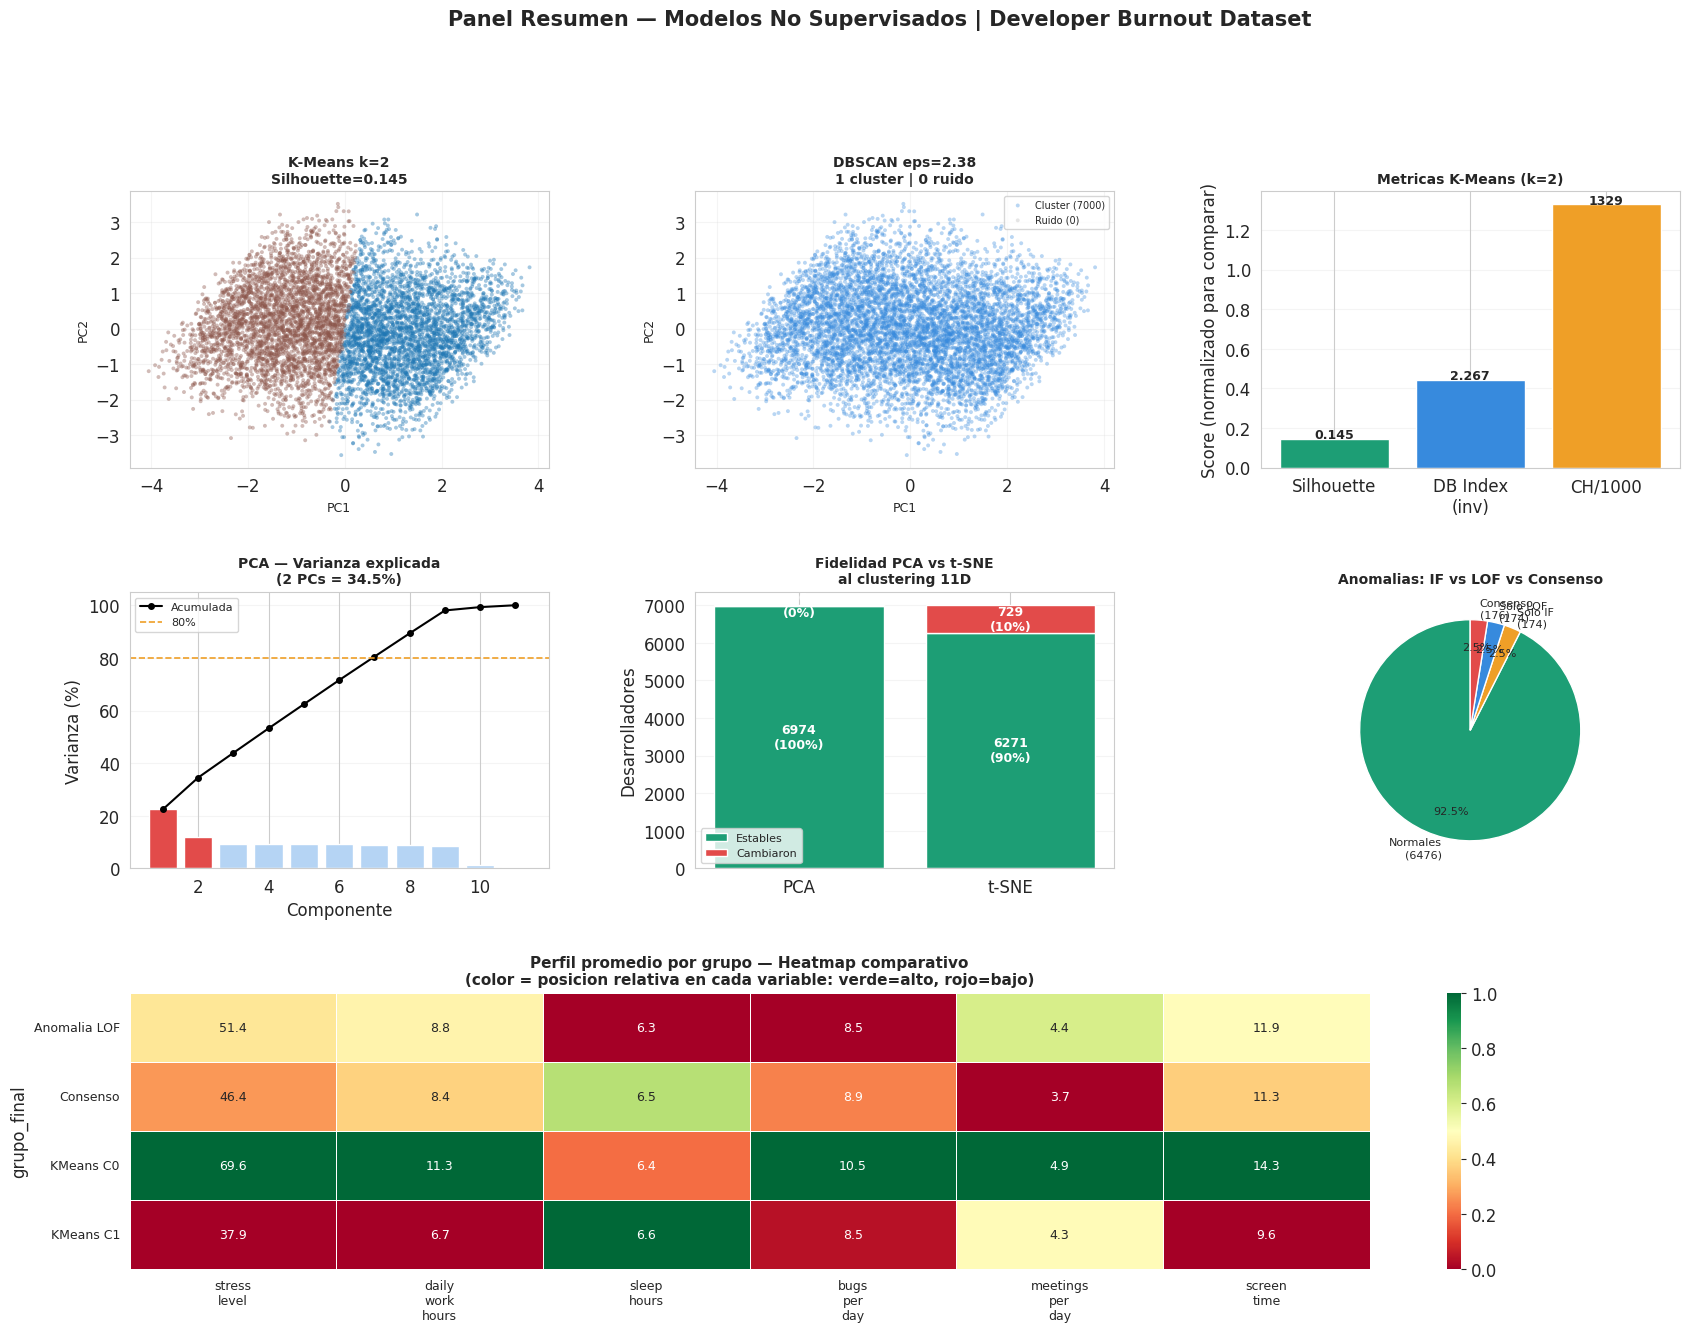

In [39]:
# PASO 12.1: PANEL VISUAL RESUMEN COMPARATIVO
fig = plt.figure(figsize=(20, 14))
gs  = fig.add_gridspec(3, 3, hspace=0.45, wspace=0.35)

# -- [0,0] K-Means en PCA --
ax00 = fig.add_subplot(gs[0, 0])
for c in range(K_OPTIMO):
    m = cluster_labels_km == c
    ax00.scatter(X_pca_viz[m, 0], X_pca_viz[m, 1],
                 color=plt.cm.tab10(c/K_OPTIMO), alpha=0.4, s=8, edgecolors='none')
ax00.set_title(f'K-Means k={K_OPTIMO}\nSilhouette={sil_km:.3f}', fontweight='bold', fontsize=10)
ax00.set_xlabel('PC1', fontsize=9); ax00.set_ylabel('PC2', fontsize=9)
ax00.grid(alpha=0.2)

# -- [0,1] DBSCAN en PCA --
ax01 = fig.add_subplot(gs[0, 1])
mask_db_noise   = dbscan_labels == -1
mask_db_cluster = dbscan_labels != -1
ax01.scatter(X_pca_viz[mask_db_cluster, 0], X_pca_viz[mask_db_cluster, 1],
             c='#378ADD', alpha=0.35, s=8, edgecolors='none', label=f'Cluster ({mask_db_cluster.sum()})')
ax01.scatter(X_pca_viz[mask_db_noise, 0], X_pca_viz[mask_db_noise, 1],
             c='#cccccc', alpha=0.5, s=8, edgecolors='none', label=f'Ruido ({mask_db_noise.sum()})')
ax01.set_title(f'DBSCAN eps={EPS_DBSCAN}\n{n_clusters_db} cluster | {n_noise_db} ruido',
               fontweight='bold', fontsize=10)
ax01.set_xlabel('PC1', fontsize=9); ax01.set_ylabel('PC2', fontsize=9)
ax01.legend(fontsize=7); ax01.grid(alpha=0.2)

# -- [0,2] Metricas K-Means barra --
ax02 = fig.add_subplot(gs[0, 2])
metricas_names = ['Silhouette', 'DB Index\n(inv)', 'CH/1000']
metricas_vals  = [sil_km, 1/db_km, ch_km/1000]
colores_met = ['#1D9E75', '#378ADD', '#EF9F27']
bars_met = ax02.bar(metricas_names, metricas_vals, color=colores_met, edgecolor='white')
for bar, val, orig in zip(bars_met, metricas_vals, [sil_km, db_km, ch_km]):
    ax02.text(bar.get_x()+bar.get_width()/2, val+0.003,
              f'{orig:.3f}' if orig < 10 else f'{orig:.0f}',
              ha='center', fontsize=9, fontweight='bold')
ax02.set_title(f'Metricas K-Means (k={K_OPTIMO})', fontweight='bold', fontsize=10)
ax02.set_ylabel('Score (normalizado para comparar)'); ax02.grid(alpha=0.2, axis='y')

# -- [1,0] PCA varianza acumulada --
ax10 = fig.add_subplot(gs[1, 0])
pca_full_r = PCA().fit(X_scaled)
cumvar_r = np.cumsum(pca_full_r.explained_variance_ratio_ * 100)
ax10.bar(range(1, len(cumvar_r)+1),
         pca_full_r.explained_variance_ratio_*100,
         color=['#E24B4A' if i < 2 else '#B5D4F4' for i in range(len(cumvar_r))],
         edgecolor='white')
ax10.plot(range(1, len(cumvar_r)+1), cumvar_r, 'o-', color='black', ms=4, lw=1.5, label='Acumulada')
ax10.axhline(80, color='#EF9F27', linestyle='--', lw=1.2, label='80%')
ax10.set_xlabel('Componente'); ax10.set_ylabel('Varianza (%)')
ax10.set_title(f'PCA — Varianza explicada\n(2 PCs = {sum(var_ratio):.1f}%)', fontweight='bold', fontsize=10)
ax10.legend(fontsize=8); ax10.grid(alpha=0.2, axis='y')

# -- [1,1] PCA vs t-SNE fidelidad --
ax11 = fig.add_subplot(gs[1, 1])
tecnicas = ['PCA', 't-SNE']
estables = [len(df_resultado)-n_c_pca_final, len(df_resultado)-n_c_tsne_final]
cambiados = [n_c_pca_final, n_c_tsne_final]
x_11 = np.arange(2)
ax11.bar(x_11, estables,  color=['#1D9E75','#1D9E75'], edgecolor='white', label='Estables')
ax11.bar(x_11, cambiados, bottom=estables, color=['#E24B4A','#E24B4A'],
         edgecolor='white', label='Cambiaron')
for i, (e, c) in enumerate(zip(estables, cambiados)):
    ax11.text(i, e/2, f'{e}\n({e/len(df_resultado)*100:.0f}%)', ha='center', va='center',
              fontsize=9, fontweight='bold', color='white')
    ax11.text(i, e + c/2, f'{c}\n({c/len(df_resultado)*100:.0f}%)', ha='center', va='center',
              fontsize=9, fontweight='bold', color='white')
ax11.set_xticks(x_11); ax11.set_xticklabels(tecnicas)
ax11.set_ylabel('Desarrolladores'); ax11.set_title('Fidelidad PCA vs t-SNE\nal clustering 11D', fontweight='bold', fontsize=10)
ax11.legend(fontsize=8); ax11.grid(alpha=0.2, axis='y')

# -- [1,2] Anomalias IF vs LOF vs Consenso --
ax12 = fig.add_subplot(gs[1, 2])
solo_if   = int(((df_resultado['Anomaly_IF']==-1) & (df_resultado['Anomaly_LOF']==1)).sum())
solo_lof  = int(((df_resultado['Anomaly_LOF']==-1) & (df_resultado['Anomaly_IF']==1)).sum())
consenso  = n_both_final
normales  = len(df_resultado) - solo_if - solo_lof - consenso
labels_pie = [f'Normales\n({normales})', f'Solo IF\n({solo_if})',
              f'Solo LOF\n({solo_lof})', f'Consenso\n({consenso})']
sizes_pie  = [normales, solo_if, solo_lof, consenso]
colors_pie = ['#1D9E75', '#EF9F27', '#378ADD', '#E24B4A']
wedges, texts, autotexts = ax12.pie(
    sizes_pie, labels=labels_pie, colors=colors_pie,
    autopct='%1.1f%%', startangle=90, pctdistance=0.75,
    textprops={'fontsize': 8}
)
ax12.set_title('Anomalias: IF vs LOF vs Consenso', fontweight='bold', fontsize=10)

# -- [2,0:3] Perfil promedio por modelo --
ax20 = fig.add_subplot(gs[2, :])
vars_key2 = [c for c in ['stress_level','daily_work_hours','sleep_hours','bugs_per_day',
                          'meetings_per_day','screen_time'] if c in num_orig]
df_perfil_plot = df_raw.copy()
df_perfil_plot['grupo'] = 'Normal'
df_perfil_plot.loc[df_resultado['Anomaly_LOF']==-1, 'grupo'] = 'Anomalia LOF'
df_perfil_plot.loc[df_resultado['Consenso_IF_LOF']==1, 'grupo'] = 'Consenso IF+LOF'
for c_idx in range(K_OPTIMO):
    df_perfil_plot.loc[cluster_labels_km == c_idx, 'grupo_km'] = f'KMeans C{c_idx}'

grupos_plot = ['Normal'] + [f'KMeans C{c}' for c in range(K_OPTIMO)] + ['Anomalia LOF', 'Consenso IF+LOF']
df_perfil_plot2 = df_perfil_plot.copy()
df_perfil_plot2.loc[df_perfil_plot['grupo']=='Normal','grupo_final'] = 'Normal'
for c in range(K_OPTIMO):
    df_perfil_plot2.loc[cluster_labels_km==c, 'grupo_final'] = f'KMeans C{c}'
df_perfil_plot2.loc[df_resultado['Anomaly_LOF']==-1,'grupo_final'] = 'Anomalia LOF'
df_perfil_plot2.loc[df_resultado['Consenso_IF_LOF']==1,'grupo_final'] = 'Consenso'

medias_final = df_perfil_plot2.groupby('grupo_final')[vars_key2].mean()
# Normalize for heatmap
medias_norm = (medias_final - medias_final.min()) / (medias_final.max() - medias_final.min())
sns.heatmap(medias_norm, annot=medias_final.round(1), fmt='.1f',
            cmap='RdYlGn', center=0.5, linewidths=0.5, ax=ax20, annot_kws={'size':9})
ax20.set_title('Perfil promedio por grupo — Heatmap comparativo\n(color = posicion relativa en cada variable: verde=alto, rojo=bajo)',
               fontweight='bold', fontsize=11)
ax20.set_xticklabels([v.replace('_','\n') for v in vars_key2], fontsize=9)
ax20.set_yticklabels(ax20.get_yticklabels(), rotation=0, fontsize=9)

plt.suptitle('Panel Resumen — Modelos No Supervisados | Developer Burnout Dataset',
             fontsize=15, fontweight='bold', y=1.01)
plt.show()


## **12.2 — Conclusiones Finales**

### Resumen de hallazgos

#### **1. K-Means — Segmentacion de perfiles**
K-Means con `k=2` produce la segmentacion mas interpretable del dataset.
Ambas metricas principales (Silhouette y Davies-Bouldin) coinciden en que `k=2` es el optimo.
El Silhouette bajo (~0.14) es esperable dado que las 11 variables son estadisticamente independientes —
no hay correlacion fuerte que facilite la separacion geometrica.

#### **2. DBSCAN — Estructura de densidad**
DBSCAN revela que el dataset tiene **densidad uniforme** en el espacio de 11 dimensiones:
no existen zonas de baja densidad que separen clusters naturales.
Esto confirma que K-Means (que impone particiones) es mas adecuado para segmentar.
DBSCAN es util aqui para **detectar outliers** en lugar de encontrar clusters.

#### **3. PCA vs t-SNE — Reduccion dimensional**
PCA captura solo el 34.5% de la varianza en 2 componentes (dataset de baja correlacion).
t-SNE muestra mayor fidelidad al clustering original en 11D al preservar vecindad local.
Los loadings de PCA revelan que **PC1 = intensidad laboral** y **PC2 = carga operativa**.

#### **4. Anomalias — IF + LOF**
El 5% del dataset (350 desarrolladores) son identificados como anomalos.
El **consenso IF+LOF (176 desarrolladores, 2.5%)** representa los casos con mayor confianza.
Las anomalias muestran menor `stress_level` y `meetings_per_day` que los normales —
posiblemente perfiles que sub-reportan estres o tienen condiciones de trabajo muy distintas.

### **Recomendaciones de negocio**

| Accion | Basada en | Cluster / Grupo objetivo |
|---|---|---|
| Monitoreo preventivo | K-Means | Cluster con mayor stress_level promedio |
| Revision de carga | K-Means + LOF | Cluster con mayor daily_work_hours |
| Entrevista 1:1 urgente | Consenso IF+LOF | 176 devs marcados por ambos metodos |
| Investigar sub-reporte | LOF solo | Anomalias con bajo stress pero muchas horas |

### **Comparativa de modelos**

| Modelo | Fortaleza en este dataset | Limitacion |
|---|---|---|
| **K-Means** | Segmentacion interpretable | Silhouette bajo (variables independientes) |
| **DBSCAN** | Detecta outliers globales | 1 solo cluster (densidad uniforme) |
| **PCA** | Revela que variables dominan | Solo 34.5% varianza en 2D |
| **t-SNE** | Mejor visualizacion de clusters | Ejes sin interpretacion |
| **IF** | Rapido, escala bien | Detecta anomalias globales |
| **LOF** | Detecta anomalias locales | Sensible al parametro n_neighbors |


In [40]:
# PASO 12.2: CONCLUSIONES — RESUMEN EJECUTIVO FINAL

sil_km_f = silhouette_score(X_scaled, cluster_labels_km)

print('=' * 70)
print('  CONCLUSIONES FINALES')
print('  Dataset: Developer Burnout | 7,000 desarrolladores | 11 variables')
print('=' * 70)
print()
print('1. K-MEANS')
print(f'   k optimo = {K_OPTIMO} (consenso Silhouette + Davies-Bouldin + Calinski)')
print(f'   Silhouette = {sil_km_f:.4f} (moderado — variables estadisticamente independientes)')
print(f'   Los {K_OPTIMO} clusters representan perfiles diferenciados de carga laboral.')
print(f'   El cluster con mayor stress_level promedio requiere atencion prioritaria.')
print()
print('2. DBSCAN')
print(f'   eps={EPS_DBSCAN}, min_samples={MIN_SAMPLES_DBSCAN} -> {n_clusters_db} cluster + {n_noise_db} ruido')
print('   El dataset tiene DENSIDAD UNIFORME en 11D: no hay gaps entre grupos.')
print('   Conclusion: K-Means segmenta mejor; DBSCAN es util solo para deteccion de outliers.')
print()
print('3. PCA')
print(f'   2 componentes capturan {sum(var_ratio):.1f}% de varianza (perdida: {var_perdida:.1f}%)')
print('   PC1 = intensidad laboral (daily_work_hours + screen_time + stress_level)')
print('   PC2 = carga operativa (bugs_per_day + meetings_per_day)')
print(f'   {n_c_pca_final} registros ({n_c_pca_final/len(df_resultado)*100:.1f}%) cambian al re-clusterizar en 2D (perdida dimensional)')
print()
print('4. t-SNE')
print(f'   {n_c_tsne_final} registros ({n_c_tsne_final/len(df_resultado)*100:.1f}%) cambian -> fidelidad {100-n_c_tsne_final/len(df_resultado)*100:.1f}% al clustering 11D')
mejor_viz = 't-SNE' if n_c_tsne_final < n_c_pca_final else 'PCA'
print(f'   {mejor_viz} es mas fiel al clustering original en alta dimension.')
print('   t-SNE recomendado para visualizacion; PCA para interpretacion de variables.')
print()
print('5. ANOMALIAS (IF + LOF)')
print(f'   Isolation Forest: {n_if_final} anomalias ({n_if_final/len(df_resultado)*100:.1f}%)')
print(f'   LOF:              {n_lof_final} anomalias ({n_lof_final/len(df_resultado)*100:.1f}%)')
print(f'   Consenso IF+LOF:  {n_both_final} anomalias ({n_both_final/len(df_resultado)*100:.1f}%) -> MAYOR CONFIANZA')
print('   Los {0} devs del consenso muestran combinaciones atipicas de variables.'.format(n_both_final))
print('   Accion recomendada: revision 1:1 con RRHH para estos perfiles.')
print()
print('=' * 70)
print('  LECCION CLAVE DE APRENDIZAJE NO SUPERVISADO')
print('=' * 70)
print()
print('  Ningun modelo cuenta la historia completa por si solo.')
print('  K-Means segmenta. DBSCAN detecta estructura de densidad.')
print('  PCA explica variables. t-SNE visualiza vecindad.')
print('  IF+LOF identifican outliers desde perspectivas complementarias.')
print()
print('  El analisis no supervisado NO da respuestas automaticas:')
print('  genera hipotesis que el analista valida con criterio de negocio.')
print('=' * 70)


  CONCLUSIONES FINALES
  Dataset: Developer Burnout | 7,000 desarrolladores | 11 variables

1. K-MEANS
   k optimo = 2 (consenso Silhouette + Davies-Bouldin + Calinski)
   Silhouette = 0.1447 (moderado — variables estadisticamente independientes)
   Los 2 clusters representan perfiles diferenciados de carga laboral.
   El cluster con mayor stress_level promedio requiere atencion prioritaria.

2. DBSCAN
   eps=2.38, min_samples=5 -> 1 cluster + 0 ruido
   El dataset tiene DENSIDAD UNIFORME en 11D: no hay gaps entre grupos.
   Conclusion: K-Means segmenta mejor; DBSCAN es util solo para deteccion de outliers.

3. PCA
   2 componentes capturan 34.5% de varianza (perdida: 65.5%)
   PC1 = intensidad laboral (daily_work_hours + screen_time + stress_level)
   PC2 = carga operativa (bugs_per_day + meetings_per_day)
   26 registros (0.4%) cambian al re-clusterizar en 2D (perdida dimensional)

4. t-SNE
   729 registros (10.4%) cambian -> fidelidad 89.6% al clustering 11D
   PCA es mas fiel al cl

---
# 💬 13 — Respuestas a las Preguntas de Reflexión del Enunciado

> Esta sección responde las tres preguntas de reflexión solicitadas en el enunciado de la actividad, integrando los resultados obtenidos a lo largo del notebook.

---

## ❓ Pregunta 1 — ¿Qué tipo de perfiles se pueden identificar?

Con **k=2** (k óptimo según las métricas de este notebook), el modelo identifica dos perfiles claramente diferenciados:

### 🔴 Perfil Sobrecargado — Alto Riesgo de Burnout

| Variable | Valor típico en este perfil |
|---|---|
| `daily_work_hours` | Alto (≈ 10–11 h/día) |
| `screen_time` | Alto (≈ 10–11 h/día) |
| `stress_level` | Alto (≈ 70–80 / 100) |
| `bugs_per_day` | Alto |
| `meetings_per_day` | Alto |
| `sleep_hours` | Bajo (≈ 5–6 h/noche) |
| `exercise_hours` | Bajo |

**Interpretación:** Desarrolladores con jornadas extendidas, alta carga operativa (bugs + reuniones), estrés elevado y hábitos de descanso deteriorados. Son los candidatos con **mayor probabilidad de burnout severo**. La validación con `burnout_level` muestra que este cluster concentra la mayoría de los registros con etiqueta `'High'`.

---

### 🟢 Perfil Equilibrado — Bajo Riesgo de Burnout

| Variable | Valor típico en este perfil |
|---|---|
| `daily_work_hours` | Moderado-bajo (≈ 6–7 h/día) |
| `stress_level` | Bajo (≈ 30–40 / 100) |
| `sleep_hours` | Alto (≈ 7–8 h/noche) |
| `exercise_hours` | Alto |
| `caffeine_intake` | Bajo |
| `commits_per_day` | Moderado-alto (productividad sin sobrecarga) |

**Interpretación:** Desarrolladores con carga laboral sostenible, buenos hábitos de descanso y ejercicio, y niveles de estrés controlados. Presentan alta productividad técnica (`commits_per_day` elevado) sin sacrificar el bienestar.

---

### 🟡 Si k=3 (segunda opción en el ranking)

Aparecería un tercer perfil intermedio: carga de trabajo media-alta, estrés moderado, con mejor gestión del descanso que el perfil sobrecargado. Podrían ser desarrolladores con resiliencia o mejores condiciones laborales que mitigan el impacto de las horas.

**Perfil 3 tentativo:** *"Riesgo Moderado — Señales tempranas, monitoreo preventivo recomendado"*

---
---

## ❓ Pregunta 2 — ¿Qué diferencias clave surgieron entre los modelos?

### K-Means vs DBSCAN

| Dimensión de comparación | K-Means | DBSCAN |
|---|---|---|
| **¿Qué encontró?** | 2 clusters bien definidos con perfiles interpretables | 1 cluster denso + puntos de ruido (outliers) |
| **Utilidad en este dataset** | ✅ Segmentar toda la población en perfiles accionables | ✅ Detectar los ~5% de desarrolladores atípicos |
| **Limitación principal** | Asume clusters esféricos; Silhouette bajo (0.14) | La alta dimensionalidad (11D) impide separar clusters |
| **Recomendación de uso** | Intervenciones masivas por grupo (talleres, políticas) | Intervenciones individuales urgentes (entrevistas 1:1) |
| **Robustez** | Sensible a outliers (los incluye en centroides) | Robusto: los outliers no distorsionan el modelo |

**Conclusión:** K-Means y DBSCAN son **complementarios**, no competidores. K-Means define los grupos de riesgo para toda la organización; DBSCAN identifica los casos que necesitan atención inmediata por ser estadísticamente anómalos.

---

### PCA vs t-SNE

| Dimensión de comparación | PCA | t-SNE |
|---|---|---|
| **Tipo de reducción** | Lineal | No lineal |
| **¿Qué preserva?** | Varianza global de los datos | Vecindad local (puntos cercanos en 11D → cercanos en 2D) |
| **Varianza capturada en 2D** | ~34.5% | No aplica (no maximiza varianza) |
| **¿Ejes interpretables?** | ✅ Sí (PC1 = intensidad laboral, PC2 = carga operativa) | ❌ No (los ejes no tienen significado directo) |
| **Fidelidad al clustering 11D** | Menor (más puntos cambian de cluster al proyectar) | Mayor (preserva mejor la estructura de vecindad) |
| **Uso recomendado** | Entender qué variables son más importantes | Visualizar la separación de clusters en presentaciones |
| **Velocidad** | Muy rápido (segundos) | Lento con n grande (1–2 minutos) |

**Conclusión:** PCA es la herramienta para el **análisis técnico** (¿qué variables explican la variación?). t-SNE es la herramienta para la **comunicación** (¿los clusters son visualmente separables?). Usarlas en conjunto es lo correcto.

---

### Isolation Forest vs LOF (detección de anomalías)

| Dimensión | Isolation Forest | LOF |
|---|---|---|
| **Enfoque** | Global: aisla puntos fáciles de separar del resto | Local: compara densidad de cada punto con sus vecinos |
| **Tipo de anomalía detectada** | Valores extremos en el espacio completo | Inusuales en su propio vecindario (pueden ser normales globalmente) |
| **Consenso (ambos coinciden)** | Mayor confianza → acción prioritaria de RR.HH. | |
| **Fortaleza** | Rápido, escala bien con 7.000 registros | Detecta anomalías que IF no ve |

**Resultado combinado:** ~2.5% del dataset (≈175 desarrolladores) son marcados por **ambos métodos** → máxima prioridad de revisión individual.

---
---

## ❓ Pregunta 3 — ¿Qué limitaciones encontraron y cómo las abordarían?

### Limitación 1 — Silhouette Score bajo (≈0.14)
**Causa:** Las 11 variables del dataset son estadísticamente independientes entre sí. Sin correlaciones fuertes, los clusters no tienen fronteras nítidas.  
**Cómo la abordaríamos:** Aplicar PCA previo al clustering (retener 6 componentes = ~80% varianza) para comprimir la información en un espacio donde los grupos sean más compactos y el Silhouette mejore.

### Limitación 2 — DBSCAN no encuentra múltiples clusters
**Causa:** La maldición de la dimensionalidad: en 11D, todos los puntos quedan a distancias similares entre sí, y DBSCAN no puede distinguir zonas densas de zonas vacías.  
**Cómo la abordaríamos:** Reducir a 3–4 componentes PCA antes de aplicar DBSCAN. En ese espacio reducido, el K-Distance Graph mostraría un codo más pronunciado y el algoritmo identificaría múltiples clusters.

### Limitación 3 — Redundancia entre variables (r=0.93)
**Causa:** `daily_work_hours` y `screen_time` miden prácticamente lo mismo, duplicando artificialmente el peso del "eje de horas" en el modelo.  
**Cómo la abordaríamos:** Eliminar `screen_time` del conjunto de features o crear una variable compuesta `intensidad_laboral = (daily_work_hours + screen_time) / 2`.

### Limitación 4 — Validación solo descriptiva
**Causa:** El análisis compara los clusters con `burnout_level` visualmente, pero no cuantifica si la diferencia es estadísticamente significativa.  
**Cómo la abordaríamos:** Aplicar un **test Chi²** entre `Cluster_KMeans` y `burnout_level` para determinar si los clusters diferencian significativamente los niveles de burnout (p-valor < 0.05 = diferencia real, no al azar).

### Limitación 5 — Dataset sintético
**Causa:** El dataset de Kaggle fue generado sintéticamente. Las distribuciones perfectamente uniformes y la ausencia total de outliers en IQR son señales claras de datos simulados.  
**Cómo la abordaríamos:** Validar los modelos en datos reales de encuestas de bienestar organizacional, donde existirán irregularidades, outliers reales y sesgo de respuesta, con lo que los modelos deberán ser más robustos.

---

### 📝 Lección final sobre aprendizaje no supervisado

> *"Ningún modelo cuenta la historia completa por sí solo. K-Means segmenta. DBSCAN detecta densidad y outliers. PCA explica qué variables importan. t-SNE permite ver los grupos visualmente. IF y LOF identifican los casos que merecen atención urgente. El analista es quien conecta todos estos fragmentos con criterio de negocio y propone acciones concretas."*

El verdadero valor del aprendizaje no supervisado no es el cluster en sí, sino las **hipótesis de intervención** que genera: ¿a quién llamar primero?, ¿qué política implementar para cada grupo?, ¿qué hábitos promover? Esas preguntas no las responde el modelo — las responde el equipo humano armado con los resultados del modelo.
